# BankSense AI — Data Profiling

**Project:** BankSense AI  
**Notebook:** `01_data_profiling.ipynb`  
**Purpose:** Profile the raw global banking customer dataset before applying data-cleaning rules.

This notebook follows a strict workflow:

**Profile → Understand Problems → Document Problems → Create Cleaning Plan → Clean → Validate → Analysis**

The goal is to understand the data first. Unusual values are investigated before any cleaning decision is made.


## 1. Load the Raw Dataset

**Learning approach:** Each section explains what we are checking, why it matters, and how the Pandas code works. Cleaning is only performed after the underlying data-quality issue has been understood.


In [2]:
import pandas as pd

raw_path = r"D:\DataScience\BankSense-AI\data\raw\banksense_customers_raw.csv"
df = pd.read_csv(raw_path)

df.head()

,customer_id,first_name,last_name,date_of_birth,gender,country,region,city,currency,occupation,employment_status,annual_income,credit_score,customer_since,email,phone
0,1000001,Henry,Schmidt,1964-05-31,Female,United Kingdom,Europe,London,GBP,Manager,Self-employed,47008.0,662.0,2025-11-30,henry.schmidt@example.com,+67 949 570286
1,1000002,Arjun,Jones,1987-08-11,Female,Switzerland,Europe,Zurich,CHF,NaN,Employed,93730.0,609.0,2015-08-15,arjun.jones@example.com,+76 860 478226
2,1000003,Ethan,Brown,1981-06-15,Male,Japan,Asia,Yokohama,JPY,Consultant,Employed,89438.0,589.0,2016-10-18,ethan.brown@example.com,+82 985 207558
3,1000004,Henry,Thomas,1983-03-17,Male,Australia,Oceania,Brisbane,AUD,Student,Unemployed,49393.0,634.0,2018-03-08,henry.thomas@example.com,+76 660 829792
4,1000005,Isla,Anderson,2005-03-02,Female,Australia,Oceania,Perth,AUD,Teacher,Self-employed,40479.0,596.0,2024-05-07,isla.anderson@example.com,+54 284 485978


In [3]:
df.head()

,customer_id,first_name,last_name,date_of_birth,gender,country,region,city,currency,occupation,employment_status,annual_income,credit_score,customer_since,email,phone
0,1000001,Henry,Schmidt,1964-05-31,Female,United Kingdom,Europe,London,GBP,Manager,Self-employed,47008.0,662.0,2025-11-30,henry.schmidt@example.com,+67 949 570286
1,1000002,Arjun,Jones,1987-08-11,Female,Switzerland,Europe,Zurich,CHF,NaN,Employed,93730.0,609.0,2015-08-15,arjun.jones@example.com,+76 860 478226
2,1000003,Ethan,Brown,1981-06-15,Male,Japan,Asia,Yokohama,JPY,Consultant,Employed,89438.0,589.0,2016-10-18,ethan.brown@example.com,+82 985 207558
3,1000004,Henry,Thomas,1983-03-17,Male,Australia,Oceania,Brisbane,AUD,Student,Unemployed,49393.0,634.0,2018-03-08,henry.thomas@example.com,+76 660 829792
4,1000005,Isla,Anderson,2005-03-02,Female,Australia,Oceania,Perth,AUD,Teacher,Self-employed,40479.0,596.0,2024-05-07,isla.anderson@example.com,+54 284 485978


## 2. Preview the Raw Data

Preview the first few records to understand the structure and the types of information contained in the dataset.


In [4]:
df.shape

(5050, 16)

## 3. Check Dataset Shape

Check the number of rows and columns. This gives us the starting size of the dataset.


In [5]:
df.columns

Index(['customer_id', 'first_name', 'last_name', 'date_of_birth', 'gender',
       'country', 'region', 'city', 'currency', 'occupation',
       'employment_status', 'annual_income', 'credit_score', 'customer_since',
       'email', 'phone'],
      dtype='str')

## 4. Inspect Column Names

Review all column names so we know which customer, demographic, financial, and contact fields are available.


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        5050 non-null   int64  
 1   first_name         5050 non-null   str    
 2   last_name          5050 non-null   str    
 3   date_of_birth      5050 non-null   str    
 4   gender             5050 non-null   str    
 5   country            5050 non-null   str    
 6   region             5050 non-null   str    
 7   city               4990 non-null   str    
 8   currency           5050 non-null   str    
 9   occupation         4924 non-null   str    
 10  employment_status  5050 non-null   str    
 11  annual_income      4949 non-null   float64
 12  credit_score       4961 non-null   float64
 13  customer_since     5050 non-null   str    
 14  email              4975 non-null   str    
 15  phone              4899 non-null   str    
dtypes: float64(2), int64(1), str(13)
me

## 5. Inspect Data Types and Missing Values

Inspect the DataFrame structure, data types, and non-null counts. This is an early check for fields that may need type conversion or missing-value treatment.


In [7]:
df.duplicated().sum()

np.int64(35)

## 6. Check Duplicate Rows

Check whether complete rows are repeated. Duplicate rows may indicate duplicated records, but they should not be removed until we understand why they exist.


In [8]:
df["customer_id"].duplicated().sum()

np.int64(50)

## 7. Check Duplicate Customer IDs

Check whether the customer identifier appears more than once. A repeated ID is more important than a repeated country or occupation because customer_id is intended to identify a customer.


In [9]:
duplicate_customers = df[df["customer_id"].duplicated(keep=False)]

duplicate_customers.sort_values("customer_id").head(20)

,customer_id,first_name,last_name,date_of_birth,gender,country,region,city,currency,occupation,employment_status,annual_income,credit_score,customer_since,email,phone
169,1000170,Chloe,White,1970-08-25,Non-binary,United States,North America,New York,USD,Student,Employed,23635.0,691.0,2019-12-27,chloe.white@example.com,+10 779 809928
5013,1000170,Chloe,White,1970-08-25,Non-binary,United States,North America,New York,USD,Student,Employed,23635.0,691.0,2019-12-27,chloe.white@example.com,+10 779 809928
246,1000247,James,Smith,1990-10-16,Male,Switzerland,Europe,Geneva,CHF,Accountant,Student,50086.0,657.0,2018-09-25,james.smith@example.com,+95 881 592867
5032,1000247,James,Smith,1990-10-16,Male,Switzerland,Europe,Geneva,CHF,Accountant,Student,50086.0,657.0,2018-09-25,james.smith@example.com,+95 881 592867
5012,1000279,Liam,Dubois,1970-11-26,Female,United States,North America,Seattle,USD,Data Analyst,Employed,94329.0,656.0,2023-07-23,liam.dubois@example.com,+7 616 139923
278,1000279,Liam,Dubois,1970-11-26,Female,United States,North America,Seattle,USD,Data Analyst,Employed,94329.0,656.0,2023-07-23,liam.dubois@example.com,+7 616 139923
345,1000346,Olivia,Lee,2003-12-18,Female,France,Europe,Lyon,EUR,Nurse,Employed,56830.0,665.0,2023-08-12,olivia.lee@example.com,+92 753 263190
5011,1000346,Olivia,Lee,2003-12-18,Female,France,Europe,Lyon,EUR,Nurse,Employed,56830.0,665.0,2023-08-12,olivia.lee@example.com,+92 753 263190
5000,1000362,Alexander,Rossi,1983-09-30,Female,Norway,Europe,Trondheim,NOK,Data Analyst,Employed,78930.0,704.0,2018-09-25,alexander.rossi@example.com,+63 887 525237
361,1000362,Alexander,Rossi,1983-09-30,Female,Norway,Europe,Trondheim,NOK,Data Analyst,Employed,78930.0,704.0,2018-09-25,alexander.rossi@example.com,+63 887 525237


## 8. Investigate Duplicate Customer Records

Inspect the records associated with repeated customer IDs. We need to determine whether they are exact duplicates or represent legitimate repeated records before deciding what to do.


In [10]:
df.sort_values("customer_id").head(20)

,customer_id,first_name,last_name,date_of_birth,gender,country,region,city,currency,occupation,employment_status,annual_income,credit_score,customer_since,email,phone
0,1000001,Henry,Schmidt,1964-05-31,Female,United Kingdom,Europe,London,GBP,Manager,Self-employed,47008.0,662.0,2025-11-30,henry.schmidt@example.com,+67 949 570286
1,1000002,Arjun,Jones,1987-08-11,Female,Switzerland,Europe,Zurich,CHF,NaN,Employed,93730.0,609.0,2015-08-15,arjun.jones@example.com,+76 860 478226
2,1000003,Ethan,Brown,1981-06-15,Male,Japan,Asia,Yokohama,JPY,Consultant,Employed,89438.0,589.0,2016-10-18,ethan.brown@example.com,+82 985 207558
3,1000004,Henry,Thomas,1983-03-17,Male,Australia,Oceania,Brisbane,AUD,Student,Unemployed,49393.0,634.0,2018-03-08,henry.thomas@example.com,+76 660 829792
4,1000005,Isla,Anderson,2005-03-02,Female,Australia,Oceania,Perth,AUD,Teacher,Self-employed,40479.0,596.0,2024-05-07,isla.anderson@example.com,+54 284 485978
5,1000006,James,Khan,1997-07-29,Female,Sweden,Europe,Malmö,SEK,Architect,Self-employed,155521.0,810.0,2016-07-24,james.khan@example.com,+68 906 163571
6,1000007,Mia,White,1979-08-17,Female,United Kingdom,Europe,Birmingham,GBP,Lawyer,Employed,80673.0,577.0,2020-03-03,mia.white@example.com,+19 311 632256
7,1000008,Ella,smith,1974-11-18,Female,South Korea,Asia,Incheon,KRW,Doctor,Employed,42653.0,701.0,2020-11-28,ella.smith@example.com,+2 956 734711
8,1000009,Noah,Anderson,1974-09-28,Male,France,Europe,Marseille,EUR,Financial Analyst,Employed,35975.0,723.0,2016-06-02,noah.anderson@example.com,+89 118 347104
9,1000010,EMMA,Khan,1974-04-20,Male,United Kingdom,Europe,Manchester,GBP,Architect,Retired,107074.0,717.0,2015-06-18,emma.khan@example.com,+45 792 683979


## 9. Check Missing Values

Count missing values in every column. Missing-value counts tell us how many records require attention.


In [11]:
df.isnull().sum()

customer_id            0
first_name             0
last_name              0
date_of_birth          0
gender                 0
country                0
region                 0
city                  60
currency               0
occupation           126
employment_status      0
annual_income        101
credit_score          89
customer_since         0
email                 75
phone                151
dtype: int64

## 10. Calculate Missing-Value Percentages

Calculate the percentage of missing values in each column. Percentages help us judge the size of each missing-data problem relative to the full dataset.


In [12]:
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_pct

customer_id          0.000000
first_name           0.000000
last_name            0.000000
date_of_birth        0.000000
gender               0.000000
country              0.000000
region               0.000000
city                 1.188119
currency             0.000000
occupation           2.495050
employment_status    0.000000
annual_income        2.000000
credit_score         1.762376
customer_since       0.000000
email                1.485149
phone                2.990099
dtype: float64

## 11. Profile Gender Categories

Review the gender categories and their frequencies. We are looking for inconsistent representations as well as missing values.


In [13]:
df["gender"].value_counts(dropna=False)

gender
Female        2421
Male          2407
Non-binary     182
M               23
F               16
NB               1
Name: count, dtype: int64

## 12. Confirm Gender Categories

Confirm the observed gender categories before deciding whether values such as F/M/NB should be standardized.


In [14]:
df["gender"].value_counts()

gender
Female        2421
Male          2407
Non-binary     182
M               23
F               16
NB               1
Name: count, dtype: int64

## 13. Profile Country Categories

Review country values and their frequencies. Countries can legitimately repeat because many customers can belong to the same country.


In [15]:
df["country"].value_counts()

country
Switzerland             369
United Kingdom          356
Australia               356
United Arab Emirates    353
Germany                 353
New Zealand             342
Netherlands             340
Sweden                  336
Norway                  315
Singapore               314
France                  313
Canada                  313
United States           313
Japan                   303
South Korea             294
JAPAN                     5
switzerland               5
australia                 4
united kingdom            4
FRANCE                    4
canada                    4
japan                     4
germany                   4
SOUTH KOREA               4
netherlands               4
united states             4
GERMANY                   3
SWITZERLAND               3
new zealand               3
SINGAPORE                 3
SWEDEN                    3
UNITED STATES             3
NEW ZEALAND               3
NETHERLANDS               2
france                    2
AUSTRALIA   

## 14. Check Country Duplication

Demonstrate how Pandas identifies repeated country values. Repetition itself is not a data-quality problem for a country field.


In [16]:
df["country"].duplicated(keep="first")

0       False
1       False
2       False
3       False
4        True
        ...  
5045     True
5046     True
5047     True
5048     True
5049     True
Name: country, Length: 5050, dtype: bool

## 15. Count Repeated Country Values

Count how many country entries are repetitions after the first occurrence. This helps distinguish normal repetition from formatting problems.


In [17]:
df["country"].duplicated(keep="first").sum()

np.int64(5008)

## 16. Inspect Repeated Country Values

Inspect repeated country records. The important question is whether the same country appears in inconsistent forms, rather than whether it appears multiple times.


In [18]:
df[df["country"].duplicated(keep=False)]

,customer_id,first_name,last_name,date_of_birth,gender,country,region,city,currency,occupation,employment_status,annual_income,credit_score,customer_since,email,phone
0,1000001,Henry,Schmidt,1964-05-31,Female,United Kingdom,Europe,London,GBP,Manager,Self-employed,47008.0,662.0,2025-11-30,henry.schmidt@example.com,+67 949 570286
1,1000002,Arjun,Jones,1987-08-11,Female,Switzerland,Europe,Zurich,CHF,NaN,Employed,93730.0,609.0,2015-08-15,arjun.jones@example.com,+76 860 478226
2,1000003,Ethan,Brown,1981-06-15,Male,Japan,Asia,Yokohama,JPY,Consultant,Employed,89438.0,589.0,2016-10-18,ethan.brown@example.com,+82 985 207558
3,1000004,Henry,Thomas,1983-03-17,Male,Australia,Oceania,Brisbane,AUD,Student,Unemployed,49393.0,634.0,2018-03-08,henry.thomas@example.com,+76 660 829792
4,1000005,Isla,Anderson,2005-03-02,Female,Australia,Oceania,Perth,AUD,Teacher,Self-employed,40479.0,596.0,2024-05-07,isla.anderson@example.com,+54 284 485978
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5045,1001107,Ethan,Walker,1984-01-06,Female,France,Europe,Paris,EUR,Sales Professional,Student,171917.0,704.0,2022-01-11,ethan.walker@example.com,+51 201 491950
5046,1003260,Rahul,Rossi,1958-10-30,Male,Australia,Oceania,Perth,AUD,Lawyer,Self-employed,139295.0,698.0,2021-07-28,rahul.rossi@example.com,+63 860 578444
5047,1004873,Michael,Patel,2001-05-12,Male,United States,North America,Seattle,USD,Consultant,Employed,84320.0,693.0,2015-04-24,michael.patel@example.com,+92 973 784583
5048,1002306,William,Lewis,1979-01-24,Male,United Kingdom,Europe,London,GBP,Lawyer,Employed,18000.0,656.0,2016-05-21,william.lewis@example.com,+80 104 126338


## 17. Identify Country Formatting Inconsistencies

Compare country values after converting them to lowercase. This helps reveal capitalization variants such as Japan, JAPAN, and japan.


In [19]:
df["country"].str.lower().value_counts()

country
switzerland             377
australia               362
united kingdom          361
germany                 360
united arab emirates    355
new zealand             348
netherlands             346
sweden                  339
united states           320
france                  319
canada                  318
norway                  318
singapore               317
japan                   312
south korea             298
Name: count, dtype: int64

In [20]:
df["country"].str.lower()

0       united kingdom
1          switzerland
2                japan
3            australia
4            australia
             ...      
5045            france
5046         australia
5047     united states
5048    united kingdom
5049            france
Name: country, Length: 5050, dtype: str

In [21]:
df["country"]

0       United Kingdom
1          Switzerland
2                Japan
3            Australia
4            Australia
             ...      
5045            France
5046         Australia
5047     United States
5048    United Kingdom
5049            France
Name: country, Length: 5050, dtype: str

## 18. Profile Region Categories

Review the region categories and their frequencies. We are checking for missing or obviously inconsistent region labels.


In [22]:
df["region"].value_counts()

region
Europe           2420
Asia              927
Oceania           710
North America     638
Middle East       355
Name: count, dtype: int64

## 19. Profile Currency

Review currency codes and frequencies. Currency values should use a consistent three-letter representation.


In [23]:
df["currency"].value_counts()

currency
EUR    1025
CHF     377
AUD     362
GBP     361
AED     355
NZD     348
SEK     339
USD     320
CAD     318
NOK     318
SGD     317
JPY     312
KRW     298
Name: count, dtype: int64

## 20. Profile Employment Status

Review employment-status categories and their frequencies. We are checking whether the categories are complete and consistently formatted.


In [24]:
df["employment_status"].value_counts()

employment_status
Employed         3099
Self-employed     829
Retired           507
Student           312
Unemployed        303
Name: count, dtype: int64

## 21. Profile Occupation

Review occupation categories, including missing values. This gives us the initial view before investigating formatting inconsistencies.


In [25]:
df["occupation"].value_counts(dropna=False)

occupation
Nurse                   329
Data Analyst            324
Sales Professional      322
Manager                 314
Financial Analyst       314
Teacher                 309
Business Owner          309
Doctor                  308
Consultant              303
Student                 299
Architect               294
Accountant              293
Lawyer                  287
Researcher              281
Engineer                277
Software Engineer       262
NaN                     126
Doctor                   11
Consultant               10
Nurse                     8
Architect                 8
Business Owner            8
Student                   8
Teacher                   7
Financial Analyst         6
Lawyer                    6
Manager                   6
Software Engineer         5
Accountant                4
Sales Professional        4
Data Analyst              3
Researcher                3
Engineer                  2
Name: count, dtype: int64

## 22. Detect Hidden Whitespace in Occupation

Check occupation string lengths to identify values that may contain leading or trailing spaces.


In [26]:
df["occupation"].dropna().str.len().value_counts().sort_index()

occupation
5     329
6     595
7     930
8     294
9     315
10    879
11      8
12    341
14    312
16      8
17    576
18    322
19     11
20      4
Name: count, dtype: int64

## 23. Confirm Hidden Whitespace in Occupation

Inspect the actual occupation values to confirm that apparently duplicated categories are caused by whitespace.


In [27]:
df["occupation"].dropna().unique()

<StringArray>
[             'Manager',           'Consultant',              'Student',
              'Teacher',            'Architect',               'Lawyer',
               'Doctor',    'Financial Analyst',   'Sales Professional',
           'Accountant',       'Business Owner',    'Software Engineer',
           'Researcher',         'Data Analyst',                'Nurse',
             'Engineer',              'Nurse  ',             'Doctor  ',
         'Accountant  ',          'Architect  ',         'Consultant  ',
  'Financial Analyst  ',       'Data Analyst  ',     'Business Owner  ',
            'Teacher  ', 'Sales Professional  ',             'Lawyer  ',
            'Student  ',            'Manager  ',  'Software Engineer  ',
         'Researcher  ',           'Engineer  ']
Length: 32, dtype: str

## 24. Profile Annual Income

Review the statistical distribution of annual income. This helps identify missing values and suspicious non-positive income values before cleaning.


In [28]:
df["annual_income"].describe()

count      4949.000000
mean      70709.824005
std       50238.337094
min       -5000.000000
25%       36238.000000
50%       56856.000000
75%       88863.000000
max      500000.000000
Name: annual_income, dtype: float64

## 25. Investigate Invalid Annual Income

Inspect records where annual income is zero or negative. These values require a business rule before they can be corrected.


In [29]:
df[df["annual_income"] <= 0][["customer_id", "country", "currency", "annual_income"]]

,customer_id,country,currency,annual_income
38,1000039,Netherlands,EUR,0.0
231,1000232,Sweden,SEK,-5000.0
344,1000345,Norway,NOK,-5000.0
963,1000964,France,EUR,0.0
1259,1001260,Sweden,SEK,0.0
1291,1001292,Sweden,SEK,0.0
1642,1001643,Australia,AUD,-5000.0
1852,1001853,Australia,AUD,-5000.0
2667,1002668,New Zealand,NZD,-5000.0
3627,1003628,France,EUR,0.0


## 26. Investigate Income by Employment Status

Compare suspicious income values with employment status and occupation. Context helps us decide whether a value is truly anomalous.


In [30]:
df[df["annual_income"] <= 0][
    ["customer_id", "employment_status", "occupation", "annual_income"]
]

,customer_id,employment_status,occupation,annual_income
38,1000039,Self-employed,Business Owner,0.0
231,1000232,Employed,Sales Professional,-5000.0
344,1000345,Retired,Teacher,-5000.0
963,1000964,Employed,Manager,0.0
1259,1001260,Employed,Teacher,0.0
1291,1001292,Employed,Manager,0.0
1642,1001643,Unemployed,Data Analyst,-5000.0
1852,1001853,Employed,Student,-5000.0
2667,1002668,Employed,Nurse,-5000.0
3627,1003628,Employed,Business Owner,0.0


## 27. Investigate Income Against Credit Score

Inspect suspicious income records alongside credit scores. This provides additional context without assuming that the credit score proves the income is correct.


In [31]:
df[df["annual_income"] <= 0][
    ["customer_id", "employment_status", "occupation", "annual_income", "credit_score"]
]

,customer_id,employment_status,occupation,annual_income,credit_score
38,1000039,Self-employed,Business Owner,0.0,562.0
231,1000232,Employed,Sales Professional,-5000.0,657.0
344,1000345,Retired,Teacher,-5000.0,672.0
963,1000964,Employed,Manager,0.0,738.0
1259,1001260,Employed,Teacher,0.0,708.0
1291,1001292,Employed,Manager,0.0,850.0
1642,1001643,Unemployed,Data Analyst,-5000.0,550.0
1852,1001853,Employed,Student,-5000.0,690.0
2667,1002668,Employed,Nurse,-5000.0,573.0
3627,1003628,Employed,Business Owner,0.0,616.0


## 28. Profile Credit Score

Review the statistical distribution of credit scores and identify missing or out-of-range values.


In [32]:
df["credit_score"].describe()

count    4961.000000
mean      690.734126
std        75.260323
min       -10.000000
25%       642.000000
50%       692.000000
75%       740.000000
max       999.000000
Name: credit_score, dtype: float64

## 29. Investigate Suspicious Credit Scores

Inspect credit scores below 0 or above the expected 0–850 range. These values are candidates for cleaning, but no correction is made yet.


In [33]:
df[(df["credit_score"] < 0) | (df["credit_score"] > 850)][
    ["customer_id", "country", "currency", "annual_income", "credit_score"]
]

,customer_id,country,currency,annual_income,credit_score
888,1000889,United States,USD,47097.0,-10.0
3869,1003870,South Korea,KRW,18000.0,900.0
3904,1003905,Norway,NOK,112254.0,870.0
4053,1004054,Sweden,SEK,83533.0,999.0


## 30. Count Credit Score Anomalies

Count each out-of-range credit-score value so we know exactly which anomalous values need a documented treatment.


In [34]:
df[(df["credit_score"] < 0) | (df["credit_score"] > 850)]["credit_score"].value_counts()

credit_score
-10.0     1
 900.0    1
 870.0    1
 999.0    1
Name: count, dtype: int64

## 31. Profile Date of Birth

Review date-of-birth values before converting the field to a proper datetime type.


In [35]:
df["date_of_birth"].value_counts().head(10)

date_of_birth
1965-05-29    5
2000-09-01    4
1989-08-01    4
2000-10-20    4
1981-06-15    3
1997-09-11    3
1995-02-13    3
1980-02-03    3
1996-07-10    3
1990-10-16    3
Name: count, dtype: int64

## 32. Validate Date of Birth

Attempt to parse date-of-birth values as dates. Failed conversions help us locate possible format inconsistencies.


In [36]:
pd.to_datetime(df["date_of_birth"], errors="coerce").describe()

count                          5000
mean     1980-07-31 22:56:21.120000
min             1955-01-01 00:00:00
25%             1967-10-05 06:00:00
50%             1980-09-30 12:00:00
75%             1993-04-17 06:00:00
max             2005-12-30 00:00:00
Name: date_of_birth, dtype: object

## 33. Investigate Date-of-Birth Parsing Issues

Inspect values that could not be parsed. We need to determine whether they are invalid dates or simply written in another valid format.


In [37]:
df[pd.to_datetime(df["date_of_birth"], errors="coerce").isna()][
    ["customer_id", "date_of_birth"]
]

,customer_id,date_of_birth
11,1000012,27/04/1993
327,1000328,28/10/1977
429,1000430,29/07/1977
498,1000499,01/07/1982
627,1000628,29/12/1956
696,1000697,02/09/1996
817,1000818,11/10/1957
936,1000937,02/11/1969
976,1000977,13/05/1968
1030,1001031,25/08/1990


## 34. Check Date-of-Birth Format Distribution

Count the different separators used in the date field. This helps confirm whether multiple valid date formats exist.


In [38]:
df["date_of_birth"].str.contains("/", na=False).sum()

np.int64(50)

In [39]:
df["date_of_birth"].str.contains("-", na=False).sum()

np.int64(5000)

## 35. Profile Customer Since

Review customer_since values before standardizing their date representation.


In [40]:
df["customer_since"].value_counts().head(10)

customer_since
2019-10-03    7
2021-01-28    7
2016-04-20    6
2022-05-12    6
2018-09-25    6
2019-09-14    6
2018-11-06    6
2020-01-13    6
2023-07-03    6
2017-09-30    6
Name: count, dtype: int64

## 36. Validate Customer Since

Attempt to parse customer_since values as dates and inspect the resulting date range.


In [41]:
pd.to_datetime(df["customer_since"], errors="coerce").describe()

count                          5000
mean     2020-07-20 19:18:54.720000
min             2015-01-01 00:00:00
25%             2017-10-20 06:00:00
50%             2020-08-10 00:00:00
75%             2023-05-06 00:00:00
max             2025-12-30 00:00:00
Name: customer_since, dtype: object

In [42]:
pd.to_datetime(df["customer_since"], errors="coerce")

0      2025-11-30
1      2015-08-15
2      2016-10-18
3      2018-03-08
4      2024-05-07
          ...    
5045   2022-01-11
5046   2021-07-28
5047   2015-04-24
5048   2016-05-21
5049   2024-10-06
Name: customer_since, Length: 5050, dtype: datetime64[us]

## 37. Investigate Customer-Since Parsing Issues

Inspect values that failed the initial date conversion to determine whether they use another valid format.


In [43]:
df[pd.to_datetime(df["customer_since"], errors="coerce").isna()][
    ["customer_id", "customer_since"]
]

,customer_id,customer_since
185,1000186,07-07-2024
277,1000278,07-21-2021
492,1000493,08-27-2019
614,1000615,02-18-2016
649,1000650,04-19-2022
721,1000722,09-05-2016
915,1000916,08-19-2016
930,1000931,06-06-2020
997,1000998,11-08-2016
1027,1001028,07-29-2024


## 38. Profile Email

Review email values, including missing values and common repeated addresses.


In [44]:
df["email"].value_counts(dropna=False).head(10)

email
NaN                          75
emma.jones@example.com       15
michael.smith@example.com    14
sofia.clark@example.com      13
ava.smith@example.com        13
ella.rossi@example.com       12
ella.patel@example.com       12
priya.lewis@example.com      12
fatima.muller@example.com    12
amelia.jones@example.com     12
Name: count, dtype: int64

## 39. Investigate Duplicate Emails

Investigate repeated email addresses. Repeated emails are not automatically errors because the project has not established a rule requiring one email per customer.


In [45]:
df["email"].duplicated().sum()

np.int64(4180)

In [46]:
df[df["email"].duplicated(keep=False)][
    ["customer_id", "first_name", "last_name", "email"]
]

,customer_id,first_name,last_name,email
0,1000001,Henry,Schmidt,henry.schmidt@example.com
1,1000002,Arjun,Jones,arjun.jones@example.com
2,1000003,Ethan,Brown,ethan.brown@example.com
3,1000004,Henry,Thomas,henry.thomas@example.com
4,1000005,Isla,Anderson,isla.anderson@example.com
...,...,...,...,...
5045,1001107,Ethan,Walker,ethan.walker@example.com
5046,1003260,Rahul,Rossi,rahul.rossi@example.com
5047,1004873,Michael,Patel,michael.patel@example.com
5048,1002306,William,Lewis,william.lewis@example.com


In [47]:
df["email"].value_counts().head(20)

email
emma.jones@example.com       15
michael.smith@example.com    14
sofia.clark@example.com      13
ava.smith@example.com        13
ella.rossi@example.com       12
ella.patel@example.com       12
priya.lewis@example.com      12
fatima.muller@example.com    12
amelia.jones@example.com     12
yuki.thomas@example.com      12
lucas.clark@example.com      12
ella.white@example.com       11
emma.white@example.com       11
liam.jones@example.com       11
chloe.khan@example.com       11
chloe.martin@example.com     11
priya.patel@example.com      11
sofia.smith@example.com      11
ethan.walker@example.com     11
daniel.miller@example.com    11
Name: count, dtype: int64

In [48]:
df[df["email"] == "emma.jones@example.com"][
    ["customer_id", "first_name", "last_name", "email"]
]

,customer_id,first_name,last_name,email
85,1000086,Emma,Jones,emma.jones@example.com
153,1000154,Emma,Jones,emma.jones@example.com
422,1000423,Emma,Jones,emma.jones@example.com
503,1000504,Emma,Jones,emma.jones@example.com
1617,1001618,Emma,Jones,emma.jones@example.com
1632,1001633,Emma,Jones,emma.jones@example.com
1642,1001643,Emma,Jones,emma.jones@example.com
1744,1001745,Emma,Jones,emma.jones@example.com
2005,1002006,Emma,Jones,emma.jones@example.com
2296,1002297,Emma,Jones,emma.jones@example.com


## 40. Investigate Shared Email Addresses

Check whether repeated email addresses are associated with more than one customer identity before deciding whether any action is required.

In [49]:
df.groupby("email")["first_name"].nunique().sort_values(ascending=False).head(10)

email
arjun.smith@example.com      2
grace.martin@example.com     2
ella.khan@example.com        2
ethan.smith@example.com      2
daniel.muller@example.com    2
amelia.harris@example.com    2
fatima.muller@example.com    2
isla.wilson@example.com      2
hana.martin@example.com      2
isla.lee@example.com         2
Name: first_name, dtype: int64

In [50]:
df[df["email"] == "arjun.smith@example.com"][
    ["customer_id", "first_name", "last_name", "email"]
]

,customer_id,first_name,last_name,email
1078,1001079,Arjun,Smith,arjun.smith@example.com
1940,1001941,Arjun,Smith,arjun.smith@example.com
2105,1002106,Arjun,Smith,arjun.smith@example.com
2495,1002496,Arjun,Smith,arjun.smith@example.com
3160,1003161,Arjun,Smith,arjun.smith@example.com
3403,1003404,Arjun,Smith,arjun.smith@example.com
4586,1004587,Arjun,Smith,arjun.smith@example.com
4908,1004909,ARJUN,Smith,arjun.smith@example.com


## 41. Profile Phone

Review phone values, including missing values and repeated numbers.


In [51]:
df["phone"].value_counts(dropna=False).head(10)

phone
NaN               151
+10 779 809928      2
+95 881 592867      2
+7 616 139923       2
+92 753 263190      2
+63 887 525237      2
+97 540 724574      2
+43 222 202187      2
+49 794 763674      2
+70 911 423447      2
Name: count, dtype: int64

## 42. Investigate Duplicate Phone Numbers

Investigate repeated phone numbers while separating missing values from real repeated phone numbers.


In [52]:
df["phone"].duplicated().sum()

np.int64(198)

## 43. Validate Phone Number Formatting

Check the formatting of non-missing phone numbers. We are looking for consistent international formatting rather than simply counting repetitions.


In [53]:
df[df["phone"].duplicated(keep=False)][
    ["customer_id", "first_name", "last_name", "country", "phone"]
]

,customer_id,first_name,last_name,country,phone
17,1000018,Isla,Lewis,United Kingdom,NaN
40,1000041,Henry,Dubois,Germany,NaN
169,1000170,Chloe,White,United States,+10 779 809928
182,1000183,Sophia,Taylor,United Arab Emirates,NaN
202,1000203,Sofia,Johnson,United Arab Emirates,NaN
...,...,...,...,...,...
5045,1001107,Ethan,Walker,France,+51 201 491950
5046,1003260,Rahul,Rossi,Australia,+63 860 578444
5047,1004873,Michael,Patel,United States,+92 973 784583
5048,1002306,William,Lewis,United Kingdom,+80 104 126338


In [54]:
df[df["phone"].notna() & df["phone"].duplicated(keep=False)][
    ["customer_id", "first_name", "last_name", "country", "phone"]
]

,customer_id,first_name,last_name,country,phone
169,1000170,Chloe,White,United States,+10 779 809928
246,1000247,James,Smith,Switzerland,+95 881 592867
278,1000279,Liam,Dubois,United States,+7 616 139923
345,1000346,Olivia,Lee,France,+92 753 263190
361,1000362,Alexander,Rossi,Norway,+63 887 525237
...,...,...,...,...,...
5045,1001107,Ethan,Walker,France,+51 201 491950
5046,1003260,Rahul,Rossi,Australia,+63 860 578444
5047,1004873,Michael,Patel,United States,+92 973 784583
5048,1002306,William,Lewis,United Kingdom,+80 104 126338


In [55]:
df["phone"].notna()

0       True
1       True
2       True
3       True
4       True
        ... 
5045    True
5046    True
5047    True
5048    True
5049    True
Name: phone, Length: 5050, dtype: bool

In [56]:
df[df["phone"].notna() & df["phone"].duplicated(keep=False)][
    ["customer_id", "first_name", "last_name", "country", "phone"]
]

,customer_id,first_name,last_name,country,phone
169,1000170,Chloe,White,United States,+10 779 809928
246,1000247,James,Smith,Switzerland,+95 881 592867
278,1000279,Liam,Dubois,United States,+7 616 139923
345,1000346,Olivia,Lee,France,+92 753 263190
361,1000362,Alexander,Rossi,Norway,+63 887 525237
...,...,...,...,...,...
5045,1001107,Ethan,Walker,France,+51 201 491950
5046,1003260,Rahul,Rossi,Australia,+63 860 578444
5047,1004873,Michael,Patel,United States,+92 973 784583
5048,1002306,William,Lewis,United Kingdom,+80 104 126338


In [57]:
df["phone"].dropna().duplicated().sum()

np.int64(48)

In [58]:
df["phone"].dropna().str.startswith("+").value_counts()

phone
True    4899
Name: count, dtype: int64

In [59]:
df["phone"].dropna().str.split().str.len().value_counts()

phone
3    4899
Name: count, dtype: int64

## 44. Profile First Name

Review first-name frequencies and unique values to identify capitalization or formatting inconsistencies.


In [60]:
df["first_name"].value_counts().head(20)

first_name
Michael    194
Grace      191
Lucas      188
Henry      186
Chloe      183
Ella       182
Sofia      182
Emma       181
Ava        173
Mia        171
Noah       171
Olivia     171
Yuki       171
Rahul      170
Isla       167
Sophia     166
Priya      165
Fatima     163
William    162
James      160
Name: count, dtype: int64

## 45. Validate First-Name Whitespace

Check whether first names contain leading or trailing spaces. A zero result means whitespace is not the issue being observed here.


In [61]:
df["first_name"].unique()

<StringArray>
[    'Henry',     'Arjun',     'Ethan',      'Isla',     'James',       'Mia',
      'Ella',      'Noah',      'EMMA',     'Chloe',     'Rahul',    'Ananya',
    'Olivia',      'Liam',     'Priya',   'William',  'Mohammed',      'Emma',
    'Fatima',   'Min-jun',     'Grace',       'Ava',   'Michael',    'Daniel',
      'Yuki',      'Hana',    'Sophia',     'Lucas',     'Sofia', 'Alexander',
    'Amelia',       'AVA',     'GRACE',     'PRIYA',     'JAMES',    'OLIVIA',
       'MIA',     'RAHUL',     'HENRY',    'FATIMA',   'MICHAEL',      'YUKI',
   'MIN-JUN',     'ETHAN',     'LUCAS',      'HANA',      'ELLA',      'LIAM',
     'SOFIA',    'AMELIA',    'DANIEL',    'ANANYA',    'SOPHIA',   'WILLIAM',
      'ISLA',     'ARJUN',  'MOHAMMED',      'NOAH']
Length: 58, dtype: str

In [62]:
(df["first_name"] != df["first_name"].str.strip()).sum()

np.int64(0)

## 46. Profile Last Name

Review last-name frequencies and unique values to identify capitalization inconsistencies while preserving valid characters such as accented letters.


In [63]:
df["last_name"].value_counts().head(20)

last_name
Smith       206
Rossi       198
Moore       192
Patel       189
Khan        186
Jones       185
Walker      184
Lee         184
Martin      179
Harris      177
Brown       176
White       176
Williams    173
Davis       171
Johnson     171
Dubois      171
Müller      171
Thomas      169
Miller      166
Taylor      162
Name: count, dtype: int64

In [64]:
df["last_name"].unique()

<StringArray>
[ 'Schmidt',    'Jones',    'Brown',   'Thomas', 'Anderson',     'Khan',
    'White',    'smith',  'Jackson',   'Harris',    'Davis',   'Taylor',
   'Wilson',    'Lewis',  'Johnson',    'Rossi',    'Patel', 'Thompson',
    'Moore',      'Kim',    'Smith',   'Miller',   'Walker',      'Lee',
   'Dubois',   'Martin', 'Williams',   'Garcia',    'Clark',    'brown',
   'Müller',  'schmidt',     'khan', 'williams',   'miller',  'johnson',
   'müller',  'jackson',      'lee',   'harris',    'clark',    'patel',
      'kim',   'taylor',    'davis',   'walker',    'moore',   'wilson',
   'dubois',   'thomas', 'anderson',    'lewis',    'rossi',   'martin',
    'white', 'thompson',   'garcia']
Length: 57, dtype: str

## 47. Validate Last-Name Whitespace

Check whether last names contain leading or trailing spaces before deciding whether any cleaning is necessary.


In [65]:
(df["last_name"] != df["last_name"].str.strip()).sum()

np.int64(0)

## 48. Review Categorical Fields Before Cleaning

Recheck the main categorical fields together. This gives us a final profiling snapshot before applying text-standardization rules.


In [66]:
df["gender"].value_counts(dropna=False)

gender
Female        2421
Male          2407
Non-binary     182
M               23
F               16
NB               1
Name: count, dtype: int64

In [67]:
df["region"].value_counts(dropna=False)

region
Europe           2420
Asia              927
Oceania           710
North America     638
Middle East       355
Name: count, dtype: int64

In [68]:
df["currency"].value_counts(dropna=False)

currency
EUR    1025
CHF     377
AUD     362
GBP     361
AED     355
NZD     348
SEK     339
USD     320
CAD     318
NOK     318
SGD     317
JPY     312
KRW     298
Name: count, dtype: int64

In [69]:
df["employment_status"].value_counts(dropna=False)

employment_status
Employed         3099
Self-employed     829
Retired           507
Student           312
Unemployed        303
Name: count, dtype: int64

In [70]:
df["occupation"].value_counts(dropna=False)

occupation
Nurse                   329
Data Analyst            324
Sales Professional      322
Manager                 314
Financial Analyst       314
Teacher                 309
Business Owner          309
Doctor                  308
Consultant              303
Student                 299
Architect               294
Accountant              293
Lawyer                  287
Researcher              281
Engineer                277
Software Engineer       262
NaN                     126
Doctor                   11
Consultant               10
Nurse                     8
Architect                 8
Business Owner            8
Student                   8
Teacher                   7
Financial Analyst         6
Lawyer                    6
Manager                   6
Software Engineer         5
Accountant                4
Sales Professional        4
Data Analyst              3
Researcher                3
Engineer                  2
Name: count, dtype: int64

## 49. Recheck Occupation Whitespace

Confirm the number of occupation values that still contain leading or trailing whitespace immediately before cleaning.


In [71]:
(df["occupation"] != df["occupation"].str.strip()).sum()

np.int64(225)

In [72]:
df["occupation"].unique()

<StringArray>
[             'Manager',                    nan,           'Consultant',
              'Student',              'Teacher',            'Architect',
               'Lawyer',               'Doctor',    'Financial Analyst',
   'Sales Professional',           'Accountant',       'Business Owner',
    'Software Engineer',           'Researcher',         'Data Analyst',
                'Nurse',             'Engineer',              'Nurse  ',
             'Doctor  ',         'Accountant  ',          'Architect  ',
         'Consultant  ',  'Financial Analyst  ',       'Data Analyst  ',
     'Business Owner  ',            'Teacher  ', 'Sales Professional  ',
             'Lawyer  ',            'Student  ',            'Manager  ',
  'Software Engineer  ',         'Researcher  ',           'Engineer  ']
Length: 33, dtype: str

# Data Cleaning

The profiling phase is complete for the fields investigated above. The following sections apply documented cleaning rules and validate each change.

## 50. Clean Occupation Whitespace

Remove leading and trailing whitespace from occupation values. This is a formatting correction because the investigation established that the extra spaces were not meaningful data.


In [73]:
df["occupation"] = df["occupation"].str.strip()

## 51. Verify Occupation Cleaning

Verify the occupation values after cleaning. The goal is to confirm that the whitespace problem was removed without changing the intended occupation categories.


In [74]:
df["occupation"].value_counts(dropna=False)

occupation
Nurse                 337
Data Analyst          327
Sales Professional    326
Manager               320
Financial Analyst     320
Doctor                319
Business Owner        317
Teacher               316
Consultant            313
Student               307
Architect             302
Accountant            297
Lawyer                293
Researcher            284
Engineer              279
Software Engineer     267
NaN                   126
Name: count, dtype: int64

## 52. Profile Annual Income

This section examines the distribution of annual income to identify missing values, unusual values, and possible data-quality problems before cleaning.

In [75]:
df["annual_income"].describe()

count      4949.000000
mean      70709.824005
std       50238.337094
min       -5000.000000
25%       36238.000000
50%       56856.000000
75%       88863.000000
max      500000.000000
Name: annual_income, dtype: float64

## 53. Investigate Non-Positive Annual Income

This section identifies customers whose annual income is zero or negative. These values may indicate data-entry errors or special cases, so they should be investigated before deciding how to clean them.

In [76]:
df[df["annual_income"] <= 0][
    ["customer_id", "employment_status", "occupation", "annual_income"]
]

,customer_id,employment_status,occupation,annual_income
38,1000039,Self-employed,Business Owner,0.0
231,1000232,Employed,Sales Professional,-5000.0
344,1000345,Retired,Teacher,-5000.0
963,1000964,Employed,Manager,0.0
1259,1001260,Employed,Teacher,0.0
1291,1001292,Employed,Manager,0.0
1642,1001643,Unemployed,Data Analyst,-5000.0
1852,1001853,Employed,Student,-5000.0
2667,1002668,Employed,Nurse,-5000.0
3627,1003628,Employed,Business Owner,0.0


## 54. Investigate Annual Income Against Customer Profile

This section compares suspicious income values with employment status, occupation, and credit score to determine whether the values appear to be data-quality errors or meaningful business cases.

In [77]:
df[df["annual_income"] <= 0][
    ["customer_id", "employment_status", "occupation", "annual_income", "credit_score"]
]

,customer_id,employment_status,occupation,annual_income,credit_score
38,1000039,Self-employed,Business Owner,0.0,562.0
231,1000232,Employed,Sales Professional,-5000.0,657.0
344,1000345,Retired,Teacher,-5000.0,672.0
963,1000964,Employed,Manager,0.0,738.0
1259,1001260,Employed,Teacher,0.0,708.0
1291,1001292,Employed,Manager,0.0,850.0
1642,1001643,Unemployed,Data Analyst,-5000.0,550.0
1852,1001853,Employed,Student,-5000.0,690.0
2667,1002668,Employed,Nurse,-5000.0,573.0
3627,1003628,Employed,Business Owner,0.0,616.0


## 55. Investigate Missing Annual Income by Employment Status

This section examines customers whose annual income is missing and compares them with employment status. This helps us choose an appropriate strategy for handling missing income values.

In [78]:
df[df["annual_income"].isna()][
    ["customer_id", "employment_status", "occupation", "credit_score"]
].head(20)

,customer_id,employment_status,occupation,credit_score
87,1000088,Unemployed,Software Engineer,774.0
97,1000098,Employed,Consultant,631.0
139,1000140,Retired,Architect,684.0
236,1000237,Employed,Software Engineer,622.0
291,1000292,Self-employed,Business Owner,688.0
294,1000295,Employed,Nurse,NaN
310,1000311,Employed,Student,588.0
341,1000342,Employed,Architect,711.0
355,1000356,Self-employed,Researcher,603.0
451,1000452,Employed,Student,694.0


## 56. Count Missing Annual Income by Employment Status

This section counts missing annual-income values within each employment-status group. It helps us understand whether missing income is concentrated in particular customer groups.

In [79]:
df[df["annual_income"].isna()]["employment_status"].value_counts()

employment_status
Employed         64
Self-employed    16
Unemployed       11
Student           6
Retired           4
Name: count, dtype: int64

## 57. Profile Income by Employment Status

This section compares annual income across employment-status groups. This helps determine whether missing income should be imputed using a group-specific approach rather than one value for everyone.

In [80]:
df.groupby("employment_status")["annual_income"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
employment_status,,,,,
Employed,3035,71092.070181,57305.0,-5000.0,440315.0
Retired,503,67392.473161,53593.0,-5000.0,378884.0
Self-employed,813,71330.693727,57657.0,0.0,500000.0
Student,306,71205.290850,54727.5,-5000.0,282827.0
Unemployed,292,70203.421233,55397.0,-5000.0,385356.0


## 58. Calculate Valid Income Medians by Employment Status

This section calculates income statistics using only positive annual-income values. Excluding zero and negative values prevents invalid records from influencing the imputation values we will use later.

In [81]:
df[df["annual_income"] > 0].groupby("employment_status")["annual_income"].agg(
    ["count", "median", "mean", "min", "max"]
)

,count,median,mean,min,max
employment_status,,,,,
Employed,3027,57456.0,71284.913446,18000.0,440315.0
Retired,502,53593.0,67536.681275,18000.0,378884.0
Self-employed,812,57832.5,71418.539409,18000.0,500000.0
Student,305,54786.0,71455.144262,18000.0,282827.0
Unemployed,291,55792.0,70461.852234,18000.0,385356.0


## 59. Define Annual Income Cleaning Rules

Based on the profiling results, annual income will be handled using the following rules:

1. Positive annual income values are retained.
2. Zero and negative annual income values are treated as invalid and converted to missing values.
3. Existing missing income values remain missing temporarily.
4. Missing or invalid income values will later be imputed using the median annual income for the customer's employment-status group.
5. Median values are calculated only from valid positive income records so that invalid values do not influence the imputation.

## 60. Clean Invalid Annual Income Values

This section converts zero and negative annual-income values to missing values. This prevents invalid values from being used in later analysis or model training.

In [82]:
df.loc[df["annual_income"] <= 0, "annual_income"] = pd.NA

In [83]:
df["annual_income"].isna().sum()

np.int64(113)

## 61. Verify Annual Income Cleaning

This check confirms that no zero or negative annual-income values remain after cleaning.    

In [84]:
df[df["annual_income"] <= 0]["annual_income"].value_counts()

Series([], Name: count, dtype: int64)

## 62. Impute Missing Annual Income

This section fills the remaining missing annual-income values using the median income for each customer's employment-status group.

In [85]:
income_medians = (
    df[df["annual_income"] > 0]
    .groupby("employment_status")["annual_income"]
    .median()
)

income_medians

employment_status
Employed         57456.0
Retired          53593.0
Self-employed    57832.5
Student          54786.0
Unemployed       55792.0
Name: annual_income, dtype: float64

In [86]:
df["annual_income"] = df["annual_income"].fillna(
    df["employment_status"].map(income_medians)
)

## 63. Verify Annual Income Imputation

Confirm that the group-median imputation removed all remaining missing annual-income values.

In [87]:
df["annual_income"].isna().sum()

np.int64(0)

## 64. Verify Final Annual Income

This section verifies the annual-income column after cleaning and imputation. It confirms that all values are positive and reviews the updated distribution.

In [88]:
df["annual_income"].describe()

count      5050.000000
mean      70577.004851
std       49647.414530
min       18000.000000
25%       36800.250000
50%       57456.000000
75%       87926.000000
max      500000.000000
Name: annual_income, dtype: float64

## 65. Profile Credit Score

This section examines the distribution of credit scores to identify missing values and suspicious values before cleaning.

In [89]:
df["credit_score"].describe()

count    4961.000000
mean      690.734126
std        75.260323
min       -10.000000
25%       642.000000
50%       692.000000
75%       740.000000
max       999.000000
Name: credit_score, dtype: float64

## 66. Investigate Suspicious Credit Scores

This section identifies credit-score values outside the expected 0–850 range so they can be investigated before cleaning.

In [90]:
df[(df["credit_score"] < 0) | (df["credit_score"] > 850)][
    ["customer_id", "annual_income", "credit_score"]
]

,customer_id,annual_income,credit_score
888,1000889,47097.0,-10.0
3869,1003870,18000.0,900.0
3904,1003905,112254.0,870.0
4053,1004054,83533.0,999.0


## 67. Define Credit Score Cleaning Rules

Credit scores outside the expected 0–850 range are treated as invalid and converted to missing values. Existing missing scores remain missing. The resulting missing scores will be handled using a documented imputation strategy based on the valid credit-score data.

In [91]:
df.loc[
    (df["credit_score"] < 0) | (df["credit_score"] > 850),
    "credit_score"
] = pd.NA

In [92]:
df["credit_score"].isna().sum()

np.int64(93)

## 68. Verify Credit Score Cleaning

This check confirms that no credit-score values remain outside the expected 0–850 range after cleaning.

In [93]:
df[(df["credit_score"] < 0) | (df["credit_score"] > 850)]["credit_score"]

Series([], Name: credit_score, dtype: float64)

## 69. Calculate Valid Credit Score Statistics

This section calculates credit-score statistics using only valid scores. These statistics will help us choose an appropriate method for handling the missing credit scores.

In [94]:
df["credit_score"].describe()

count    4957.000000
mean      690.734920
std        74.398356
min        50.000000
25%       642.000000
50%       692.000000
75%       740.000000
max       850.000000
Name: credit_score, dtype: float64

## 70. Profile Credit Score by Employment Status

This section compares valid credit scores across employment-status groups. This helps determine whether missing credit scores should use one overall median or a group-specific median.

In [95]:
df[df["credit_score"].notna()].groupby("employment_status")["credit_score"].agg(
    ["count", "median", "mean", "min", "max"]
)

,count,median,mean,min,max
employment_status,,,,,
Employed,3040,692.0,690.526316,120.0,850.0
Retired,500,693.0,690.590000,250.0,850.0
Self-employed,809,693.0,690.798517,484.0,850.0
Student,308,689.5,687.509740,50.0,850.0
Unemployed,300,686.0,696.230000,519.0,850.0


## 71. Define Credit Score Imputation Rule

The valid credit-score medians across employment-status groups are very similar, ranging from 686 to 693. Therefore, the overall median credit score of 692 will be used to impute the 93 missing credit-score values.

Using the median reduces the influence of unusually high or low valid scores.

In [96]:
credit_score_median = df["credit_score"].median()
credit_score_median

np.float64(692.0)

## 72. Impute Missing Credit Scores

This section fills missing credit-score values using the overall median valid credit score of 692. This avoids introducing extreme values and keeps the imputation consistent across customer groups.

In [97]:
df["credit_score"] = df["credit_score"].fillna(credit_score_median)

In [98]:
df["credit_score"].isna().sum()

np.int64(0)

## 73. Verify Final Credit Score

This section verifies the credit-score column after cleaning and imputation. It confirms that all customers have a valid credit score within the expected range.

In [99]:
df["credit_score"].describe()

count    5050.000000
mean      690.758218
std        73.710178
min        50.000000
25%       643.000000
50%       692.000000
75%       739.000000
max       850.000000
Name: credit_score, dtype: float64

## 74. Profile Date of Birth

This section examines the date-of-birth column for formatting inconsistencies and values that cannot be interpreted consistently as dates.

In [100]:
df["date_of_birth"].value_counts().head(10)

date_of_birth
1965-05-29    5
2000-09-01    4
1989-08-01    4
2000-10-20    4
1981-06-15    3
1997-09-11    3
1995-02-13    3
1980-02-03    3
1996-07-10    3
1990-10-16    3
Name: count, dtype: int64

## 75. Check Date Format Distribution

This section identifies the different date formats present in the date-of-birth column. The goal is to confirm whether dates are consistently formatted before converting the column to a proper datetime type.

In [101]:
df["date_of_birth"].str.contains("/", na=False).sum()

np.int64(50)

In [102]:
df["date_of_birth"].str.contains("-", na=False).sum()

np.int64(5000)

## 76. Standardize Date of Birth

This section converts the two date formats into one consistent datetime format. The main format is YYYY-MM-DD, while 50 records use DD/MM/YYYY.

In [103]:
pd.to_datetime(
    df["date_of_birth"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
).isna().sum()

np.int64(0)

## 77. Convert Date of Birth to Datetime

This section converts the date-of-birth column from text into a proper datetime format. This makes the column easier to sort, filter, calculate ages from, and use in later analysis.

In [104]:
df["date_of_birth"] = pd.to_datetime(
    df["date_of_birth"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

## 78. Verify Date of Birth Conversion

Verify that the `date_of_birth` column was successfully converted to datetime and that the conversion did not introduce unexpected missing values.

In [105]:
df["date_of_birth"].dtype

dtype('<M8[us]')

In [106]:
df["date_of_birth"].isna().sum()

np.int64(0)

In [107]:
df["date_of_birth"].dtype, df["date_of_birth"].isna().sum()

(dtype('<M8[us]'), np.int64(0))

In [108]:
df["date_of_birth"].dtype

dtype('<M8[us]')

## 79. Profile Customer Since

Review the `customer_since` column to understand its current format, missing values, and date range before standardizing it.

In [109]:
df["customer_since"].dtype, df["customer_since"].isna().sum(), df["customer_since"].min(), df["customer_since"].max()

(<StringDtype(storage='python', na_value=nan)>,
 np.int64(0),
 '02-18-2016',
 '2025-12-30')

## 80. Check Customer Since Date Formats

Check the different date formats used in `customer_since` so we can understand the inconsistency before standardizing the column.

In [110]:
df["customer_since"].str.len().value_counts()

customer_since
10    5050
Name: count, dtype: int64

## 81. Identify Customer Since Date Formats

Identify the separators used in the `customer_since` values to determine whether the dates use different formatting patterns.

In [111]:
df["customer_since"].str.replace(r"\d", "", regex=True).value_counts()

customer_since
--    5050
Name: count, dtype: int64

## 82. Identify Customer Since Date Patterns

Identify whether the year appears at the beginning or end of each `customer_since` value. This will confirm the different date formats before we standardize the column.

In [112]:
df["customer_since"].str[:4].str.fullmatch(r"\d{4}").value_counts()

customer_since
True     5000
False      50
Name: count, dtype: int64

## 83. Convert Customer Since to Datetime

Convert the mixed-format `customer_since` values into a consistent datetime format. Using `format="mixed"` allows Pandas to interpret the different valid date formats while `errors="coerce"` prevents invalid values from causing the conversion to fail.

In [113]:
df["customer_since"] = pd.to_datetime(
    df["customer_since"],
    format="mixed",
    errors="coerce"
)

## 84. Verify Customer Since Conversion

Verify that the `customer_since` column was successfully converted to datetime and that no values were lost during the conversion.

In [114]:
df["customer_since"].dtype, df["customer_since"].isna().sum()

(dtype('<M8[us]'), np.int64(0))

## 85. Review Customer Since Date Range

Review the earliest and latest `customer_since` dates after conversion to confirm that the standardized values fall within a sensible range.

In [115]:
df["customer_since"].min(), df["customer_since"].max()

(Timestamp('2015-01-01 00:00:00'), Timestamp('2025-12-30 00:00:00'))

## 86. Check Future Customer Since Dates

Check whether any `customer_since` dates occur after the current date. A future customer start date would be a potential data-quality issue.

In [116]:
(df["customer_since"] > pd.Timestamp.today()).sum()

np.int64(0)

## 87. Profile Email

Review the `email` column to understand its data type, missing values, and the number of unique email addresses before investigating possible duplicates or formatting issues.

In [117]:
df["email"].dtype, df["email"].isna().sum(), df["email"].nunique()

(<StringDtype(storage='python', na_value=nan)>, np.int64(75), 869)

## 88. Validate Email Formatting

Check the structure of non-missing email addresses to identify values that do not follow a basic email pattern. Missing emails are excluded because they are already known to be missing.

In [118]:
email_pattern = r"^[^@\s]+@[^@\s]+\.[^@\s]+$"

df.loc[
    df["email"].notna() & ~df["email"].str.match(email_pattern),
    "email"
].value_counts()

Series([], Name: count, dtype: int64)

## 89. Investigate Duplicate Email Addresses

Check whether non-missing email addresses are associated with multiple customer records. Repeated email addresses are investigated rather than automatically treated as errors.

In [119]:
df.loc[
    df["email"].notna() & df["email"].duplicated(keep=False),
    "email"
].value_counts()

email
emma.jones@example.com         15
michael.smith@example.com      14
sofia.clark@example.com        13
ava.smith@example.com          13
ella.rossi@example.com         12
                               ..
ethan.schmidt@example.com       2
lucas.johnson@example.com       2
james.anderson@example.com      2
alexander.lewis@example.com     2
mohammed.white@example.com      2
Name: count, Length: 853, dtype: int64

## 90. Investigate Repeated Emails Against Customer Names

Compare repeated email addresses with customer names to determine whether the same email is consistently associated with the same customer identity or is shared across different names.

In [120]:
repeated_emails = df.loc[
    df["email"].notna() & df["email"].duplicated(keep=False)
]

repeated_emails.groupby("email")[["first_name", "last_name"]].nunique().sort_values(
    ["first_name", "last_name"],
    ascending=False
)

,first_name,last_name
email,,
ava.smith@example.com,2,2
ethan.muller@example.com,2,2
lucas.anderson@example.com,2,2
olivia.brown@example.com,2,2
yuki.miller@example.com,2,2
...,...,...
yuki.smith@example.com,1,1
yuki.thompson@example.com,1,1
yuki.walker@example.com,1,1


## 91. Count Emails Shared Across Different Customer Names

Count the repeated email addresses that are associated with more than one first name or last name. This helps quantify the extent of email-to-customer identity inconsistency.

In [121]:
email_name_check = (
    repeated_emails
    .groupby("email")[["first_name", "last_name"]]
    .nunique()
)

(
    (email_name_check["first_name"] > 1) |
    (email_name_check["last_name"] > 1)
).sum()

np.int64(133)

## 92. Profile Phone

Review the `phone` column to understand its data type, missing values, and number of unique phone values before investigating formatting and duplicate phone numbers.

In [122]:
df["phone"].dtype, df["phone"].isna().sum(), df["phone"].nunique()

(<StringDtype(storage='python', na_value=nan)>, np.int64(151), 4851)

## 93. Validate Phone Number Formatting

Check the structure of non-missing phone numbers to identify inconsistent or unexpected formatting before investigating duplicate phone values.

In [123]:
df.loc[
    df["phone"].notna() &
    ~df["phone"].str.match(r"^\+\d+$"),
    "phone"
].value_counts()

phone
+10 779 809928    2
+95 881 592867    2
+7 616 139923     2
+92 753 263190    2
+63 887 525237    2
                 ..
+83 471 939958    1
+36 855 233898    1
+45 993 815797    1
+78 411 450833    1
+3 469 827206     1
Name: count, Length: 4851, dtype: int64

## 94. Inspect Phone Number Lengths

Inspect the lengths of non-missing phone numbers to understand whether the dataset uses a consistent number of characters despite differences in country codes.

In [124]:
df.loc[df["phone"].notna(), "phone"].str.len().value_counts().sort_index()

phone
13     473
14    4426
Name: count, dtype: int64

## 95. Verify Non-Missing Phone Count

Verify the number of non-missing phone records and compare it with the number of unique phone values. This helps identify whether phone numbers are repeated in the dataset.

In [125]:
df["phone"].notna().sum(), df["phone"].nunique()

(np.int64(4899), 4851)

## 96. Investigate Duplicate Phone Numbers

Identify repeated non-missing phone numbers and count how frequently each occurs. Repeated phone numbers will be investigated before deciding whether they represent data-quality problems.

In [126]:
df.loc[
    df["phone"].notna() & df["phone"].duplicated(keep=False),
    "phone"
].value_counts()

phone
+10 779 809928    2
+95 881 592867    2
+7 616 139923     2
+92 753 263190    2
+63 887 525237    2
+97 540 724574    2
+43 222 202187    2
+49 794 763674    2
+70 911 423447    2
+47 879 619614    2
+65 629 876878    2
+10 331 164268    2
+40 460 752240    2
+84 856 444029    2
+8 822 943623     2
+66 464 420644    2
+51 201 491950    2
+6 811 327750     2
+50 399 299635    2
+93 378 813451    2
+71 889 338891    2
+38 409 637504    2
+87 128 715177    2
+14 105 514077    2
+80 104 126338    2
+85 600 592802    2
+52 681 834281    2
+84 105 687912    2
+44 540 722773    2
+3 453 156442     2
+60 600 201732    2
+63 860 578444    2
+75 276 911863    2
+69 633 762315    2
+73 176 653948    2
+43 593 693093    2
+74 357 696814    2
+47 848 859576    2
+6 404 885748     2
+62 123 876145    2
+69 678 518234    2
+57 254 805520    2
+25 256 576637    2
+32 858 787961    2
+25 967 157665    2
+92 973 784583    2
+5 602 771913     2
+53 960 702264    2
Name: count, dtype: int64

## 97. Investigate Repeated Phone Numbers Against Customer Names

Compare repeated phone numbers with customer names to determine whether the same phone number is consistently associated with one customer identity or is shared across different names.

In [127]:
repeated_phones = df.loc[
    df["phone"].notna() & df["phone"].duplicated(keep=False)
]

repeated_phones.groupby("phone")[["first_name", "last_name"]].nunique().sort_values(
    ["first_name", "last_name"],
    ascending=False
)

,first_name,last_name
phone,,
+10 331 164268,1,2
+57 254 805520,1,2
+71 889 338891,1,2
+97 540 724574,1,2
+10 779 809928,1,1
+14 105 514077,1,1
+25 256 576637,1,1
+25 967 157665,1,1
+3 453 156442,1,1


## 98. Validate Phone Number Structure

Validate the structure of non-missing phone numbers using the format observed in the dataset: a `+` prefix followed by digits, a space, and additional digits.

In [128]:
phone_pattern = r"^\+\d+ \d+$"

df.loc[
    df["phone"].notna() & ~df["phone"].str.match(phone_pattern),
    "phone"
].value_counts()

phone
+10 779 809928    2
+95 881 592867    2
+7 616 139923     2
+92 753 263190    2
+63 887 525237    2
                 ..
+83 471 939958    1
+36 855 233898    1
+45 993 815797    1
+78 411 450833    1
+3 469 827206     1
Name: count, Length: 4851, dtype: int64

## 99. Inspect Phone Number Characters

Inspect the underlying representation of sample phone numbers to identify any hidden characters or formatting details that may prevent the regular expression from matching.

In [129]:
df.loc[df["phone"].notna(), "phone"].head(10).map(repr)

0    '+67 949 570286'
1    '+76 860 478226'
2    '+82 985 207558'
3    '+76 660 829792'
4    '+54 284 485978'
5    '+68 906 163571'
6    '+19 311 632256'
7     '+2 956 734711'
8    '+89 118 347104'
9    '+45 792 683979'
Name: phone, dtype: str

## 100. Test Phone Number Pattern

Test the phone-number pattern against one known value before applying the validation rule to the entire column. This confirms that the regular expression behaves as expected.

In [130]:
import re
sample_phone = df.loc[df["phone"].notna(), "phone"].iloc[0]

sample_phone, bool(re.fullmatch(r"\+\d+ \d+", sample_phone))

('+67 949 570286', False)

## 101. Inspect Phone Number Spacing

Inspect the number of spaces in the phone values to determine the actual formatting pattern used by the dataset.

In [131]:
df.loc[df["phone"].notna(), "phone"].str.count(" ").value_counts()

phone
2    4899
Name: count, dtype: int64

In [132]:
phone_pattern = r"^\+\d+ \d+ \d+$"

df.loc[
    df["phone"].notna() & ~df["phone"].str.match(phone_pattern),
    "phone"
].value_counts()

Series([], Name: count, dtype: int64)

## 102. Document Phone Data Quality Findings

The phone column contains 151 missing values and 4,899 non-missing values. Among the non-missing records, 4,851 phone numbers are unique and 48 phone numbers are repeated twice. Investigation of repeated phone numbers showed that most are associated with the same customer name, while a small number are associated with different last names. All 4,899 non-missing phone values follow the observed phone-number structure, so no formatting changes are required.

## 103. Profile Gender

Review the `gender` column to understand its data type, missing values, unique values, and category distribution before deciding whether any standardization is required.

In [133]:
df["gender"].dtype, df["gender"].isna().sum(), df["gender"].nunique(), df["gender"].value_counts(dropna=False)

(<StringDtype(storage='python', na_value=nan)>,
 np.int64(0),
 6,
 gender
 Female        2421
 Male          2407
 Non-binary     182
 M               23
 F               16
 NB               1
 Name: count, dtype: int64)

## 104. Identify Gender Abbreviations

Identify abbreviated gender values that can be standardized to the corresponding full category labels without changing the underlying meaning of the data.

In [134]:
df["gender"].value_counts().loc[["M", "F", "NB"]]

gender
M     23
F     16
NB     1
Name: count, dtype: int64

## 105. Define Gender Standardization Rule

Standardize abbreviated gender values to the corresponding full category labels:

- `M` → `Male`
- `F` → `Female`
- `NB` → `Non-binary`

This preserves the meaning of the original values while creating consistent categorical labels.}|

In [135]:
gender_mapping = {
    "M": "Male",
    "F": "Female",
    "NB": "Non-binary"
}

df["gender"] = df["gender"].replace(gender_mapping)

## 106. Verify Gender Standardization

Verify that the abbreviated gender values have been replaced and that the dataset now contains only the standardized gender categories.

In [136]:
df["gender"].value_counts(dropna=False)

gender
Female        2437
Male          2430
Non-binary     183
Name: count, dtype: int64

## 107. Profile Country

Review the `country` column to understand its data type, missing values, number of unique countries, and category distribution before investigating possible inconsistencies.

In [137]:
df["country"].dtype, df["country"].isna().sum(), df["country"].nunique(), df["country"].value_counts(dropna=False)

(<StringDtype(storage='python', na_value=nan)>,
 np.int64(0),
 42,
 country
 Switzerland             369
 United Kingdom          356
 Australia               356
 United Arab Emirates    353
 Germany                 353
 New Zealand             342
 Netherlands             340
 Sweden                  336
 Norway                  315
 Singapore               314
 France                  313
 Canada                  313
 United States           313
 Japan                   303
 South Korea             294
 JAPAN                     5
 switzerland               5
 australia                 4
 united kingdom            4
 FRANCE                    4
 canada                    4
 japan                     4
 germany                   4
 SOUTH KOREA               4
 netherlands               4
 united states             4
 GERMANY                   3
 SWITZERLAND               3
 new zealand               3
 SINGAPORE                 3
 SWEDEN                    3
 UNITED STATES           

## 108. Identify Country Capitalization Variations

Identify country values that differ only by capitalization. This will help quantify inconsistent categorical representations before standardizing the country names.

In [138]:
country_case_check = (
    df["country"]
    .groupby(df["country"].str.lower())
    .nunique()
    .sort_values(ascending=False)
)

country_case_check[country_case_check > 1]

country
australia               3
canada                  3
france                  3
germany                 3
japan                   3
netherlands             3
new zealand             3
norway                  3
united kingdom          3
united arab emirates    3
switzerland             3
united states           3
sweden                  2
singapore               2
south korea             2
Name: country, dtype: int64

## 109. Define Country Standardization Rule

Standardize country names by treating values that differ only in capitalization as the same country. The standardized labels will use the existing title-case country names already present in the dataset.

In [139]:
country_mapping = {
    "australia": "Australia",
    "canada": "Canada",
    "france": "France",
    "germany": "Germany",
    "japan": "Japan",
    "netherlands": "Netherlands",
    "new zealand": "New Zealand",
    "norway": "Norway",
    "singapore": "Singapore",
    "south korea": "South Korea",
    "sweden": "Sweden",
    "switzerland": "Switzerland",
    "united arab emirates": "United Arab Emirates",
    "united kingdom": "United Kingdom",
    "united states": "United States"
}

df["country"] = df["country"].str.lower().replace(country_mapping)

## 110. Verify Country Standardization

Verify that country values have been standardized and that capitalization variants have been consolidated into the expected country categories.

In [140]:
df["country"].nunique(), df["country"].value_counts()

(15,
 country
 Switzerland             377
 Australia               362
 United Kingdom          361
 Germany                 360
 United Arab Emirates    355
 New Zealand             348
 Netherlands             346
 Sweden                  339
 United States           320
 France                  319
 Canada                  318
 Norway                  318
 Singapore               317
 Japan                   312
 South Korea             298
 Name: count, dtype: int64)

## 111. Document Country Data Quality Findings

The country column contained no missing values but had 42 unique text values because the same 15 countries were represented using inconsistent capitalization. The capitalization variants were standardized, reducing the number of unique country categories from 42 to 15 while preserving all 5,050 records.

## 112. Profile Region

Review the `region` column to understand its data type, missing values, unique values, and category distribution before investigating possible inconsistencies.

In [141]:
df["region"].dtype, df["region"].isna().sum(), df["region"].nunique(), df["region"].value_counts(dropna=False)

(<StringDtype(storage='python', na_value=nan)>,
 np.int64(0),
 5,
 region
 Europe           2420
 Asia              927
 Oceania           710
 North America     638
 Middle East       355
 Name: count, dtype: int64)

## 113. Document Region Data Quality Findings

The region column contains 5,050 non-missing values across five regional categories: Europe, Asia, Oceania, North America, and Middle East. The values are consistently formatted and no missing or obvious categorical inconsistencies were identified. Therefore, no cleaning is required for this column.

## 114. Profile City

Review the `city` column to understand its data type, missing values, number of unique cities, and frequency distribution before investigating possible inconsistencies.

In [142]:
df["city"].dtype, df["city"].isna().sum(), df["city"].nunique(), df["city"].value_counts(dropna=False)

(<StringDtype(storage='python', na_value=nan)>,
 np.int64(60),
 54,
 city
 Singapore        314
 Zurich           140
 Dubai            126
 Gothenburg       121
 Basel            120
 Wellington       120
 Bergen           119
 Sharjah          118
 Christchurch     117
 Brisbane         112
 Geneva           111
 Stockholm        111
 Oslo             111
 Abu Dhabi        108
 Auckland         107
 Busan            106
 Malmö            104
 Seoul             95
 Incheon           94
 Birmingham        91
 Toronto           89
 Amsterdam         89
 Sydney            88
 Utrecht           88
 The Hague         87
 Trondheim         87
 Osaka             84
 Vancouver         83
 Lyon              82
 Paris             82
 Marseille         81
 Melbourne         81
 Nagoya            79
 Rotterdam         78
 Berlin            77
 Calgary           77
 Yokohama          75
 Perth             74
 Seattle           73
 Munich            73
 Hamburg           71
 Manchester        70
 T

## 115. Missing City Investigation — Conclusion

The city column contains 60 missing values. All 60 records have valid country and region information, but country and region do not uniquely identify a city because multiple cities exist within the same country. Therefore, the missing city values will be retained as missing rather than being filled with guessed values.

In [143]:
df[df["city"].isna()][
    ["customer_id", "country", "region"]
].value_counts()

customer_id  country               region       
1000119      France                Europe           1
1000186      Australia             Oceania          1
1000326      France                Europe           1
1000582      Sweden                Europe           1
1000693      Norway                Europe           1
1000806      Switzerland           Europe           1
1000939      Australia             Oceania          1
1001000      United Arab Emirates  Middle East      1
1001026      United States         North America    1
1001105      Netherlands           Europe           1
1001331      Australia             Oceania          1
1001373      Australia             Oceania          1
1001406      Germany               Europe           1
1001417      Japan                 Asia             1
1001490      United Arab Emirates  Middle East      1
1001549      United Arab Emirates  Middle East      1
1001560      Sweden                Europe           1
1001787      Germany             

## 116. Check City–Country Consistency

Check whether each city is consistently associated with a single country. A city appearing under multiple countries may indicate inconsistent geographic data or require further investigation.

In [144]:
city_country_check = (
    df.dropna(subset=["city"])
    .groupby("city")["country"]
    .nunique()
    .sort_values(ascending=False)
)

city_country_check[city_country_check > 1]

Series([], Name: country, dtype: int64)

## 117. Document City Data Quality Findings

The city column contains 60 missing values. The missing values were not filled because country and region do not provide enough information to reliably determine the exact city. Among the non-missing city values, each city is consistently associated with a single country, and no city-country inconsistencies were identified.

## 118. Profile Currency

Review the `currency` column to understand its data type, missing values, unique values, and frequency distribution before investigating possible inconsistencies.

In [145]:
df["currency"].dtype, df["currency"].isna().sum(), df["currency"].nunique(), df["currency"].value_counts(dropna=False)

(<StringDtype(storage='python', na_value=nan)>,
 np.int64(0),
 13,
 currency
 EUR    1025
 CHF     377
 AUD     362
 GBP     361
 AED     355
 NZD     348
 SEK     339
 USD     320
 CAD     318
 NOK     318
 SGD     317
 JPY     312
 KRW     298
 Name: count, dtype: int64)

## 119. Check Country–Currency Consistency

Check whether each country is consistently associated with a single currency. This helps identify possible mismatches between geographic and financial information.

In [146]:
country_currency_check = (
    df.groupby("country")["currency"]
    .nunique()
    .sort_values(ascending=False)
)

country_currency_check[country_currency_check > 1]


Series([], Name: currency, dtype: int64)

## 120. Document Currency Data Quality Findings

The currency column contains 5,050 non-missing values across 13 currency codes. Currency values are consistently formatted using three-letter uppercase codes. Each country is associated with a single currency in the dataset, and no country-currency inconsistencies were identified. Therefore, no cleaning is required for this column.

## 121. Profile Occupation

Review the `occupation` column after the earlier whitespace cleaning to identify missing values, unique categories, and any remaining categorical inconsistencies.

In [147]:
df["occupation"].dtype, df["occupation"].isna().sum(), df["occupation"].nunique(), df["occupation"].value_counts(dropna=False)

(<StringDtype(storage='python', na_value=nan)>,
 np.int64(126),
 16,
 occupation
 Nurse                 337
 Data Analyst          327
 Sales Professional    326
 Manager               320
 Financial Analyst     320
 Doctor                319
 Business Owner        317
 Teacher               316
 Consultant            313
 Student               307
 Architect             302
 Accountant            297
 Lawyer                293
 Researcher            284
 Engineer              279
 Software Engineer     267
 NaN                   126
 Name: count, dtype: int64)

## 122. Investigate Missing Occupation Values

The occupation column contains 126 missing values. Before deciding how to handle these records, investigate whether the missing occupation can be reliably inferred from other customer attributes.

In [148]:
df[df["occupation"].isna()][
    ["customer_id", "employment_status", "annual_income", "country"]
].head(20)

,customer_id,employment_status,annual_income,country
1,1000002,Employed,93730.0,Switzerland
14,1000015,Retired,53010.0,South Korea
63,1000064,Self-employed,154684.0,New Zealand
85,1000086,Employed,127272.0,South Korea
255,1000256,Self-employed,23059.0,Germany
281,1000282,Unemployed,31172.0,United Arab Emirates
283,1000284,Employed,99394.0,United Arab Emirates
339,1000340,Employed,119525.0,New Zealand
380,1000381,Employed,40065.0,United States
473,1000474,Employed,90744.0,United Arab Emirates


## 123. Check Occupation–Employment Status Combinations

Review the relationship between occupation and employment status to identify unusual combinations that may require further investigation.

In [149]:
df.groupby(
    ["occupation", "employment_status"],
    dropna=False
).size().sort_values(ascending=False)

occupation          employment_status
Doctor              Employed             219
Nurse               Employed             215
Data Analyst        Employed             213
Sales Professional  Employed             210
Teacher             Employed             201
                                        ... 
Researcher          Unemployed            13
Sales Professional  Student               13
NaN                 Unemployed            12
                    Retired               11
                    Student                8
Length: 85, dtype: int64

## 124. Occupation–Employment Status Investigation — Conclusion

The dataset contains 85 occupation and employment-status combinations. Several occupations occur across multiple employment statuses, and the missing occupation values also occur across different statuses. These combinations do not provide enough evidence to identify incorrect records or reliably infer missing occupations. Therefore, no occupation or employment-status values will be changed based on this analysis.

## 125. Profile Employment Status

Review the `employment_status` column to understand its data type, missing values, unique categories, and frequency distribution before investigating potential data-quality issues.

In [150]:
df["employment_status"].dtype, df["employment_status"].isna().sum(), df["employment_status"].nunique(), df["employment_status"].value_counts(dropna=False)

(<StringDtype(storage='python', na_value=nan)>,
 np.int64(0),
 5,
 employment_status
 Employed         3099
 Self-employed     829
 Retired           507
 Student           312
 Unemployed        303
 Name: count, dtype: int64)

## 126. Document Employment Status Data Quality Findings

The employment_status column contains 5,050 non-missing values across five categories: Employed, Self-employed, Retired, Student, and Unemployed. The values are consistently formatted, with no missing values or obvious categorical inconsistencies. Therefore, no cleaning is required for this column.

## 127. Profile Annual Income

Review the annual_income column to understand its data type, missing values, range, and distribution before investigating potential numerical data-quality issues.

In [151]:
df["annual_income"].dtype, df["annual_income"].isna().sum(), df["annual_income"].nunique(), df["annual_income"].min(), df["annual_income"].max()

(dtype('float64'),
 np.int64(0),
 4608,
 np.float64(18000.0),
 np.float64(500000.0))

## 128. Investigate Annual Income Distribution

Examine the distribution of annual income using descriptive statistics and selected percentiles to identify unusually low or high values that may require further investigation.

In [152]:
df["annual_income"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

count      5050.000000
mean      70577.004851
std       49647.414530
min       18000.000000
1%        18000.000000
5%        19677.450000
25%       36800.250000
50%       57456.000000
75%       87926.000000
95%      168742.850000
99%      252235.780000
max      500000.000000
Name: annual_income, dtype: float64

## 129. Identify High-Income Records

Identify the highest annual income values to determine whether extreme values are isolated observations or part of a broader high-income segment.

In [153]:
df.nlargest(20, "annual_income")[
    ["customer_id", "annual_income", "occupation", "employment_status", "country"]
]

,customer_id,annual_income,occupation,employment_status,country
4653,1004654,500000.0,Student,Self-employed,France
964,1000965,440315.0,Financial Analyst,Employed,New Zealand
1931,1001932,428322.0,Lawyer,Employed,United Arab Emirates
3642,1003643,414793.0,Doctor,Employed,Norway
2585,1002586,385356.0,Accountant,Unemployed,Singapore
4730,1004731,378884.0,Nurse,Retired,Norway
3531,1003532,368858.0,Lawyer,Retired,United Kingdom
4732,1004733,367659.0,Manager,Employed,Switzerland
3968,1003969,359705.0,Lawyer,Employed,Singapore
1191,1001192,358335.0,Consultant,Employed,Netherlands


## 130. Check Extreme Income Frequency

Examine the frequency of the highest annual income values to determine whether the maximum value is an isolated observation or part of a broader group of high-income records.

In [154]:
df["annual_income"].value_counts().head(20)

annual_income
18000.0    186
57456.0     73
57832.5     17
55792.0     13
54786.0      8
53593.0      7
40060.0      3
84320.0      3
47008.0      2
86146.0      2
38727.0      2
51917.0      2
33528.0      2
48826.0      2
23635.0      2
95977.0      2
54056.0      2
81586.0      2
44620.0      2
50086.0      2
Name: count, dtype: int64

## 131. Check High-Income Thresholds

Count the number of customers above selected annual-income thresholds to understand the size of the high-income tail before deciding whether any values require further investigation.

In [155]:
income_thresholds = [200000, 250000, 300000, 400000]

for threshold in income_thresholds:
    print(
        f"Income > {threshold:,}:",
        (df["annual_income"] > threshold).sum()
    )

Income > 200,000: 141
Income > 250,000: 53
Income > 300,000: 22
Income > 400,000: 4


## 132. Check Income by Occupation

Compare annual income across occupations to determine whether high-income observations occur across multiple occupational groups or are concentrated in a specific category.

In [156]:
df.groupby("occupation")["annual_income"].agg(
    ["count", "min", "median", "mean", "max"]
).sort_values("max", ascending=False)

,count,min,median,mean,max
occupation,,,,,
Student,307,18000.0,57456.0,73327.153094,500000.0
Financial Analyst,320,18000.0,53230.5,64756.662500,440315.0
Lawyer,293,18000.0,57456.0,73957.341297,428322.0
Doctor,319,18000.0,57456.0,68853.051724,414793.0
Accountant,297,18000.0,54786.0,73098.025253,385356.0
Nurse,337,18000.0,58486.0,72840.554896,378884.0
Manager,320,18000.0,57456.0,71056.882812,367659.0
Consultant,313,18000.0,55294.0,71296.437700,358335.0
Sales Professional,326,18000.0,57383.5,69970.177914,344366.0


## 133. Investigate the 18,000 Income Floor

Investigate records with annual income equal to 18,000 to determine whether this value is associated with a particular occupation, employment status, or other consistent pattern.

In [157]:
df[df["annual_income"] == 18000][
    ["customer_id", "annual_income", "occupation", "employment_status", "country"]
].value_counts()

customer_id  annual_income  occupation          employment_status  country       
1002306      18000.0        Lawyer              Employed           United Kingdom    2
1000031      18000.0        Business Owner      Retired            Australia         1
1000096      18000.0        Manager             Student            Netherlands       1
1000119      18000.0        Doctor              Retired            France            1
1000165      18000.0        Teacher             Student            Australia         1
                                                                                    ..
1004894      18000.0        Business Owner      Employed           United States     1
1004924      18000.0        Financial Analyst   Self-employed      South Korea       1
1004937      18000.0        Financial Analyst   Retired            New Zealand       1
1004955      18000.0        Sales Professional  Employed           Canada            1
1004976      18000.0        Lawyer              

## 134. Investigate Repeated 18,000 Records

Investigate whether the repeated 18,000 income record represents a genuine duplicate customer record or a legitimate repeated observation.

In [158]:
df[
    (df["annual_income"] == 18000) &
    (df["customer_id"] == 1002306)
]

,customer_id,first_name,last_name,date_of_birth,gender,country,region,city,currency,occupation,employment_status,annual_income,credit_score,customer_since,email,phone
2305,1002306,William,Lewis,1979-01-24,Male,United Kingdom,Europe,London,GBP,Lawyer,Employed,18000.0,656.0,2016-05-21,william.lewis@example.com,+80 104 126338
5048,1002306,William,Lewis,1979-01-24,Male,United Kingdom,Europe,London,GBP,Lawyer,Employed,18000.0,656.0,2016-05-21,william.lewis@example.com,+80 104 126338


### 134.1 Duplicate Record Investigation — Conclusion

Customer 1002306 appears twice in the dataset, and the two records are identical across all available columns. This confirms a true duplicate record rather than two separate customers sharing the same income value. One duplicate row should be removed during the duplicate-cleaning stage.

## 135. Verify Full-Row Duplicates

Check the entire dataset for rows that are completely identical across all columns.

In [159]:
df.duplicated().sum()

np.int64(39)

### 135.1 Full-Row Duplicate Findings

The dataset contains 39 exact duplicate rows. These records are identical across all available columns and therefore represent repeated copies of existing records. The duplicate rows should be removed during the dedicated duplicate-cleaning stage, while retaining the first occurrence of each record.

## 136. Investigate Duplicate Customer IDs

Check whether duplicated customer IDs represent exact duplicate records or customers with conflicting information across multiple records.

In [160]:
df[df["customer_id"].duplicated(keep=False)].sort_values("customer_id")

,customer_id,first_name,last_name,date_of_birth,gender,country,region,city,currency,occupation,employment_status,annual_income,credit_score,customer_since,email,phone
169,1000170,Chloe,White,1970-08-25,Non-binary,United States,North America,New York,USD,Student,Employed,23635.0,691.0,2019-12-27,chloe.white@example.com,+10 779 809928
5013,1000170,Chloe,White,1970-08-25,Non-binary,United States,North America,New York,USD,Student,Employed,23635.0,691.0,2019-12-27,chloe.white@example.com,+10 779 809928
246,1000247,James,Smith,1990-10-16,Male,Switzerland,Europe,Geneva,CHF,Accountant,Student,50086.0,657.0,2018-09-25,james.smith@example.com,+95 881 592867
5032,1000247,James,Smith,1990-10-16,Male,Switzerland,Europe,Geneva,CHF,Accountant,Student,50086.0,657.0,2018-09-25,james.smith@example.com,+95 881 592867
5012,1000279,Liam,Dubois,1970-11-26,Female,United States,North America,Seattle,USD,Data Analyst,Employed,94329.0,656.0,2023-07-23,liam.dubois@example.com,+7 616 139923
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4872,1004873,Michael,Patel,2001-12-05,Male,United States,North America,Seattle,USD,Consultant,Employed,84320.0,693.0,2015-04-24,michael.patel@example.com,+92 973 784583
4957,1004958,Priya,Rossi,1977-10-16,Female,Canada,North America,Vancouver,CAD,Architect,Employed,114196.0,661.0,2023-05-31,priya.rossi@example.com,+5 602 771913
5003,1004958,Priya,Rossi,1977-10-16,Female,Canada,North America,Vancouver,CAD,Architect,Employed,114196.0,661.0,2023-05-31,priya.rossi@example.com,+5 602 771913
4994,1004995,Hana,Rossi,1970-06-17,Male,Japan,Asia,Tokyo,JPY,Business Owner,Employed,77479.0,753.0,2016-12-23,hana.rossi@example.com,+53 960 702264


## 137. Investigate Conflicting Customer IDs

Identify duplicated customer IDs where records contain conflicting information. These records require separate investigation from exact duplicate rows before any data is removed.

In [161]:
duplicate_ids = df[df["customer_id"].duplicated(keep=False)]

conflicting_ids = (
    duplicate_ids.groupby("customer_id")
    .nunique()
    .max(axis=1)
)

conflicting_ids[conflicting_ids > 1]

customer_id
1000526    2
1000691    2
1000919    2
1001903    2
1004613    2
1004641    2
1004995    2
dtype: int64

### 137.1 Classify Duplicate Customer Records

The seven remaining duplicated customer IDs were reviewed using the raw dataset. Three duplicate pairs differ only in capitalization, while four contain complementary information where one record has a missing value and the other contains the available value. No genuine conflicting customer records were identified.

## 138. Inspect Conflicting Customer Records

Display all records associated with the conflicting customer IDs to determine which fields differ and whether the differences can be resolved using information already available in the dataset.

In [162]:
conflicting_customer_ids = [
    1000526,
    1000691,
    1000919,
    1001903,
    1004613,
    1004641,
    1004995
]

df[df["customer_id"].isin(conflicting_customer_ids)].sort_values("customer_id")

,customer_id,first_name,last_name,date_of_birth,gender,country,region,city,currency,occupation,employment_status,annual_income,credit_score,customer_since,email,phone
525,1000526,Liam,Smith,1957-04-07,Female,Netherlands,Europe,Amsterdam,EUR,Business Owner,Student,29574.0,661.0,2023-07-25,liam.smith@example.com,+97 540 724574
5016,1000526,Liam,smith,1957-04-07,Female,Netherlands,Europe,Amsterdam,EUR,Business Owner,Student,54786.0,661.0,2023-07-25,liam.smith@example.com,+97 540 724574
5034,1000691,Grace,Walker,1958-01-22,Female,New Zealand,Oceania,Auckland,NZD,Consultant,Employed,34602.0,692.0,2020-07-18,grace.walker@example.com,+70 911 423447
690,1000691,Grace,Walker,1958-01-22,Female,New Zealand,Oceania,Auckland,NZD,Consultant,Employed,34602.0,698.0,2020-07-18,grace.walker@example.com,+70 911 423447
918,1000919,Michael,kim,1974-07-06,Female,France,Europe,Marseille,EUR,Business Owner,Employed,63997.0,517.0,2016-09-01,michael.kim@example.com,+10 331 164268
5023,1000919,Michael,Kim,1974-07-06,Female,France,Europe,Marseille,EUR,Business Owner,Employed,63997.0,517.0,2016-09-01,michael.kim@example.com,+10 331 164268
5030,1001903,Emma,smith,1959-10-25,Male,South Korea,Asia,Busan,KRW,Teacher,Self-employed,168723.0,640.0,2025-02-02,emma.smith@example.com,+71 889 338891
1902,1001903,Emma,Smith,1959-10-25,Male,South Korea,Asia,Busan,KRW,Teacher,Self-employed,168723.0,640.0,2025-02-02,emma.smith@example.com,+71 889 338891
5025,1004613,Priya,Williams,1969-12-10,Male,Switzerland,Europe,Zurich,CHF,Manager,Employed,23277.0,750.0,2019-06-22,priya.williams@example.com,+57 254 805520
4612,1004613,Priya,williams,1969-12-10,Male,Switzerland,Europe,Zurich,CHF,Manager,Employed,23277.0,750.0,2019-06-22,priya.williams@example.com,+57 254 805520


## 139. Separate Exact and Conflicting Customer Records

Separate duplicated customer IDs into exact duplicate records and records containing conflicting information. This allows different cleaning rules to be applied safely.

In [163]:
conflicting_ids = [
    1000526,
    1000691,
    1000919,
    1001903,
    1004613,
    1004641,
    1004995
]

duplicate_ids = df.loc[
    df["customer_id"].duplicated(keep=False),
    "customer_id"
].unique()

len(duplicate_ids), len(conflicting_ids)

(50, 7)

## 140. Duplicate Cleaning Plan

The duplicated customer IDs will be resolved using two rules. Exact duplicate rows will be reduced to one record. Duplicate records containing capitalization differences or complementary non-missing information will first be standardized or consolidated before the redundant row is removed.

In [164]:
duplicate_ids = set(
    df.loc[df["customer_id"].duplicated(keep=False), "customer_id"]
)

conflicting_ids = set([
    1000526,
    1000691,
    1000919,
    1001903,
    1004613,
    1004641,
    1004995
])

other_duplicate_ids = sorted(duplicate_ids - conflicting_ids)

other_duplicate_ids

[1000170,
 1000247,
 1000279,
 1000346,
 1000362,
 1000540,
 1000601,
 1000722,
 1000753,
 1001023,
 1001074,
 1001096,
 1001098,
 1001107,
 1001547,
 1001732,
 1001886,
 1001912,
 1002072,
 1002197,
 1002302,
 1002306,
 1002389,
 1002604,
 1002771,
 1002825,
 1003015,
 1003239,
 1003260,
 1003294,
 1003398,
 1003526,
 1003709,
 1003764,
 1004168,
 1004341,
 1004426,
 1004576,
 1004677,
 1004760,
 1004786,
 1004873,
 1004958]

In [165]:
df[df["customer_id"].isin(other_duplicate_ids)].duplicated().sum()

np.int64(39)

In [166]:
df[df["customer_id"].isin(other_duplicate_ids)].shape

(86, 16)

## 141. Identify Remaining Non-Exact Duplicate Customer IDs

Among the duplicated customer IDs that were not previously classified as conflicting, identify the customer IDs whose duplicate records are not completely identical.

In [167]:
non_exact_ids = []

for customer_id in other_duplicate_ids:
    rows = df[df["customer_id"] == customer_id]
    
    if not rows.duplicated().any():
        non_exact_ids.append(customer_id)

non_exact_ids


[1001732, 1002302, 1003015, 1003398]

In [168]:
df[df["customer_id"].isin(non_exact_ids)].sort_values("customer_id")

,customer_id,first_name,last_name,date_of_birth,gender,country,region,city,currency,occupation,employment_status,annual_income,credit_score,customer_since,email,phone
1731,1001732,Ananya,Garcia,1985-07-16,Female,Norway,Europe,Bergen,NOK,NaN,Employed,62008.0,665.0,2021-03-14,ananya.garcia@example.com,+50 399 299635
5005,1001732,Ananya,Garcia,1985-07-16,Female,Norway,Europe,Bergen,NOK,Researcher,Employed,62008.0,665.0,2021-03-14,ananya.garcia@example.com,+50 399 299635
5008,1002302,Ava,Smith,2004-10-28,Male,Germany,Europe,Hamburg,EUR,Nurse,Employed,57755.0,792.0,2016-08-06,ava.smith@example.com,+78 411 450833
2301,1002302,Ava,Smith,2004-10-28,Male,Germany,Europe,Hamburg,EUR,Nurse,Employed,57755.0,792.0,2016-08-06,ava.smith@example.com,NaN
5017,1003015,Arjun,Müller,1985-10-22,Male,United Arab Emirates,Middle East,Dubai,AED,Data Analyst,Employed,81257.0,674.0,2016-10-19,NaN,+3 453 156442
3014,1003015,Arjun,Müller,1985-10-22,Male,United Arab Emirates,Middle East,Dubai,AED,Data Analyst,Employed,81257.0,674.0,2016-10-19,arjun.muller@example.com,+3 453 156442
3397,1003398,Amelia,Jones,1988-06-22,Male,New Zealand,Oceania,NaN,NZD,Accountant,Employed,50929.0,836.0,2024-09-28,amelia.jones@example.com,+69 633 762315
5036,1003398,Amelia,Jones,1988-06-22,Male,New Zealand,Oceania,Christchurch,NZD,Accountant,Employed,50929.0,836.0,2024-09-28,amelia.jones@example.com,+69 633 762315


### 141.1 Remaining Duplicate Customer Findings

Four additional duplicated customer IDs were identified where the records differ only because one record contains a missing value: customer 1001732 has a missing occupation, 1002302 has a missing phone number, 1003015 has a missing email address, and 1003398 has a missing city. These records appear to represent complementary information for the same customers and should be consolidated rather than treated as conflicting records.

In [169]:
df.drop_duplicates()

,customer_id,first_name,last_name,date_of_birth,gender,country,region,city,currency,occupation,employment_status,annual_income,credit_score,customer_since,email,phone
0,1000001,Henry,Schmidt,1964-05-31,Female,United Kingdom,Europe,London,GBP,Manager,Self-employed,47008.0,662.0,2025-11-30,henry.schmidt@example.com,+67 949 570286
1,1000002,Arjun,Jones,1987-11-08,Female,Switzerland,Europe,Zurich,CHF,NaN,Employed,93730.0,609.0,2015-08-15,arjun.jones@example.com,+76 860 478226
2,1000003,Ethan,Brown,1981-06-15,Male,Japan,Asia,Yokohama,JPY,Consultant,Employed,89438.0,589.0,2016-10-18,ethan.brown@example.com,+82 985 207558
3,1000004,Henry,Thomas,1983-03-17,Male,Australia,Oceania,Brisbane,AUD,Student,Unemployed,49393.0,634.0,2018-03-08,henry.thomas@example.com,+76 660 829792
4,1000005,Isla,Anderson,2005-02-03,Female,Australia,Oceania,Perth,AUD,Teacher,Self-employed,40479.0,596.0,2024-05-07,isla.anderson@example.com,+54 284 485978
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5023,1000919,Michael,Kim,1974-07-06,Female,France,Europe,Marseille,EUR,Business Owner,Employed,63997.0,517.0,2016-09-01,michael.kim@example.com,+10 331 164268
5025,1004613,Priya,Williams,1969-12-10,Male,Switzerland,Europe,Zurich,CHF,Manager,Employed,23277.0,750.0,2019-06-22,priya.williams@example.com,+57 254 805520
5030,1001903,Emma,smith,1959-10-25,Male,South Korea,Asia,Busan,KRW,Teacher,Self-employed,168723.0,640.0,2025-02-02,emma.smith@example.com,+71 889 338891
5034,1000691,Grace,Walker,1958-01-22,Female,New Zealand,Oceania,Auckland,NZD,Consultant,Employed,34602.0,692.0,2020-07-18,grace.walker@example.com,+70 911 423447


In [170]:
df_clean = df.copy()

In [171]:
df_clean.shape

(5050, 16)

## 142. Recheck Duplicate Customer IDs Using Raw Data

This section reviews the duplicated customer IDs using the untouched raw dataset. This prevents cleaned or imputed values from being mistaken for original differences.

In [172]:
raw_path = r"D:\DataScience\BankSense-AI\data\raw\banksense_customers_raw.csv"

df_raw = pd.read_csv(raw_path)

In [173]:
conflicting_ids = [
    1000526,
    1000691,
    1000919,
    1001903,
    1004613,
    1004641,
    1004995
]

df_raw[df_raw["customer_id"].isin(conflicting_ids)].sort_values("customer_id")

,customer_id,first_name,last_name,date_of_birth,gender,country,region,city,currency,occupation,employment_status,annual_income,credit_score,customer_since,email,phone
525,1000526,Liam,Smith,1957-07-04,Female,Netherlands,Europe,Amsterdam,EUR,Business Owner,Student,29574.0,661.0,2023-07-25,liam.smith@example.com,+97 540 724574
5016,1000526,Liam,smith,1957-07-04,Female,Netherlands,Europe,Amsterdam,EUR,Business Owner,Student,NaN,661.0,2023-07-25,liam.smith@example.com,+97 540 724574
5034,1000691,Grace,Walker,1958-01-22,Female,New Zealand,Oceania,Auckland,NZD,Consultant,Employed,34602.0,NaN,2020-07-18,grace.walker@example.com,+70 911 423447
690,1000691,Grace,Walker,1958-01-22,Female,New Zealand,Oceania,Auckland,NZD,Consultant,Employed,34602.0,698.0,2020-07-18,grace.walker@example.com,+70 911 423447
918,1000919,Michael,kim,1974-06-07,Female,France,Europe,Marseille,EUR,Business Owner,Employed,63997.0,517.0,2016-09-01,michael.kim@example.com,+10 331 164268
5023,1000919,Michael,Kim,1974-06-07,Female,France,Europe,Marseille,EUR,Business Owner,Employed,63997.0,517.0,2016-09-01,michael.kim@example.com,+10 331 164268
5030,1001903,Emma,smith,1959-10-25,Male,South Korea,Asia,Busan,KRW,Teacher,Self-employed,168723.0,640.0,2025-02-02,emma.smith@example.com,+71 889 338891
1902,1001903,Emma,Smith,1959-10-25,Male,South Korea,Asia,Busan,KRW,Teacher,Self-employed,168723.0,640.0,2025-02-02,emma.smith@example.com,+71 889 338891
5025,1004613,Priya,Williams,1969-10-12,Male,Switzerland,Europe,Zurich,CHF,Manager,Employed,23277.0,750.0,2019-06-22,priya.williams@example.com,+57 254 805520
4612,1004613,Priya,williams,1969-10-12,Male,Switzerland,Europe,Zurich,CHF,Manager,Employed,23277.0,750.0,2019-06-22,priya.williams@example.com,+57 254 805520


## 143. Resolve Complementary Duplicate Records

Four duplicated customer records contain complementary information: one copy has a missing value while the other copy contains the corresponding value. The available information will be retained before removing the redundant duplicate record.


In [174]:
complementary_ids = [1001732, 1002302, 1003015, 1003398]

df_clean[df_clean["customer_id"].isin(complementary_ids)].sort_values("customer_id")

,customer_id,first_name,last_name,date_of_birth,gender,country,region,city,currency,occupation,employment_status,annual_income,credit_score,customer_since,email,phone
1731,1001732,Ananya,Garcia,1985-07-16,Female,Norway,Europe,Bergen,NOK,NaN,Employed,62008.0,665.0,2021-03-14,ananya.garcia@example.com,+50 399 299635
5005,1001732,Ananya,Garcia,1985-07-16,Female,Norway,Europe,Bergen,NOK,Researcher,Employed,62008.0,665.0,2021-03-14,ananya.garcia@example.com,+50 399 299635
5008,1002302,Ava,Smith,2004-10-28,Male,Germany,Europe,Hamburg,EUR,Nurse,Employed,57755.0,792.0,2016-08-06,ava.smith@example.com,+78 411 450833
2301,1002302,Ava,Smith,2004-10-28,Male,Germany,Europe,Hamburg,EUR,Nurse,Employed,57755.0,792.0,2016-08-06,ava.smith@example.com,NaN
5017,1003015,Arjun,Müller,1985-10-22,Male,United Arab Emirates,Middle East,Dubai,AED,Data Analyst,Employed,81257.0,674.0,2016-10-19,NaN,+3 453 156442
3014,1003015,Arjun,Müller,1985-10-22,Male,United Arab Emirates,Middle East,Dubai,AED,Data Analyst,Employed,81257.0,674.0,2016-10-19,arjun.muller@example.com,+3 453 156442
3397,1003398,Amelia,Jones,1988-06-22,Male,New Zealand,Oceania,NaN,NZD,Accountant,Employed,50929.0,836.0,2024-09-28,amelia.jones@example.com,+69 633 762315
5036,1003398,Amelia,Jones,1988-06-22,Male,New Zealand,Oceania,Christchurch,NZD,Accountant,Employed,50929.0,836.0,2024-09-28,amelia.jones@example.com,+69 633 762315


In [175]:
df_clean.loc[
    df_clean["customer_id"] == 1001732, "occupation"
] = "Researcher"

df_clean.loc[
    df_clean["customer_id"] == 1002302, "phone"
] = "+78 411 450833"

df_clean.loc[
    df_clean["customer_id"] == 1003015, "email"
] = "arjun.muller@example.com"

df_clean.loc[
    df_clean["customer_id"] == 1003398, "city"
] = "Christchurch"

In [176]:
df_clean[df_clean["customer_id"].isin(complementary_ids)].sort_values("customer_id")

,customer_id,first_name,last_name,date_of_birth,gender,country,region,city,currency,occupation,employment_status,annual_income,credit_score,customer_since,email,phone
1731,1001732,Ananya,Garcia,1985-07-16,Female,Norway,Europe,Bergen,NOK,Researcher,Employed,62008.0,665.0,2021-03-14,ananya.garcia@example.com,+50 399 299635
5005,1001732,Ananya,Garcia,1985-07-16,Female,Norway,Europe,Bergen,NOK,Researcher,Employed,62008.0,665.0,2021-03-14,ananya.garcia@example.com,+50 399 299635
5008,1002302,Ava,Smith,2004-10-28,Male,Germany,Europe,Hamburg,EUR,Nurse,Employed,57755.0,792.0,2016-08-06,ava.smith@example.com,+78 411 450833
2301,1002302,Ava,Smith,2004-10-28,Male,Germany,Europe,Hamburg,EUR,Nurse,Employed,57755.0,792.0,2016-08-06,ava.smith@example.com,+78 411 450833
5017,1003015,Arjun,Müller,1985-10-22,Male,United Arab Emirates,Middle East,Dubai,AED,Data Analyst,Employed,81257.0,674.0,2016-10-19,arjun.muller@example.com,+3 453 156442
3014,1003015,Arjun,Müller,1985-10-22,Male,United Arab Emirates,Middle East,Dubai,AED,Data Analyst,Employed,81257.0,674.0,2016-10-19,arjun.muller@example.com,+3 453 156442
3397,1003398,Amelia,Jones,1988-06-22,Male,New Zealand,Oceania,Christchurch,NZD,Accountant,Employed,50929.0,836.0,2024-09-28,amelia.jones@example.com,+69 633 762315
5036,1003398,Amelia,Jones,1988-06-22,Male,New Zealand,Oceania,Christchurch,NZD,Accountant,Employed,50929.0,836.0,2024-09-28,amelia.jones@example.com,+69 633 762315


In [177]:
df_clean = df_clean.drop_duplicates()

In [178]:
df_clean.shape

(5007, 16)

In [179]:
df_clean["customer_id"].duplicated().sum()

np.int64(7)

In [180]:
df_clean.loc[
    df_clean["customer_id"].duplicated(keep=False),
    "customer_id"
].value_counts()

customer_id
1000526    2
1000691    2
1000919    2
1001903    2
1004613    2
1004641    2
1004995    2
Name: count, dtype: int64

## 144. Resolve Remaining Duplicate Customer IDs

The remaining duplicated customer IDs are consolidated after standardizing capitalization and retaining non-missing information. This prevents valid customer information from being lost during deduplication.

In [181]:
df_clean[df_clean["customer_id"].isin(conflicting_ids)].sort_values("customer_id")

,customer_id,first_name,last_name,date_of_birth,gender,country,region,city,currency,occupation,employment_status,annual_income,credit_score,customer_since,email,phone
525,1000526,Liam,Smith,1957-04-07,Female,Netherlands,Europe,Amsterdam,EUR,Business Owner,Student,29574.0,661.0,2023-07-25,liam.smith@example.com,+97 540 724574
5016,1000526,Liam,smith,1957-04-07,Female,Netherlands,Europe,Amsterdam,EUR,Business Owner,Student,54786.0,661.0,2023-07-25,liam.smith@example.com,+97 540 724574
5034,1000691,Grace,Walker,1958-01-22,Female,New Zealand,Oceania,Auckland,NZD,Consultant,Employed,34602.0,692.0,2020-07-18,grace.walker@example.com,+70 911 423447
690,1000691,Grace,Walker,1958-01-22,Female,New Zealand,Oceania,Auckland,NZD,Consultant,Employed,34602.0,698.0,2020-07-18,grace.walker@example.com,+70 911 423447
918,1000919,Michael,kim,1974-07-06,Female,France,Europe,Marseille,EUR,Business Owner,Employed,63997.0,517.0,2016-09-01,michael.kim@example.com,+10 331 164268
5023,1000919,Michael,Kim,1974-07-06,Female,France,Europe,Marseille,EUR,Business Owner,Employed,63997.0,517.0,2016-09-01,michael.kim@example.com,+10 331 164268
5030,1001903,Emma,smith,1959-10-25,Male,South Korea,Asia,Busan,KRW,Teacher,Self-employed,168723.0,640.0,2025-02-02,emma.smith@example.com,+71 889 338891
1902,1001903,Emma,Smith,1959-10-25,Male,South Korea,Asia,Busan,KRW,Teacher,Self-employed,168723.0,640.0,2025-02-02,emma.smith@example.com,+71 889 338891
5025,1004613,Priya,Williams,1969-12-10,Male,Switzerland,Europe,Zurich,CHF,Manager,Employed,23277.0,750.0,2019-06-22,priya.williams@example.com,+57 254 805520
4612,1004613,Priya,williams,1969-12-10,Male,Switzerland,Europe,Zurich,CHF,Manager,Employed,23277.0,750.0,2019-06-22,priya.williams@example.com,+57 254 805520


In [182]:
df_clean["first_name"] = df_clean["first_name"].str.title()
df_clean["last_name"] = df_clean["last_name"].str.title()

In [183]:
df_clean[df_clean["customer_id"].isin([1000919, 1001903, 1004613])]

,customer_id,first_name,last_name,date_of_birth,gender,country,region,city,currency,occupation,employment_status,annual_income,credit_score,customer_since,email,phone
918,1000919,Michael,Kim,1974-07-06,Female,France,Europe,Marseille,EUR,Business Owner,Employed,63997.0,517.0,2016-09-01,michael.kim@example.com,+10 331 164268
1902,1001903,Emma,Smith,1959-10-25,Male,South Korea,Asia,Busan,KRW,Teacher,Self-employed,168723.0,640.0,2025-02-02,emma.smith@example.com,+71 889 338891
4612,1004613,Priya,Williams,1969-12-10,Male,Switzerland,Europe,Zurich,CHF,Manager,Employed,23277.0,750.0,2019-06-22,priya.williams@example.com,+57 254 805520
5023,1000919,Michael,Kim,1974-07-06,Female,France,Europe,Marseille,EUR,Business Owner,Employed,63997.0,517.0,2016-09-01,michael.kim@example.com,+10 331 164268
5025,1004613,Priya,Williams,1969-12-10,Male,Switzerland,Europe,Zurich,CHF,Manager,Employed,23277.0,750.0,2019-06-22,priya.williams@example.com,+57 254 805520
5030,1001903,Emma,Smith,1959-10-25,Male,South Korea,Asia,Busan,KRW,Teacher,Self-employed,168723.0,640.0,2025-02-02,emma.smith@example.com,+71 889 338891


In [184]:
df_clean = df_clean.drop_duplicates()

In [185]:
df_clean.shape

(5004, 16)

In [186]:
df_clean["customer_id"].duplicated().sum()

np.int64(4)

In [187]:
df_clean[df_clean["customer_id"] == 1004641]

,customer_id,first_name,last_name,date_of_birth,gender,country,region,city,currency,occupation,employment_status,annual_income,credit_score,customer_since,email,phone
4640,1004641,Ella,Davis,1989-01-08,Male,Sweden,Europe,Malmö,SEK,Software Engineer,Employed,27461.0,780.0,2021-10-01,ella.davis@example.com,NaN
5009,1004641,Ella,Davis,1989-01-08,Male,Sweden,Europe,Malmö,SEK,Software Engineer,Employed,27461.0,780.0,2021-10-01,NaN,+3 469 827206


In [188]:
df_clean.loc[df_clean["customer_id"] == 1004641, "email"] = (
    df_clean.loc[df_clean["customer_id"] == 1004641, "email"].ffill().bfill()
)

df_clean.loc[df_clean["customer_id"] == 1004641, "phone"] = (
    df_clean.loc[df_clean["customer_id"] == 1004641, "phone"].ffill().bfill()
)

In [189]:
df_clean[df_clean["customer_id"] == 1004641]

,customer_id,first_name,last_name,date_of_birth,gender,country,region,city,currency,occupation,employment_status,annual_income,credit_score,customer_since,email,phone
4640,1004641,Ella,Davis,1989-01-08,Male,Sweden,Europe,Malmö,SEK,Software Engineer,Employed,27461.0,780.0,2021-10-01,ella.davis@example.com,+3 469 827206
5009,1004641,Ella,Davis,1989-01-08,Male,Sweden,Europe,Malmö,SEK,Software Engineer,Employed,27461.0,780.0,2021-10-01,ella.davis@example.com,+3 469 827206


In [190]:
df_clean = df_clean.drop_duplicates()

In [191]:
df_clean.shape
df_clean["customer_id"].duplicated().sum()

np.int64(3)

In [192]:
df_clean.shape, df_clean["customer_id"].duplicated().sum()

((5003, 16), np.int64(3))

In [193]:
df_clean[df_clean["customer_id"] == 1000526]

,customer_id,first_name,last_name,date_of_birth,gender,country,region,city,currency,occupation,employment_status,annual_income,credit_score,customer_since,email,phone
525,1000526,Liam,Smith,1957-04-07,Female,Netherlands,Europe,Amsterdam,EUR,Business Owner,Student,29574.0,661.0,2023-07-25,liam.smith@example.com,+97 540 724574
5016,1000526,Liam,Smith,1957-04-07,Female,Netherlands,Europe,Amsterdam,EUR,Business Owner,Student,54786.0,661.0,2023-07-25,liam.smith@example.com,+97 540 724574


In [194]:
df_clean[df_clean["annual_income"].isin([29574.0, 54786.0])][
    ["customer_id", "annual_income", "occupation", "employment_status", "country"]
].sort_values("annual_income")

,customer_id,annual_income,occupation,employment_status,country
525,1000526,29574.0,Business Owner,Student,Netherlands
605,1000606,54786.0,Accountant,Student,Singapore
947,1000948,54786.0,Student,Student,Germany
1588,1001589,54786.0,Lawyer,Student,Sweden
3069,1003070,54786.0,Business Owner,Student,United Kingdom
3662,1003663,54786.0,Engineer,Student,New Zealand
4848,1004849,54786.0,Nurse,Student,Germany
4951,1004952,54786.0,Software Engineer,Student,United States
5016,1000526,54786.0,Business Owner,Student,Netherlands


In [195]:
df_clean.groupby("occupation")["annual_income"].describe()

,count,mean,std,min,25%,50%,75%,max
occupation,,,,,,,,
Accountant,294.0,73418.545918,54456.060357,18000.0,35284.50,55360.5,94988.00,385356.0
Architect,300.0,69679.858333,45364.090492,18000.0,35824.50,55337.5,90755.00,313503.0
Business Owner,314.0,68065.396497,46116.049957,18000.0,39783.25,57023.5,81775.00,305400.0
Consultant,311.0,71225.832797,54767.554241,18000.0,34602.00,55053.0,87990.50,358335.0
Data Analyst,319.0,71188.244514,50090.132246,18000.0,38109.00,57456.0,84239.50,327823.0
Doctor,318.0,68735.171384,47548.484195,18000.0,38557.25,57456.0,83390.25,414793.0
Engineer,276.0,65485.237319,41906.562862,18000.0,35895.50,53582.0,85691.50,253794.0
Financial Analyst,318.0,64830.301887,48670.914508,18000.0,33032.00,53230.5,77697.25,440315.0
Lawyer,290.0,73701.886207,59384.221777,18000.0,34346.50,57456.0,89653.00,428322.0


In [196]:
df_clean.loc[
    df_clean["customer_id"] == 1000526,
    "annual_income"
] = 29574.0

In [197]:
df_clean = df_clean.drop_duplicates(subset="customer_id", keep="first")

In [198]:
df_clean[df_clean["customer_id"] == 1000691]

,customer_id,first_name,last_name,date_of_birth,gender,country,region,city,currency,occupation,employment_status,annual_income,credit_score,customer_since,email,phone
690,1000691,Grace,Walker,1958-01-22,Female,New Zealand,Oceania,Auckland,NZD,Consultant,Employed,34602.0,698.0,2020-07-18,grace.walker@example.com,+70 911 423447


In [199]:
df_clean[df_clean["customer_id"] == 1004995]

,customer_id,first_name,last_name,date_of_birth,gender,country,region,city,currency,occupation,employment_status,annual_income,credit_score,customer_since,email,phone
4994,1004995,Hana,Rossi,1970-06-17,Male,Japan,Asia,Tokyo,JPY,Business Owner,Employed,77479.0,753.0,2016-12-23,hana.rossi@example.com,+53 960 702264


In [200]:
df_clean.shape, df_clean["customer_id"].duplicated().sum()

((5000, 16), np.int64(0))

In [201]:
df_clean.isna().sum().sort_values(ascending=False)

phone                149
occupation           125
email                 73
city                  59
date_of_birth          0
customer_id            0
last_name              0
first_name             0
region                 0
country                0
gender                 0
currency               0
annual_income          0
employment_status      0
customer_since         0
credit_score           0
dtype: int64

In [202]:
df_clean[df_clean["occupation"].isna()][
    ["customer_id", "country", "region", "city", "employment_status", "annual_income"]
].head(20)

,customer_id,country,region,city,employment_status,annual_income
1,1000002,Switzerland,Europe,Zurich,Employed,93730.0
14,1000015,South Korea,Asia,Busan,Retired,53010.0
63,1000064,New Zealand,Oceania,Wellington,Self-employed,154684.0
85,1000086,South Korea,Asia,Busan,Employed,127272.0
255,1000256,Germany,Europe,Munich,Self-employed,23059.0
281,1000282,United Arab Emirates,Middle East,Abu Dhabi,Unemployed,31172.0
283,1000284,United Arab Emirates,Middle East,Sharjah,Employed,99394.0
339,1000340,New Zealand,Oceania,Wellington,Employed,119525.0
380,1000381,United States,North America,Seattle,Employed,40065.0
473,1000474,United Arab Emirates,Middle East,Sharjah,Employed,90744.0


In [203]:
df_clean[df_clean["occupation"].isna()]["employment_status"].value_counts()

employment_status
Employed         78
Self-employed    16
Unemployed       12
Retired          11
Student           8
Name: count, dtype: int64

In [204]:
df_clean[df_clean["occupation"].isna()]["customer_id"].duplicated().sum()

np.int64(0)

In [205]:
df_clean["occupation"] = df_clean["occupation"].fillna("Unknown")

In [206]:
df_clean["occupation"].isna().sum()

np.int64(0)

In [207]:
df_clean[df_clean["phone"].isna()][
    ["customer_id", "country", "city", "email"]
].head(20)

,customer_id,country,city,email
17,1000018,United Kingdom,Birmingham,isla.lewis@example.com
40,1000041,Germany,Cologne,henry.dubois@example.com
182,1000183,United Arab Emirates,Abu Dhabi,sophia.taylor@example.com
202,1000203,United Arab Emirates,Sharjah,sofia.johnson@example.com
290,1000291,Sweden,Stockholm,amelia.smith@example.com
303,1000304,Norway,Trondheim,chloe.smith@example.com
306,1000307,Netherlands,The Hague,liam.khan@example.com
318,1000319,New Zealand,Christchurch,chloe.khan@example.com
322,1000323,Japan,Nagoya,noah.martin@example.com
360,1000361,Sweden,Stockholm,yuki.jackson@example.com


In [208]:
df_clean["phone"] = df_clean["phone"].fillna("Unknown")

In [209]:
df_clean["phone"].isna().sum()

np.int64(0)

In [210]:
df_clean[df_clean["email"].isna()][
    ["customer_id", "first_name", "last_name", "country", "city", "phone"]
].head(20)

,customer_id,first_name,last_name,country,city,phone
78,1000079,Ella,Thomas,Singapore,Singapore,+4 394 984541
83,1000084,Priya,White,Sweden,Gothenburg,+86 311 742836
232,1000233,Lucas,Taylor,United States,New York,+31 286 792025
323,1000324,Min-Jun,Müller,Norway,Oslo,+32 341 212516
359,1000360,Daniel,Brown,Switzerland,Geneva,+48 735 314122
467,1000468,Isla,White,Singapore,Singapore,+36 105 395274
625,1000626,Lucas,Williams,France,Marseille,+69 590 794495
666,1000667,Olivia,White,United Arab Emirates,Sharjah,+46 901 169385
710,1000711,Lucas,Garcia,South Korea,Incheon,+79 943 361655
714,1000715,Daniel,Harris,Norway,Oslo,+93 295 839445


In [211]:
df_clean["email"] = df_clean["email"].fillna("Unknown")

In [212]:
df_clean["email"].isna().sum()

np.int64(0)

In [213]:
df_clean[df_clean["city"].isna()][
    ["customer_id", "country", "region", "currency", "email", "phone"]
].head(20)

,customer_id,country,region,currency,email,phone
118,1000119,France,Europe,EUR,henry.davis@example.com,+83 505 369873
185,1000186,Australia,Oceania,AUD,chloe.martin@example.com,+19 352 904035
325,1000326,France,Europe,EUR,chloe.lewis@example.com,+22 165 664200
581,1000582,Sweden,Europe,SEK,mia.lewis@example.com,+26 819 217438
692,1000693,Norway,Europe,NOK,yuki.thomas@example.com,+64 700 719408
805,1000806,Switzerland,Europe,CHF,fatima.patel@example.com,+89 348 508788
938,1000939,Australia,Oceania,AUD,sophia.clark@example.com,+57 637 835087
999,1001000,United Arab Emirates,Middle East,AED,michael.patel@example.com,+33 975 865270
1025,1001026,United States,North America,USD,henry.kim@example.com,+57 732 666540
1104,1001105,Netherlands,Europe,EUR,ava.moore@example.com,+4 257 248783


In [214]:
df_clean["city"] = df_clean["city"].fillna("Unknown")

In [215]:
df_clean["city"].isna().sum()

np.int64(0)

In [216]:
df_clean.isna().sum().sort_values(ascending=False)

customer_id          0
first_name           0
last_name            0
date_of_birth        0
gender               0
country              0
region               0
city                 0
currency             0
occupation           0
employment_status    0
annual_income        0
credit_score         0
customer_since       0
email                0
phone                0
dtype: int64

In [217]:
df_clean.dtypes

customer_id                   int64
first_name                      str
last_name                       str
date_of_birth        datetime64[us]
gender                          str
country                         str
region                          str
city                            str
currency                        str
occupation                      str
employment_status               str
annual_income               float64
credit_score                float64
customer_since       datetime64[us]
email                           str
phone                           str
dtype: object

In [218]:
df_clean.shape
# (5000, 16)

df_clean.isna().sum()
# all 0

customer_id          0
first_name           0
last_name            0
date_of_birth        0
gender               0
country              0
region               0
city                 0
currency             0
occupation           0
employment_status    0
annual_income        0
credit_score         0
customer_since       0
email                0
phone                0
dtype: int64

In [219]:
df_clean.isna().sum()

customer_id          0
first_name           0
last_name            0
date_of_birth        0
gender               0
country              0
region               0
city                 0
currency             0
occupation           0
employment_status    0
annual_income        0
credit_score         0
customer_since       0
email                0
phone                0
dtype: int64

In [220]:
df_clean[["annual_income", "credit_score"]].describe()

,annual_income,credit_score
count,5000.000000,5000.00000
mean,70541.364300,690.62280
std,49698.915467,73.79715
min,18000.000000,50.00000
25%,36734.000000,643.00000
50%,57456.000000,692.00000
75%,87906.000000,739.00000
max,500000.000000,850.00000


In [221]:
for col in ["gender", "country", "region", "currency", "occupation", "employment_status"]:
    print(f"\n{col}:")
    print(df_clean[col].unique())


gender:
<StringArray>
['Female', 'Male', 'Non-binary']
Length: 3, dtype: str

country:
<StringArray>
[      'United Kingdom',          'Switzerland',                'Japan',
            'Australia',               'Sweden',          'South Korea',
               'France', 'United Arab Emirates',          'New Zealand',
               'Canada',              'Germany',               'Norway',
            'Singapore',        'United States',          'Netherlands']
Length: 15, dtype: str

region:
<StringArray>
['Europe', 'Asia', 'Oceania', 'Middle East', 'North America']
Length: 5, dtype: str

currency:
<StringArray>
['GBP', 'CHF', 'JPY', 'AUD', 'SEK', 'KRW', 'EUR', 'AED', 'NZD', 'CAD', 'NOK',
 'SGD', 'USD']
Length: 13, dtype: str

occupation:
<StringArray>
[           'Manager',            'Unknown',         'Consultant',
            'Student',            'Teacher',          'Architect',
             'Lawyer',             'Doctor',  'Financial Analyst',
 'Sales Professional',         'Ac

In [222]:
df_clean.groupby("country")["currency"].unique()

country
Australia               [AUD]
Canada                  [CAD]
France                  [EUR]
Germany                 [EUR]
Japan                   [JPY]
Netherlands             [EUR]
New Zealand             [NZD]
Norway                  [NOK]
Singapore               [SGD]
South Korea             [KRW]
Sweden                  [SEK]
Switzerland             [CHF]
United Arab Emirates    [AED]
United Kingdom          [GBP]
United States           [USD]
Name: currency, dtype: object

In [223]:
df_clean.groupby("country")["region"].unique()

country
Australia                     [Oceania]
Canada                  [North America]
France                         [Europe]
Germany                        [Europe]
Japan                            [Asia]
Netherlands                    [Europe]
New Zealand                   [Oceania]
Norway                         [Europe]
Singapore                        [Asia]
South Korea                      [Asia]
Sweden                         [Europe]
Switzerland                    [Europe]
United Arab Emirates      [Middle East]
United Kingdom                 [Europe]
United States           [North America]
Name: region, dtype: object

In [224]:
df_clean[["date_of_birth", "customer_since"]].describe()

,date_of_birth,customer_since
count,5000,5000
mean,1980-07-19 19:48:34.560000,2020-07-24 12:25:37.920000
min,1955-01-01 00:00:00,2015-01-01 00:00:00
25%,1967-09-19 18:00:00,2017-10-24 18:00:00
50%,1980-08-28 00:00:00,2020-08-10 12:00:00
75%,1993-04-18 12:00:00,2023-05-13 00:00:00
max,2005-12-30 00:00:00,2025-12-30 00:00:00


In [225]:
(df_clean["customer_since"] < df_clean["date_of_birth"]).sum()

np.int64(0)

In [226]:
df_clean.shape

(5000, 16)

In [227]:
df_clean["customer_id"].nunique()

5000

In [228]:
df_clean.head()

,customer_id,first_name,last_name,date_of_birth,gender,country,region,city,currency,occupation,employment_status,annual_income,credit_score,customer_since,email,phone
0,1000001,Henry,Schmidt,1964-05-31,Female,United Kingdom,Europe,London,GBP,Manager,Self-employed,47008.0,662.0,2025-11-30,henry.schmidt@example.com,+67 949 570286
1,1000002,Arjun,Jones,1987-11-08,Female,Switzerland,Europe,Zurich,CHF,Unknown,Employed,93730.0,609.0,2015-08-15,arjun.jones@example.com,+76 860 478226
2,1000003,Ethan,Brown,1981-06-15,Male,Japan,Asia,Yokohama,JPY,Consultant,Employed,89438.0,589.0,2016-10-18,ethan.brown@example.com,+82 985 207558
3,1000004,Henry,Thomas,1983-03-17,Male,Australia,Oceania,Brisbane,AUD,Student,Unemployed,49393.0,634.0,2018-03-08,henry.thomas@example.com,+76 660 829792
4,1000005,Isla,Anderson,2005-02-03,Female,Australia,Oceania,Perth,AUD,Teacher,Self-employed,40479.0,596.0,2024-05-07,isla.anderson@example.com,+54 284 485978


## 145. Dataset Overview

This section provides a final overview of the cleaned dataset before detailed exploratory analysis. It confirms the dataset size, columns, data types, and completeness of the data.

In [229]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        5000 non-null   int64         
 1   first_name         5000 non-null   str           
 2   last_name          5000 non-null   str           
 3   date_of_birth      5000 non-null   datetime64[us]
 4   gender             5000 non-null   str           
 5   country            5000 non-null   str           
 6   region             5000 non-null   str           
 7   city               5000 non-null   str           
 8   currency           5000 non-null   str           
 9   occupation         5000 non-null   str           
 10  employment_status  5000 non-null   str           
 11  annual_income      5000 non-null   float64       
 12  credit_score       5000 non-null   float64       
 13  customer_since     5000 non-null   datetime64[us]
 14  email              5000 

## 146. Univariate Analysis

Analyze individual variables to understand the distribution and composition of the cleaned customer dataset.

In [230]:
df_clean["gender"] = df_clean["gender"].replace({
    "M": "Male",
    "F": "Female",
    "NB": "Non-binary"
})

df_clean["gender"].value_counts()

gender
Female        2415
Male          2403
Non-binary     182
Name: count, dtype: int64

In [231]:
df_clean["country"] = df_clean["country"].str.strip().str.lower().str.title()

df_clean["country"].value_counts()

country
Switzerland             373
Australia               361
United Kingdom          358
Germany                 357
United Arab Emirates    352
New Zealand             345
Netherlands             343
Sweden                  338
Canada                  316
France                  315
Singapore               315
United States           315
Norway                  311
Japan                   306
South Korea             295
Name: count, dtype: int64

In [232]:
df_clean["region"].value_counts()


region
Europe           2395
Asia              916
Oceania           706
North America     631
Middle East       352
Name: count, dtype: int64

In [233]:
df_clean["employment_status"].value_counts()

employment_status
Employed         3067
Self-employed     819
Retired           504
Student           309
Unemployed        301
Name: count, dtype: int64

In [234]:
df_clean["occupation"].value_counts()

occupation
Nurse                 331
Sales Professional    325
Data Analyst          319
Manager               318
Doctor                318
Financial Analyst     318
Teacher               313
Business Owner        312
Consultant            310
Student               306
Architect             300
Accountant            294
Lawyer                290
Researcher            282
Engineer              276
Software Engineer     263
Unknown               125
Name: count, dtype: int64

In [235]:
df_clean["currency"].value_counts()

currency
EUR    1015
CHF     373
AUD     361
GBP     358
AED     352
NZD     345
SEK     338
CAD     316
SGD     315
USD     315
NOK     311
JPY     306
KRW     295
Name: count, dtype: int64

In [236]:
df_clean["city"].value_counts().head(15)

city
Singapore       312
Zurich          138
Dubai           125
Gothenburg      121
Wellington      120
Basel           119
Sharjah         118
Christchurch    116
Bergen          115
Brisbane        112
Stockholm       111
Geneva          110
Oslo            110
Auckland        106
Abu Dhabi       106
Name: count, dtype: int64

In [237]:
df_clean["age"] = (
    pd.Timestamp("2025-12-31") - df_clean["date_of_birth"]
).dt.days / 365.25

df_clean["age"] = df_clean["age"].astype(int)

df_clean["age"].describe()

count    5000.000000
mean       44.951400
std        14.648589
min        20.000000
25%        32.000000
50%        45.000000
75%        58.000000
max        70.000000
Name: age, dtype: float64

In [238]:
bins = [19, 29, 39, 49, 59, 70]
labels = ["20-29", "30-39", "40-49", "50-59", "60-70"]

df_clean["age_group"] = pd.cut(
    df_clean["age"],
    bins=bins,
    labels=labels
)

df_clean["age_group"].value_counts().sort_index()

age_group
20-29     959
30-39    1018
40-49     991
50-59     953
60-70    1079
Name: count, dtype: int64

In [239]:
df_clean["credit_score"].describe()

count    5000.00000
mean      690.62280
std        73.79715
min        50.00000
25%       643.00000
50%       692.00000
75%       739.00000
max       850.00000
Name: credit_score, dtype: float64

In [240]:
bins = [0, 579, 669, 739, 799, 850]
labels = ["Poor", "Fair", "Good", "Very Good", "Excellent"]

df_clean["credit_score_band"] = pd.cut(
    df_clean["credit_score"],
    bins=bins,
    labels=labels
)

df_clean["credit_score_band"].value_counts().sort_index()

credit_score_band
Poor          346
Fair         1524
Good         1894
Very Good     885
Excellent     351
Name: count, dtype: int64

In [241]:
df_clean["annual_income"].describe()

count      5000.000000
mean      70541.364300
std       49698.915467
min       18000.000000
25%       36734.000000
50%       57456.000000
75%       87906.000000
max      500000.000000
Name: annual_income, dtype: float64

In [242]:
bins = [0, 30000, 50000, 75000, 100000, 150000, float("inf")]
labels = [
    "<30K",
    "30K-50K",
    "50K-75K",
    "75K-100K",
    "100K-150K",
    "150K+"
]

df_clean["income_group"] = pd.cut(
    df_clean["annual_income"],
    bins=bins,
    labels=labels
)

df_clean["income_group"].value_counts().sort_index()

income_group
<30K          820
30K-50K      1244
50K-75K      1279
75K-100K      686
100K-150K     623
150K+         348
Name: count, dtype: int64

## 147. Bivariate Analysis

Examine relationships between pairs of variables to identify patterns that may be relevant to customer credit risk.

In [243]:
df_clean.groupby("credit_score_band")["annual_income"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
credit_score_band,,,
Poor,346,72828.819364,59502.0
Fair,1524,69570.772310,57177.0
Good,1894,71553.920275,57441.5
Very Good,885,69572.653107,57086.0
Excellent,351,69479.401709,57456.0


In [244]:
df_clean.groupby("employment_status")["credit_score"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
employment_status,,,
Employed,3067,690.348875,692.0
Retired,504,690.668651,692.0
Self-employed,819,690.699634,692.0
Student,309,687.699029,692.0
Unemployed,301,696.129568,686.0


## 148. Multivariate Analysis

Analyze multiple customer characteristics together to identify patterns associated with credit score and potential credit risk.

In [245]:
df_clean.groupby(
    ["employment_status", "credit_score_band"]
).size().unstack(fill_value=0)

credit_score_band,Poor,Fair,Good,Very Good,Excellent
employment_status,,,,,
Employed,225,923,1160,545,214
Retired,31,152,195,92,34
Self-employed,52,252,322,138,55
Student,29,86,115,58,21
Unemployed,9,111,102,52,27


In [246]:
df_clean.groupby(
    ["employment_status", "credit_score_band"]
).size().unstack(fill_value=0)

credit_score_band,Poor,Fair,Good,Very Good,Excellent
employment_status,,,,,
Employed,225,923,1160,545,214
Retired,31,152,195,92,34
Self-employed,52,252,322,138,55
Student,29,86,115,58,21
Unemployed,9,111,102,52,27


## 148.2 Income Group vs Credit Score Band

Compare income groups with credit score bands to identify whether customers with different income levels show different credit-risk profiles.

In [247]:
pd.crosstab(
    df_clean["income_group"],
    df_clean["credit_score_band"]
)

credit_score_band,Poor,Fair,Good,Very Good,Excellent
income_group,,,,,
<30K,55,256,295,156,58
30K-50K,81,376,496,209,82
50K-75K,87,397,483,210,102
75K-100K,48,210,240,142,46
100K-150K,46,179,240,118,40
150K+,29,106,140,50,23


### 148.3 Age Group vs Credit Score Band

Compare customer age groups with credit score bands to identify whether credit-risk profiles vary across different age ranges.

In [248]:
pd.crosstab(
    df_clean["age_group"],
    df_clean["credit_score_band"]
)

credit_score_band,Poor,Fair,Good,Very Good,Excellent
age_group,,,,,
20-29,51,303,358,179,68
30-39,78,324,365,187,64
40-49,66,300,383,172,70
50-59,78,289,363,154,69
60-70,73,308,425,193,80


### 148.4 Region vs Credit Score Band

Compare geographic regions with credit score bands to identify whether credit-risk profiles differ across regions.

In [249]:
pd.crosstab(
    df_clean["region"],
    df_clean["credit_score_band"]
)

credit_score_band,Poor,Fair,Good,Very Good,Excellent
region,,,,,
Asia,66,265,354,171,60
Europe,167,724,904,420,180
Middle East,16,110,130,75,21
North America,55,186,246,101,43
Oceania,42,239,260,118,47


### 148.5 Regional Credit Score Profile

Convert the regional credit-score counts into percentages within each region to make the regions directly comparable despite different customer population sizes.

In [250]:
region_credit_pct = pd.crosstab(
    df_clean["region"],
    df_clean["credit_score_band"],
    normalize="index"
) * 100

region_credit_pct.round(2)

credit_score_band,Poor,Fair,Good,Very Good,Excellent
region,,,,,
Asia,7.21,28.93,38.65,18.67,6.55
Europe,6.97,30.23,37.75,17.54,7.52
Middle East,4.55,31.25,36.93,21.31,5.97
North America,8.72,29.48,38.99,16.01,6.81
Oceania,5.95,33.85,36.83,16.71,6.66


### 148.6 Occupation vs Credit Score Band

Compare occupations with credit score bands to identify whether credit-risk profiles differ across occupational groups.

In [251]:
pd.crosstab(
    df_clean["occupation"],
    df_clean["credit_score_band"]
)

credit_score_band,Poor,Fair,Good,Very Good,Excellent
occupation,,,,,
Accountant,21,90,115,48,20
Architect,21,86,112,58,23
Business Owner,15,106,115,56,20
Consultant,21,87,118,58,26
Data Analyst,17,82,130,63,27
Doctor,14,106,117,63,18
Engineer,17,81,115,43,20
Financial Analyst,27,101,113,61,16
Lawyer,21,94,113,50,12


### 148.7 Occupation Credit Score Profile

Convert the occupation-level credit score counts into percentages within each occupation so that occupations of different sizes can be compared fairly.

In [252]:
occupation_credit_pct = pd.crosstab(
    df_clean["occupation"],
    df_clean["credit_score_band"],
    normalize="index"
) * 100

occupation_credit_pct.round(2)

credit_score_band,Poor,Fair,Good,Very Good,Excellent
occupation,,,,,
Accountant,7.14,30.61,39.12,16.33,6.80
Architect,7.00,28.67,37.33,19.33,7.67
Business Owner,4.81,33.97,36.86,17.95,6.41
Consultant,6.77,28.06,38.06,18.71,8.39
Data Analyst,5.33,25.71,40.75,19.75,8.46
Doctor,4.40,33.33,36.79,19.81,5.66
Engineer,6.16,29.35,41.67,15.58,7.25
Financial Analyst,8.49,31.76,35.53,19.18,5.03
Lawyer,7.24,32.41,38.97,17.24,4.14


### 148.8 Gender vs Credit Score Band

Compare gender categories with credit score bands to examine whether the distribution of credit-risk categories differs across gender groups.

In [253]:
pd.crosstab(
    df_clean["gender"],
    df_clean["credit_score_band"]
)

credit_score_band,Poor,Fair,Good,Very Good,Excellent
gender,,,,,
Female,171,737,875,439,193
Male,166,728,949,409,151
Non-binary,9,59,70,37,7


### 148.9 Gender Credit Score Profile

Convert the gender-level credit score counts into percentages within each gender to compare credit-score profiles fairly across gender groups.

In [254]:
gender_credit_pct = pd.crosstab(
    df_clean["gender"],
    df_clean["credit_score_band"],
    normalize="index"
) * 100

gender_credit_pct.round(2)

credit_score_band,Poor,Fair,Good,Very Good,Excellent
gender,,,,,
Female,7.08,30.52,36.23,18.18,7.99
Male,6.91,30.30,39.49,17.02,6.28
Non-binary,4.95,32.42,38.46,20.33,3.85


### 148.10 Age Group vs Income Group

In [255]:
pd.crosstab(
    df_clean["age_group"],
    df_clean["income_group"]
)

income_group,<30K,30K-50K,50K-75K,75K-100K,100K-150K,150K+
age_group,,,,,,
20-29,154,252,252,133,101,67
30-39,171,268,256,132,122,69
40-49,182,233,223,151,124,78
50-59,138,237,262,126,132,58
60-70,175,254,286,144,144,76


### 148.11 Age Group vs Credit Score Band

Compare age groups with credit score bands to examine how credit-risk categories are distributed across different customer age ranges.

In [256]:
pd.crosstab(
    df_clean["age_group"],
    df_clean["credit_score_band"],
    normalize="index"
).round(2)

credit_score_band,Poor,Fair,Good,Very Good,Excellent
age_group,,,,,
20-29,0.05,0.32,0.37,0.19,0.07
30-39,0.08,0.32,0.36,0.18,0.06
40-49,0.07,0.30,0.39,0.17,0.07
50-59,0.08,0.30,0.38,0.16,0.07
60-70,0.07,0.29,0.39,0.18,0.07


### 148.12 Employment Status, Income Group and Credit Score Band

Analyze employment status, income level, and credit score together to identify customer segments with potentially different credit-risk profiles.

In [257]:
pd.crosstab(
    [df_clean["employment_status"], df_clean["income_group"]],
    df_clean["credit_score_band"],
    normalize="index"
).round(2)

credit_score_band               Poor  Fair  Good  Very Good  Excellent
employment_status income_group                                        
Employed          <30K          0.06  0.30  0.38       0.19       0.07
                  30K-50K       0.07  0.30  0.39       0.17       0.07
                  50K-75K       0.07  0.31  0.39       0.16       0.07
                  75K-100K      0.08  0.31  0.33       0.20       0.08
                  100K-150K     0.09  0.27  0.39       0.19       0.06
                  150K+         0.08  0.30  0.39       0.17       0.05
Retired           <30K          0.07  0.20  0.45       0.20       0.07
                  30K-50K       0.08  0.30  0.38       0.19       0.06
                  50K-75K       0.06  0.34  0.38       0.16       0.06
                  75K-100K      0.05  0.28  0.32       0.29       0.05
                  100K-150K     0.02  0.31  0.46       0.09       0.11
                  150K+         0.07  0.47  0.30       0.07       0.10
Self-employed     <30K          0.08  0.35  0.31       0.19       0.06
                  30K-50K       0.04  0.26  0.48       0.16       0.06
                  50K-75K       0.08  0.31  0.35       0.19       0.07
                  75K-100K      0.04  0.36  0.42       0.15       0.04
                  100K-150K     0.06  0.32  0.38       0.17       0.07
                  150K+         0.09  0.23  0.48       0.09       0.11
Student           <30K          0.07  0.41  0.27       0.20       0.05
                  30K-50K       0.08  0.33  0.39       0.16       0.04
                  50K-75K       0.09  0.22  0.37       0.15       0.18
                  75K-100K      0.15  0.24  0.39       0.15       0.07
                  100K-150K     0.10  0.15  0.38       0.38       0.00
                  150K+         0.13  0.26  0.48       0.13       0.00
Unemployed        <30K          0.04  0.44  0.25       0.15       0.12
                  30K-50K       0.01  0.37  0.35       0.17       0.10
                  50K-75K       0.06  0.35  0.38       0.12       0.09
                  75K-100K      0.00  0.27  0.39       0.27       0.06
                  100K-150K     0.05  0.45  0.28       0.18       0.05
                  150K+         0.00  0.33  0.40       0.13       0.13

### 148.13 Feature Relationship Summary

Compare average credit scores across major customer characteristics to identify which groups show meaningful differences in credit score.

In [258]:
summary = pd.DataFrame({
    "Employment Status": df_clean.groupby("employment_status")["credit_score"].mean(),
    "Gender": df_clean.groupby("gender")["credit_score"].mean(),
    "Region": df_clean.groupby("region")["credit_score"].mean()
})

summary

,Employment Status,Gender,Region
Asia,NaN,NaN,689.936681
Employed,690.348875,NaN,NaN
Europe,NaN,NaN,691.549061
Female,NaN,692.181781,NaN
Male,NaN,688.905951,NaN
Middle East,NaN,NaN,694.982955
Non-binary,NaN,692.604396,NaN
North America,NaN,NaN,687.893819
Oceania,NaN,NaN,688.635977
Retired,690.668651,NaN,NaN


In [259]:
df_clean.groupby("employment_status")["credit_score"].mean().sort_values(ascending=False)

employment_status
Unemployed       696.129568
Self-employed    690.699634
Retired          690.668651
Employed         690.348875
Student          687.699029
Name: credit_score, dtype: float64

In [260]:
df_clean.groupby("gender")["credit_score"].mean().sort_values(ascending=False)

gender
Non-binary    692.604396
Female        692.181781
Male          688.905951
Name: credit_score, dtype: float64

In [261]:
df_clean.groupby("region")["credit_score"].mean().sort_values(ascending=False)

region
Middle East      694.982955
Europe           691.549061
Asia             689.936681
Oceania          688.635977
North America    687.893819
Name: credit_score, dtype: float64

### 148.14 Income vs Credit Score Correlation

Measure the linear relationship between annual income and credit score to determine whether higher income tends to be associated with higher credit scores.

In [262]:
df_clean["annual_income"].corr(
    df_clean["credit_score"]
)

np.float64(0.003252593431550838)

### 148.15 Age vs Credit Score Correlation

Measure the linear relationship between customer age and credit score to determine whether older or younger customers tend to have higher credit scores.

In [263]:
df_clean["age"].corr(df_clean["credit_score"])

np.float64(-0.0017471485191756198)

### 148.16 Annual Income vs Age Correlation

Measure the linear relationship between customer age and annual income to determine whether older customers tend to have higher income.

In [264]:
df_clean["age"].corr(df_clean["annual_income"])

np.float64(0.017094894330572867)

### 148.17 Country vs Average Credit Score

Compare average credit scores across countries to identify whether customer credit profiles differ geographically.

In [265]:
df_clean.groupby("country")["credit_score"].agg(
    ["count", "mean", "median"]
).sort_values("mean", ascending=False)

,count,mean,median
country,,,
Norway,311,697.932476,694.0
Switzerland,373,696.927614,697.0
United Arab Emirates,352,694.982955,697.0
Japan,306,694.611111,694.5
Singapore,315,693.688889,692.0
Netherlands,343,690.816327,692.0
New Zealand,345,690.811594,688.0
United Kingdom,358,690.804469,692.0
United States,315,689.698413,690.0


### 148.18 Country Credit Score Profile

Compare the percentage distribution of credit score bands within each country to identify differences in customer credit-risk profiles across countries.

In [266]:
country_credit_pct = pd.crosstab(
    df_clean["country"],
    df_clean["credit_score_band"],
    normalize="index"
) * 100

country_credit_pct.round(2)

credit_score_band,Poor,Fair,Good,Very Good,Excellent
country,,,,,
Australia,6.37,33.24,36.84,17.73,5.82
Canada,10.13,29.75,39.24,14.87,6.01
France,6.67,33.33,37.46,15.87,6.67
Germany,7.56,30.53,37.54,17.37,7.00
Japan,6.54,25.49,40.52,19.93,7.52
Netherlands,7.00,31.20,37.03,17.20,7.58
New Zealand,5.51,34.49,36.81,15.65,7.54
Norway,5.79,28.30,35.69,19.94,10.29
Singapore,5.40,31.75,36.83,18.41,7.62


### 148.19 Country, Income Group and Credit Score Band

Examine country, income group, and credit score band together to identify geographic differences in credit-risk patterns across income levels.

In [267]:
pd.crosstab(
    [df_clean["country"], df_clean["income_group"]],
    df_clean["credit_score_band"],
    normalize="index"
).round(2)

credit_score_band           Poor  Fair  Good  Very Good  Excellent
country       income_group                                        
Australia     <30K          0.08  0.30  0.33       0.23       0.06
              30K-50K       0.04  0.40  0.35       0.14       0.07
              50K-75K       0.10  0.32  0.39       0.13       0.06
              75K-100K      0.05  0.36  0.36       0.21       0.02
              100K-150K     0.04  0.29  0.37       0.25       0.04
...                          ...   ...   ...        ...        ...
United States 30K-50K       0.09  0.27  0.36       0.22       0.06
              50K-75K       0.07  0.32  0.45       0.13       0.03
              75K-100K      0.02  0.28  0.44       0.14       0.12
              100K-150K     0.10  0.29  0.35       0.18       0.08
              150K+         0.00  0.26  0.41       0.19       0.15

[90 rows x 5 columns]

In [268]:
country_income_credit_pct = pd.crosstab(
    [df_clean["country"], df_clean["income_group"]],
    df_clean["credit_score_band"],
    normalize="index"
) * 100

country_income_credit_pct["Poor"].sort_values(ascending=False).head(10)

country      income_group
South Korea  75K-100K        25.000000
New Zealand  150K+           18.181818
Norway       <30K            16.326531
Sweden       75K-100K        14.285714
Netherlands  150K+           13.793103
Canada       75K-100K        13.157895
Germany      150K+           13.043478
             100K-150K       12.962963
Sweden       150K+           12.500000
             <30K            12.121212
Name: Poor, dtype: float64

In [269]:
country_income_credit_pct["Poor"].sort_values().head(10)

country               income_group
Norway                100K-150K       0.000000
United Arab Emirates  100K-150K       0.000000
United States         150K+           0.000000
New Zealand           <30K            1.666667
South Korea           <30K            1.851852
Switzerland           75K-100K        1.851852
New Zealand           75K-100K        2.000000
France                <30K            2.000000
United States         75K-100K        2.325581
Germany               75K-100K        2.857143
Name: Poor, dtype: float64

In [270]:
country_income_counts = pd.crosstab(
    df_clean["country"],
    df_clean["income_group"]
)

country_income_counts.stack().sort_values(ascending=True).head(10)

country               income_group
France                150K+           14
Sweden                150K+           16
United Arab Emirates  150K+           20
South Korea           150K+           21
New Zealand           150K+           22
Canada                150K+           23
Germany               150K+           23
Singapore             150K+           24
Japan                 150K+           25
United Kingdom        150K+           25
dtype: int64

### 148.20 High-Risk Customer Profile

Identify and summarize customers in the Poor credit-score band to understand the characteristics of the highest-risk segment in the dataset.

In [271]:
poor_customers = df_clean[
    df_clean["credit_score_band"] == "Poor"
]

poor_customers.shape

(346, 20)

## 148.20.1 Poor Credit Customers by Employment Status

Let's see how the 346 Poor-credit customers are distributed by employment status.


In [272]:
poor_customers["employment_status"].value_counts()

employment_status
Employed         225
Self-employed     52
Retired           31
Student           29
Unemployed         9
Name: count, dtype: int64

## 148.20.2 Poor Credit Rate by Income Group

In [273]:
pd.crosstab(
    df_clean["employment_status"],
    df_clean["credit_score_band"],
    normalize="index"
)["Poor"].sort_values(ascending=False).mul(100).round(2)

employment_status
Student          9.39
Employed         7.34
Self-employed    6.35
Retired          6.15
Unemployed       2.99
Name: Poor, dtype: float64

In [274]:
pd.crosstab(
    df_clean["income_group"],
    df_clean["credit_score_band"],
    normalize="index"
)["Poor"].sort_values(ascending=False).mul(100).round(2)

income_group
150K+        8.33
100K-150K    7.38
75K-100K     7.00
50K-75K      6.80
<30K         6.71
30K-50K      6.51
Name: Poor, dtype: float64

## 148.20.3 Poor Credit Rate by Age Group

In [275]:
pd.crosstab(
    df_clean["age_group"],
    df_clean["credit_score_band"],
    normalize="index"
)["Poor"].sort_values(ascending=False).mul(100).round(2)

age_group
50-59    8.18
30-39    7.66
60-70    6.77
40-49    6.66
20-29    5.32
Name: Poor, dtype: float64

## 148.20.4 Poor Credit Rate by Region

In [276]:
pd.crosstab(
    df_clean["region"],
    df_clean["credit_score_band"],
    normalize="index"
)["Poor"].sort_values(ascending=False).mul(100).round(2)

region
North America    8.72
Asia             7.21
Europe           6.97
Oceania          5.95
Middle East      4.55
Name: Poor, dtype: float64

## 148.20.5 Poor Credit Rate by Gender

In [277]:
pd.crosstab(
    df_clean["gender"],
    df_clean["credit_score_band"],
    normalize="index"
)["Poor"].sort_values(ascending=False).mul(100).round(2)

gender
Female        7.08
Male          6.91
Non-binary    4.95
Name: Poor, dtype: float64

### 148.20.6 Poor Credit Rate by Occupation

In [278]:
pd.crosstab(
    df_clean["occupation"],
    df_clean["credit_score_band"],
    normalize="index"
)["Poor"].sort_values(ascending=False).mul(100).round(2)

occupation
Student               10.13
Financial Analyst      8.49
Software Engineer      8.37
Manager                8.18
Unknown                8.00
Teacher                7.35
Nurse                  7.25
Lawyer                 7.24
Accountant             7.14
Architect              7.00
Consultant             6.77
Engineer               6.16
Sales Professional     6.15
Researcher             5.67
Data Analyst           5.33
Business Owner         4.81
Doctor                 4.40
Name: Poor, dtype: float64

### 148.20.7 Poor Credit Customer Summary

In [279]:
poor_customers[
    ["age", "annual_income", "credit_score"]
].describe()

,age,annual_income,credit_score
count,346.000000,346.000000,346.000000
mean,45.869942,72828.819364,543.147399
std,14.467469,47713.601701,48.399290
min,20.000000,18000.000000,50.000000
25%,34.000000,40562.000000,532.000000
50%,46.000000,59502.000000,553.000000
75%,58.000000,92559.750000,568.000000
max,70.000000,269822.000000,579.000000


### 148.20.8 Poor Credit Customers by Country

In [280]:
poor_customers["country"].value_counts().head(10)

country
Sweden            34
Canada            32
South Korea       29
Germany           27
Netherlands       24
Australia         23
United States     23
Switzerland       22
United Kingdom    21
France            21
Name: count, dtype: int64

### 148.20.9 Poor Credit Rate by Country

In [281]:
pd.crosstab(
    df_clean["country"],
    df_clean["credit_score_band"],
    normalize="index"
)["Poor"].sort_values(ascending=False).mul(100).round(2)

country
Canada                  10.13
Sweden                  10.06
South Korea              9.83
Germany                  7.56
United States            7.30
Netherlands              7.00
France                   6.67
Japan                    6.54
Australia                6.37
Switzerland              5.90
United Kingdom           5.87
Norway                   5.79
New Zealand              5.51
Singapore                5.40
United Arab Emirates     4.55
Name: Poor, dtype: float64

### 148.20.10 Lowest Credit Scores in Poor Band

In [282]:
poor_customers[
    [
        "customer_id",
        "age",
        "country",
        "occupation",
        "employment_status",
        "annual_income",
        "credit_score"
    ]
].sort_values("credit_score").head(20)

,customer_id,age,country,occupation,employment_status,annual_income,credit_score
28,1000029,49,Singapore,Nurse,Student,47842.0,50.0
4742,1004743,59,Australia,Financial Analyst,Employed,68866.0,120.0
2303,1002304,39,Norway,Architect,Retired,22322.0,250.0
424,1000425,48,Australia,Financial Analyst,Employed,73712.0,301.0
3651,1003652,51,United Kingdom,Accountant,Employed,36916.0,425.0
821,1000822,33,Japan,Data Analyst,Employed,35656.0,451.0
2143,1002144,57,Japan,Software Engineer,Employed,42902.0,469.0
2230,1002231,61,Japan,Researcher,Employed,48563.0,469.0
4500,1004501,59,South Korea,Accountant,Employed,45732.0,473.0
2140,1002141,70,South Korea,Architect,Employed,89918.0,480.0


### 148.20.11 Extremely Low Credit Scores

In [283]:
df_clean[df_clean["credit_score"] < 500][
    ["customer_id", "credit_score", "annual_income", "country", "occupation"]
].shape

(23, 5)

In [284]:
df_clean["credit_score"].lt(500).sum()

np.int64(23)

### 148.20.12 Extremely Low Credit Score Customers

In [285]:
df_clean[df_clean["credit_score"] < 500][
    [
        "customer_id",
        "credit_score",
        "annual_income",
        "age",
        "country",
        "occupation",
        "employment_status"
    ]
].sort_values("credit_score")

,customer_id,credit_score,annual_income,age,country,occupation,employment_status
28,1000029,50.0,47842.0,49,Singapore,Nurse,Student
4742,1004743,120.0,68866.0,59,Australia,Financial Analyst,Employed
2303,1002304,250.0,22322.0,39,Norway,Architect,Retired
424,1000425,301.0,73712.0,48,Australia,Financial Analyst,Employed
3651,1003652,425.0,36916.0,51,United Kingdom,Accountant,Employed
821,1000822,451.0,35656.0,33,Japan,Data Analyst,Employed
2143,1002144,469.0,42902.0,57,Japan,Software Engineer,Employed
2230,1002231,469.0,48563.0,61,Japan,Researcher,Employed
4500,1004501,473.0,45732.0,59,South Korea,Accountant,Employed
2140,1002141,480.0,89918.0,70,South Korea,Architect,Employed


### 148.20.13 High-Income Customers with Poor Credit

In [286]:
poor_high_income = df_clean[
    (df_clean["credit_score_band"] == "Poor") &
    (df_clean["annual_income"] >= 100000)
]

poor_high_income[
    [
        "customer_id",
        "annual_income",
        "credit_score",
        "age",
        "country",
        "occupation",
        "employment_status"
    ]
].sort_values("credit_score").head(20)

,customer_id,annual_income,credit_score,age,country,occupation,employment_status
1403,1001404,132614.0,484.0,26,Netherlands,Data Analyst,Employed
261,1000262,142973.0,485.0,66,Germany,Student,Employed
2265,1002266,228593.0,500.0,44,United Kingdom,Business Owner,Employed
3870,1003871,130786.0,502.0,61,United States,Software Engineer,Student
4492,1004493,150795.0,506.0,45,South Korea,Business Owner,Retired
1639,1001640,156955.0,522.0,30,Netherlands,Architect,Self-employed
4665,1004666,191759.0,526.0,51,Sweden,Consultant,Employed
3347,1003348,168161.0,527.0,33,United Kingdom,Sales Professional,Student
3248,1003249,138288.0,531.0,42,Germany,Financial Analyst,Employed
703,1000704,122504.0,532.0,41,Germany,Researcher,Employed


### 148.20.14 High-Income Poor-Credit Segment

In [287]:
poor_high_income.shape

(75, 20)

In [288]:
poor_high_income["annual_income"].describe()

count        75.000000
mean     147780.573333
std       39418.880991
min      102004.000000
25%      119123.000000
50%      134637.000000
75%      165302.500000
max      269822.000000
Name: annual_income, dtype: float64

### 148.20.15 High-Income Poor-Credit Customers by Employment Status

In [289]:
poor_high_income["employment_status"].value_counts()

employment_status
Employed         52
Self-employed    11
Student           7
Retired           3
Unemployed        2
Name: count, dtype: int64

### 148.20.16 High-Income Poor-Credit Score Profile

In [290]:
poor_high_income["credit_score"].describe()

count     75.000000
mean     552.573333
std       21.688316
min      484.000000
25%      540.000000
50%      557.000000
75%      569.000000
max      579.000000
Name: credit_score, dtype: float64

### 148.20.17 Poor Credit Rate Summary

In [291]:
risk_summary = pd.DataFrame({
    "Employment Status": pd.crosstab(
        df_clean["employment_status"],
        df_clean["credit_score_band"],
        normalize="index"
    )["Poor"] * 100,
    
    "Income Group": pd.crosstab(
        df_clean["income_group"],
        df_clean["credit_score_band"],
        normalize="index"
    )["Poor"] * 100,
    
    "Age Group": pd.crosstab(
        df_clean["age_group"],
        df_clean["credit_score_band"],
        normalize="index"
    )["Poor"] * 100
})

risk_summary

,Employment Status,Income Group,Age Group
100K-150K,NaN,7.383628,NaN
150K+,NaN,8.333333,NaN
20-29,NaN,NaN,5.318040
30-39,NaN,NaN,7.662083
30K-50K,NaN,6.511254,NaN
40-49,NaN,NaN,6.659939
50-59,NaN,NaN,8.184680
50K-75K,NaN,6.802189,NaN
60-70,NaN,NaN,6.765524
75K-100K,NaN,6.997085,NaN


## 149. Data Visualization

Create visualizations to communicate the main customer, income, and credit-risk patterns identified during exploratory analysis.

### 149.1 Credit Score Distribution

Visualize the distribution of credit scores to understand the overall spread and identify unusually low or high values.

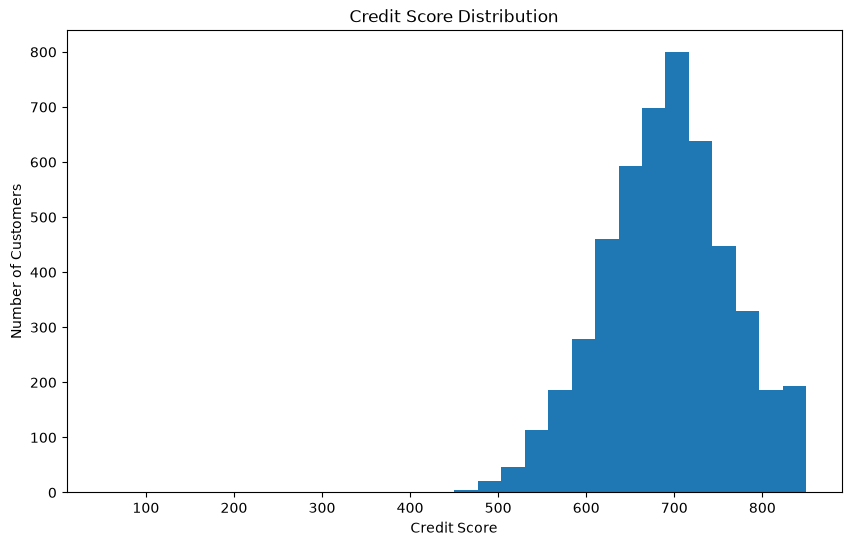

In [292]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df_clean["credit_score"], bins=30)
plt.xlabel("Credit Score")
plt.ylabel("Number of Customers")
plt.title("Credit Score Distribution")
plt.show()

### 149.2 Credit Score Band Distribution

Visualize the number of customers in each credit score band to compare the size of the different credit-risk categories.

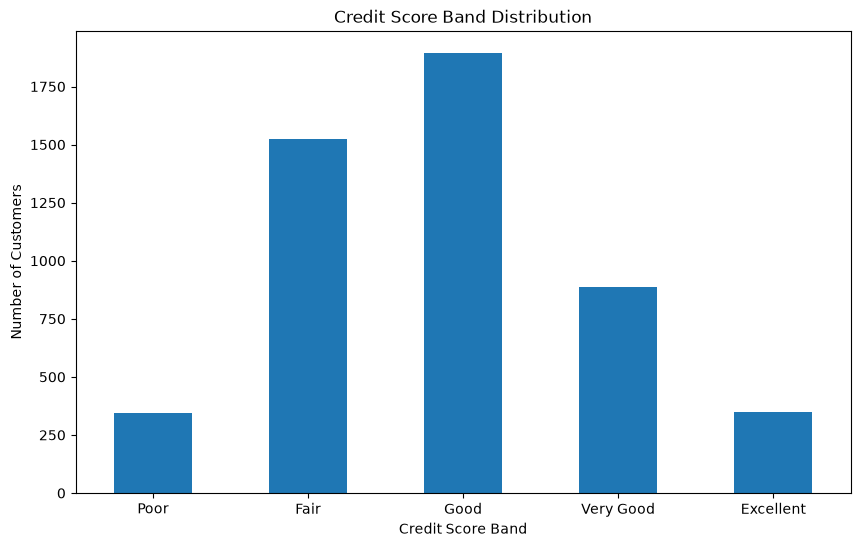

In [293]:
plt.figure(figsize=(10, 6))

df_clean["credit_score_band"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Credit Score Band")
plt.ylabel("Number of Customers")
plt.title("Credit Score Band Distribution")
plt.xticks(rotation=0)
plt.show()

### 149.3 Annual Income Distribution

Visualize the distribution of annual income to examine its spread, concentration, and potential high-income outliers.

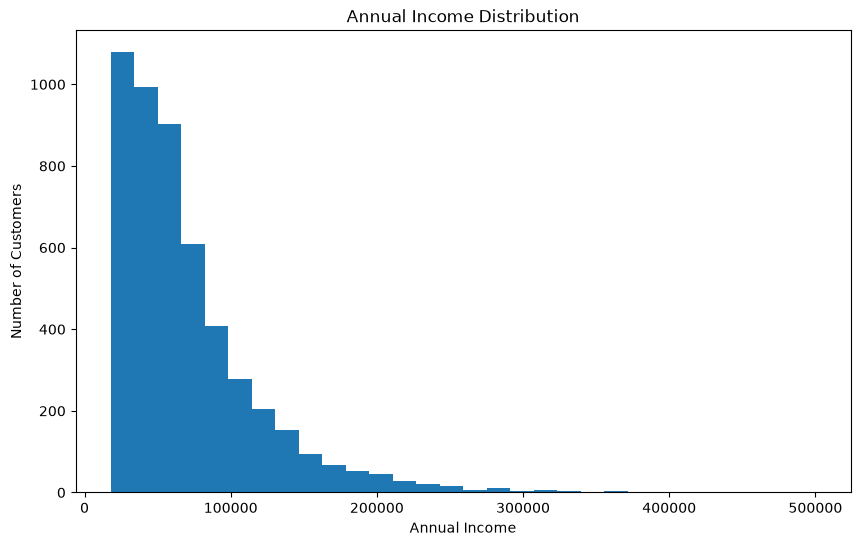

In [294]:
plt.figure(figsize=(10, 6))

plt.hist(df_clean["annual_income"], bins=30)

plt.xlabel("Annual Income")
plt.ylabel("Number of Customers")
plt.title("Annual Income Distribution")

plt.show()

### 149.4 Income Group Distribution

Visualize customer distribution across income groups to compare the size of different income segments.


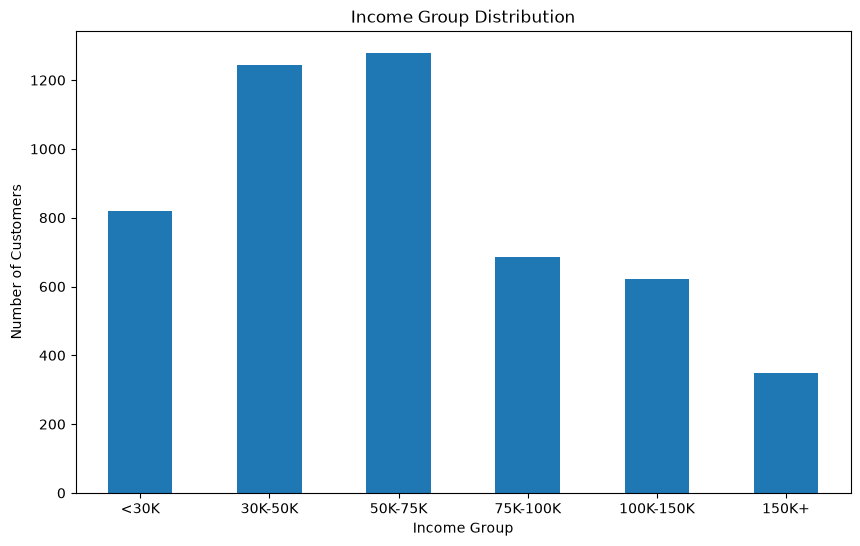

In [295]:
plt.figure(figsize=(10, 6))

df_clean["income_group"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Income Group")
plt.ylabel("Number of Customers")
plt.title("Income Group Distribution")
plt.xticks(rotation=0)

plt.show()

### 149.5 Poor Credit Rate by Employment Status

Visualize the proportion of customers in the Poor credit-score band within each employment status.

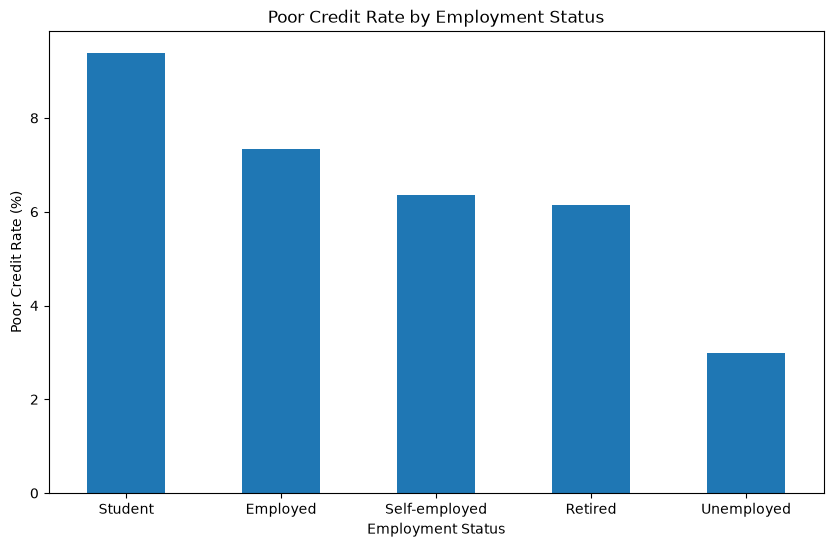

In [296]:
poor_rate_employment = (
    pd.crosstab(
        df_clean["employment_status"],
        df_clean["credit_score_band"],
        normalize="index"
    )["Poor"] * 100
)

plt.figure(figsize=(10, 6))
poor_rate_employment.sort_values(ascending=False).plot(kind="bar")

plt.xlabel("Employment Status")
plt.ylabel("Poor Credit Rate (%)")
plt.title("Poor Credit Rate by Employment Status")
plt.xticks(rotation=0)

plt.show()

### 149.6 Poor Credit Rate by Income Group

Visualize the proportion of customers in the Poor credit-score band within each income group.

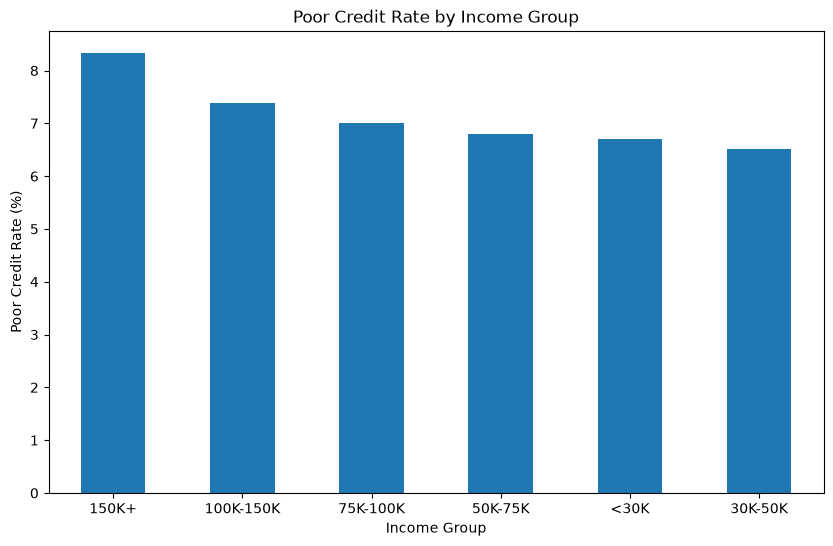

In [297]:
poor_rate_income = (
    pd.crosstab(
        df_clean["income_group"],
        df_clean["credit_score_band"],
        normalize="index"
    )["Poor"] * 100
)

plt.figure(figsize=(10, 6))
poor_rate_income.sort_values(ascending=False).plot(kind="bar")

plt.xlabel("Income Group")
plt.ylabel("Poor Credit Rate (%)")
plt.title("Poor Credit Rate by Income Group")
plt.xticks(rotation=0)

plt.show()

### 149.7 Poor Credit Rate by Age Group

Visualize the proportion of customers in the Poor credit-score band within each age group.

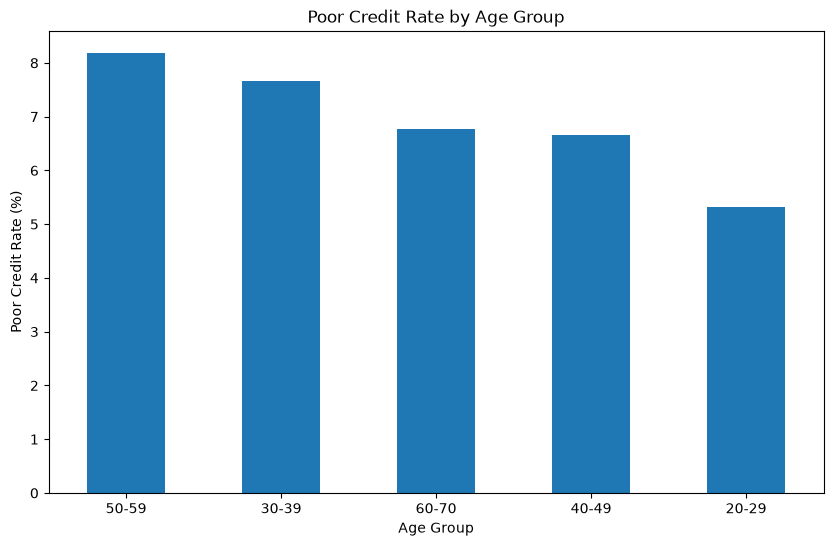

In [298]:
poor_rate_age = (
    pd.crosstab(
        df_clean["age_group"],
        df_clean["credit_score_band"],
        normalize="index"
    )["Poor"] * 100
)

plt.figure(figsize=(10, 6))
poor_rate_age.sort_values(ascending=False).plot(kind="bar")

plt.xlabel("Age Group")
plt.ylabel("Poor Credit Rate (%)")
plt.title("Poor Credit Rate by Age Group")
plt.xticks(rotation=0)

plt.show()

### 149.8 Poor Credit Rate by Region

Visualize the proportion of customers in the Poor credit-score band within each region.

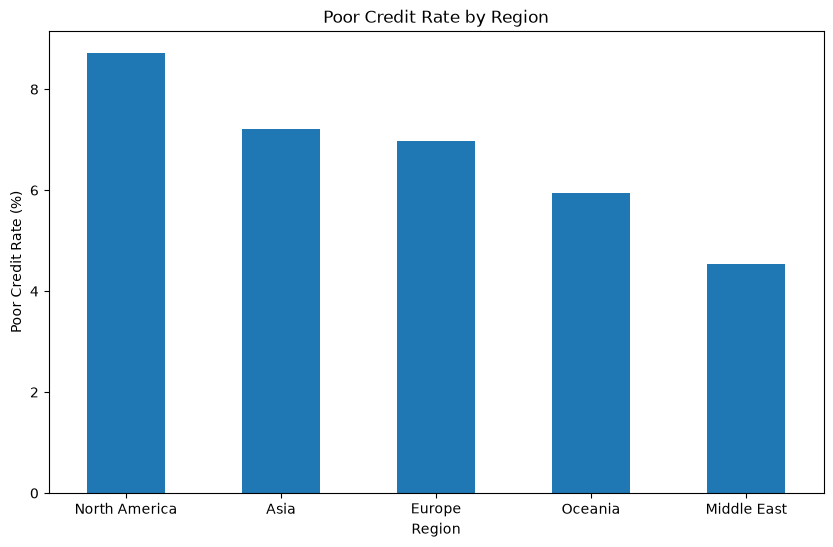

In [299]:
poor_rate_region = (
    pd.crosstab(
        df_clean["region"],
        df_clean["credit_score_band"],
        normalize="index"
    )["Poor"] * 100
)

plt.figure(figsize=(10, 6))
poor_rate_region.sort_values(ascending=False).plot(kind="bar")

plt.xlabel("Region")
plt.ylabel("Poor Credit Rate (%)")
plt.title("Poor Credit Rate by Region")
plt.xticks(rotation=0)

plt.show()

### 149.9 Poor Credit Rate by Gender

Visualize the proportion of customers in the Poor credit-score band within each gender category.


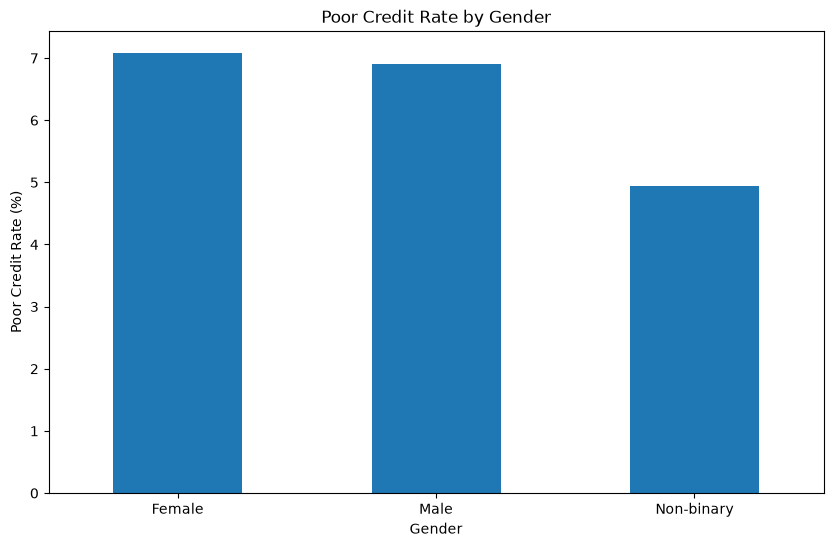

In [300]:
poor_rate_gender = (
    pd.crosstab(
        df_clean["gender"],
        df_clean["credit_score_band"],
        normalize="index"
    )["Poor"] * 100
)

plt.figure(figsize=(10, 6))
poor_rate_gender.sort_values(ascending=False).plot(kind="bar")

plt.xlabel("Gender")
plt.ylabel("Poor Credit Rate (%)")
plt.title("Poor Credit Rate by Gender")
plt.xticks(rotation=0)

plt.show()

### 149.10 Poor Credit Rate by Occupation

Visualize the proportion of customers in the Poor credit-score band within each occupation.

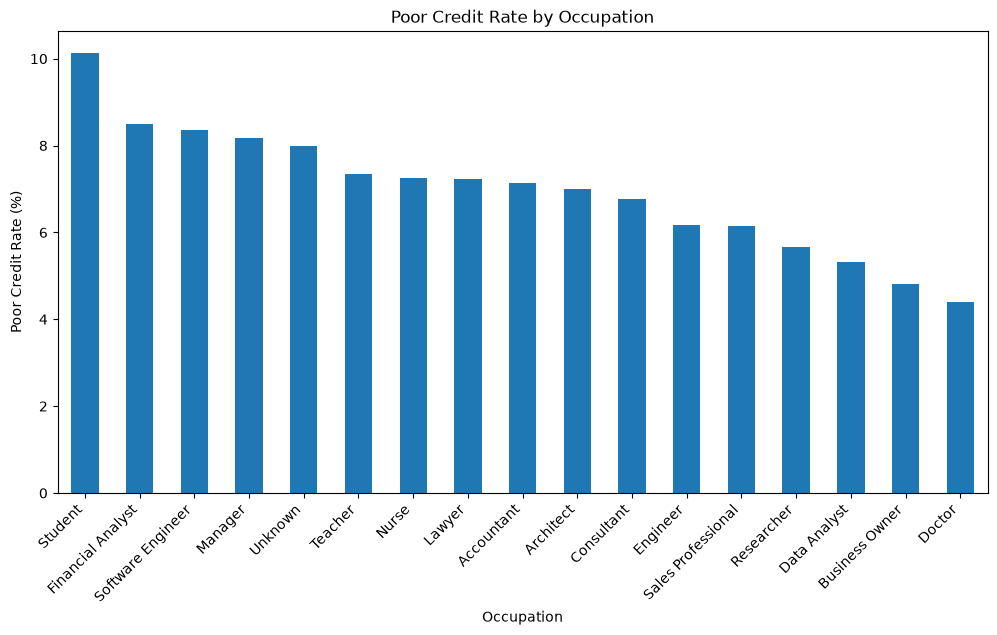

In [301]:
poor_rate_occupation = (
    pd.crosstab(
        df_clean["occupation"],
        df_clean["credit_score_band"],
        normalize="index"
    )["Poor"] * 100
)

plt.figure(figsize=(12, 6))
poor_rate_occupation.sort_values(ascending=False).plot(kind="bar")

plt.xlabel("Occupation")
plt.ylabel("Poor Credit Rate (%)")
plt.title("Poor Credit Rate by Occupation")
plt.xticks(rotation=45, ha="right")

plt.show()

### 149.11 High-Income Poor-Credit Customers

Visualize the number of customers earning at least 100K who are classified as Poor credit.

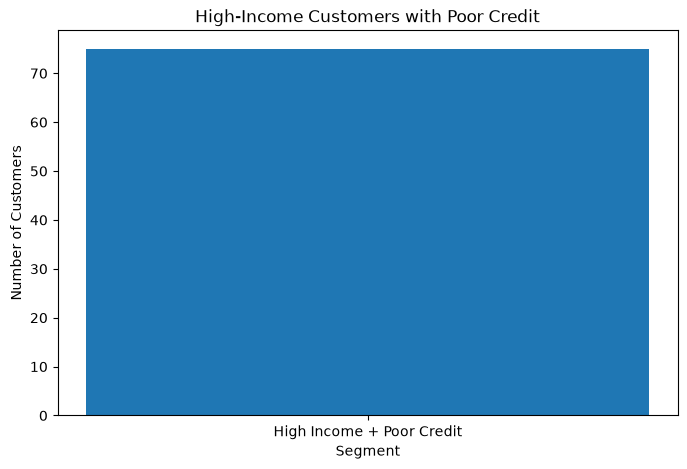

In [302]:
high_income_poor_count = len(poor_high_income)

plt.figure(figsize=(8, 5))
plt.bar(["High Income + Poor Credit"], [high_income_poor_count])

plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.title("High-Income Customers with Poor Credit")

plt.show()

### 149.12 Credit Score vs Annual Income

Visualize the relationship between annual income and credit score to assess whether higher income is associated with higher credit scores.

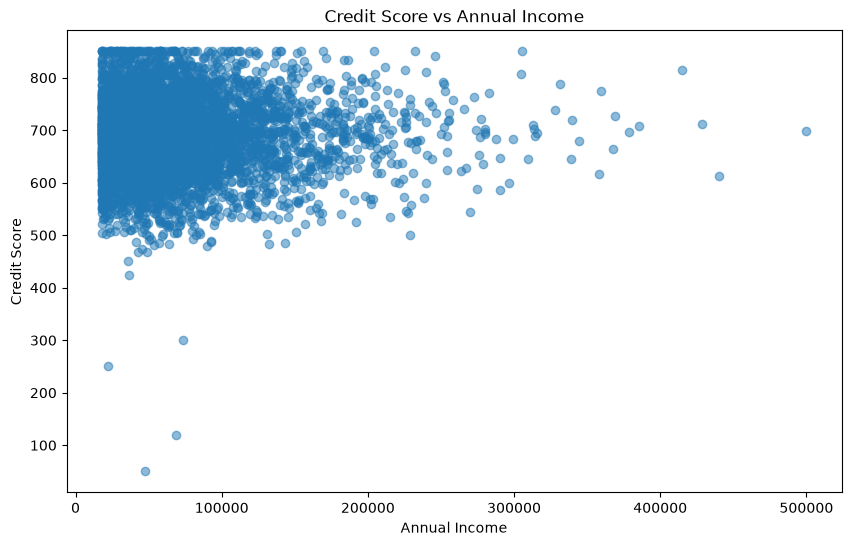

In [303]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_clean["annual_income"],
    df_clean["credit_score"],
    alpha=0.5
)

plt.xlabel("Annual Income")
plt.ylabel("Credit Score")
plt.title("Credit Score vs Annual Income")

plt.show()

### 149.13 Age vs Credit Score

Visualize the relationship between customer age and credit score to examine whether credit scores vary systematically with age.

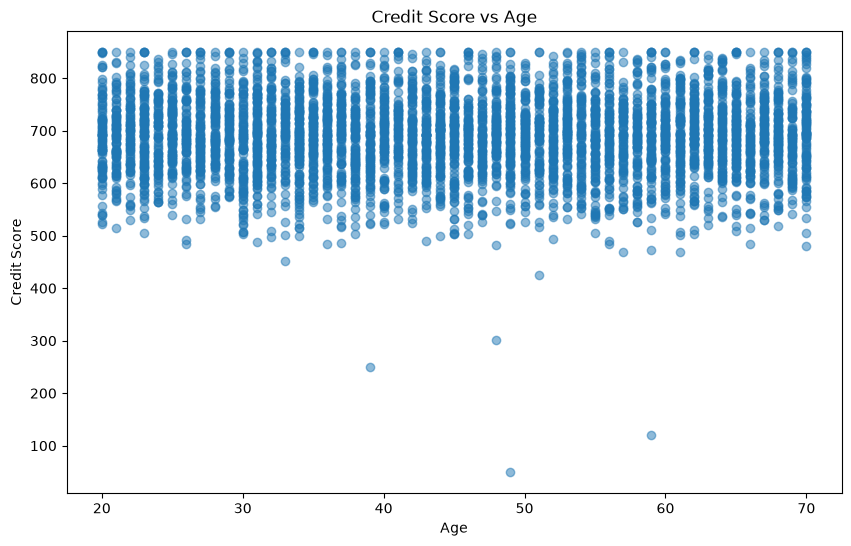

In [304]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_clean["age"],
    df_clean["credit_score"],
    alpha=0.5
)

plt.xlabel("Age")
plt.ylabel("Credit Score")
plt.title("Credit Score vs Age")

plt.show()

### 149.14 Poor Credit Customers by Age Group


### 149.15 Poor Credit Rate by Country

Visualize the proportion of customers in the Poor credit-score band within each country.

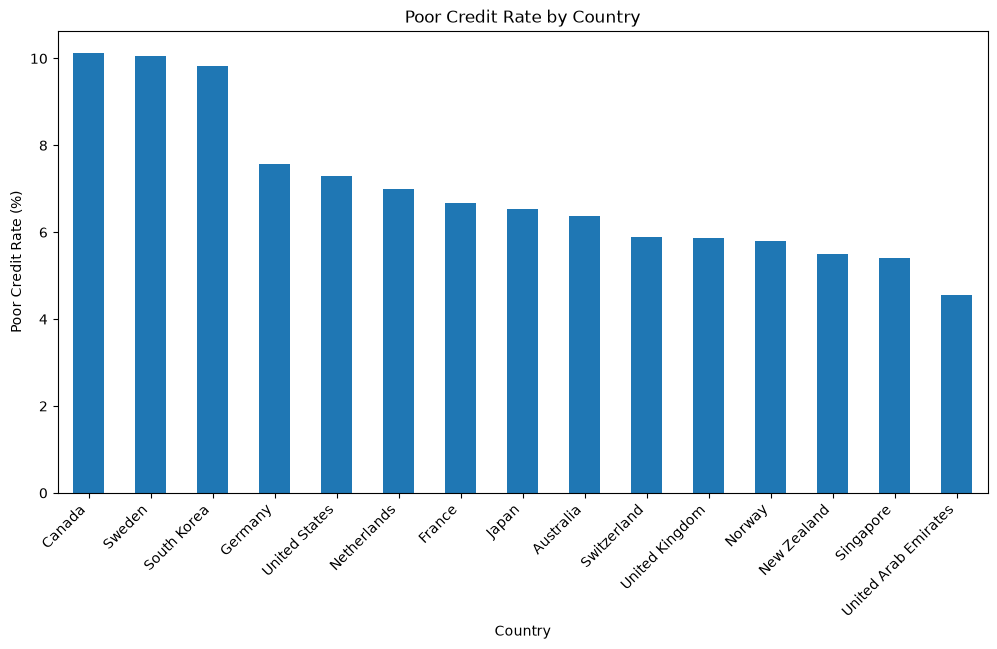

In [305]:
poor_rate_country = (
    pd.crosstab(
        df_clean["country"],
        df_clean["credit_score_band"],
        normalize="index"
    )["Poor"] * 100
)

plt.figure(figsize=(12, 6))

poor_rate_country.sort_values(ascending=False).plot(kind="bar")

plt.xlabel("Country")
plt.ylabel("Poor Credit Rate (%)")
plt.title("Poor Credit Rate by Country")
plt.xticks(rotation=45, ha="right")

plt.show()

### 149.16 Credit Score Distribution by Employment Status

Compare the distribution of credit scores across employment-status groups to examine differences in the overall credit-score profile.

<Figure size 1200x600 with 0 Axes>

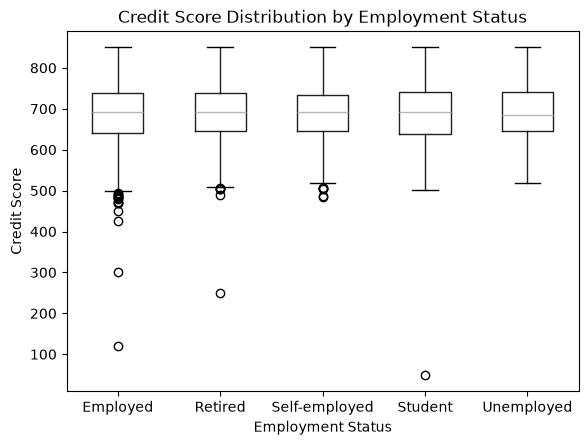

In [306]:
plt.figure(figsize=(12, 6))

df_clean.boxplot(
    column="credit_score",
    by="employment_status",
    grid=False
)

plt.xlabel("Employment Status")
plt.ylabel("Credit Score")
plt.title("Credit Score Distribution by Employment Status")
plt.suptitle("")

plt.show()

### 149.17 Annual Income Distribution by Credit Score Band

Compare annual income distributions across credit score bands to examine whether income varies meaningfully between credit-risk categories.

<Figure size 1000x600 with 0 Axes>

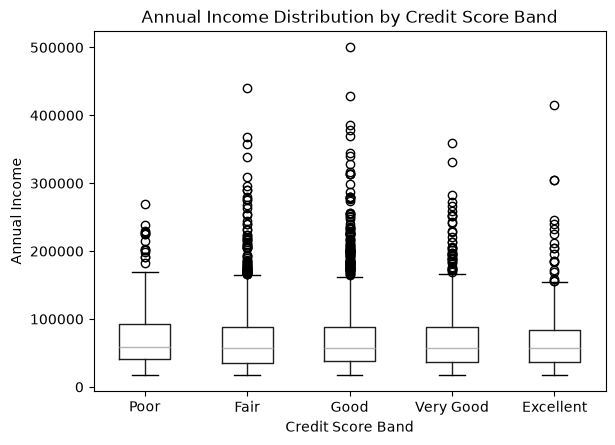

In [307]:
plt.figure(figsize=(10, 6))

df_clean.boxplot(
    column="annual_income",
    by="credit_score_band",
    grid=False
)

plt.xlabel("Credit Score Band")
plt.ylabel("Annual Income")
plt.title("Annual Income Distribution by Credit Score Band")
plt.suptitle("")

plt.show()

### 149.18 Credit Score vs Annual Income by Risk Band

Visualize annual income against credit score and distinguish Poor-credit customers from the other credit-score bands.

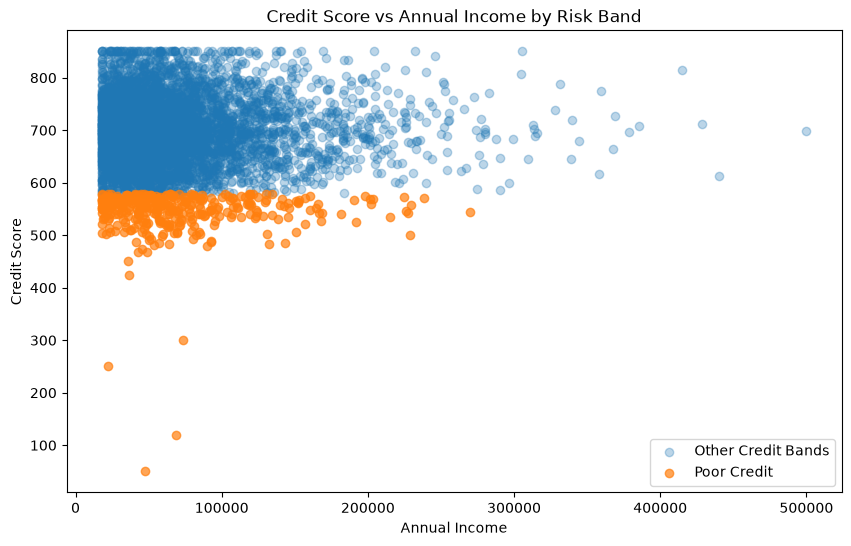

In [308]:
plt.figure(figsize=(10, 6))

poor_mask = df_clean["credit_score_band"] == "Poor"

plt.scatter(
    df_clean.loc[~poor_mask, "annual_income"],
    df_clean.loc[~poor_mask, "credit_score"],
    alpha=0.3,
    label="Other Credit Bands"
)

plt.scatter(
    df_clean.loc[poor_mask, "annual_income"],
    df_clean.loc[poor_mask, "credit_score"],
    alpha=0.7,
    label="Poor Credit"
)

plt.xlabel("Annual Income")
plt.ylabel("Credit Score")
plt.title("Credit Score vs Annual Income by Risk Band")
plt.legend()

plt.show()

### 149.19 Credit Score Distribution by Region

Compare the distribution of credit scores across regions to examine regional differences in customer credit profiles.

<Figure size 1200x600 with 0 Axes>

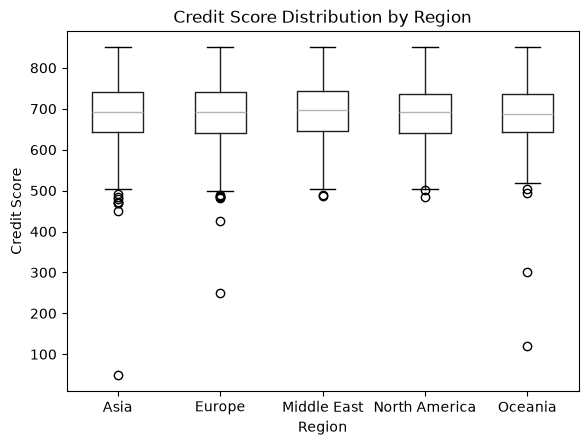

In [309]:
plt.figure(figsize=(12, 6))

df_clean.boxplot(
    column="credit_score",
    by="region",
    grid=False
)

plt.xlabel("Region")
plt.ylabel("Credit Score")
plt.title("Credit Score Distribution by Region")
plt.suptitle("")

plt.show()

### 149.20 Credit Score Distribution by Age Group

Compare the distribution of credit scores across age groups to examine whether the overall credit-score profile differs by age.

<Figure size 1200x600 with 0 Axes>

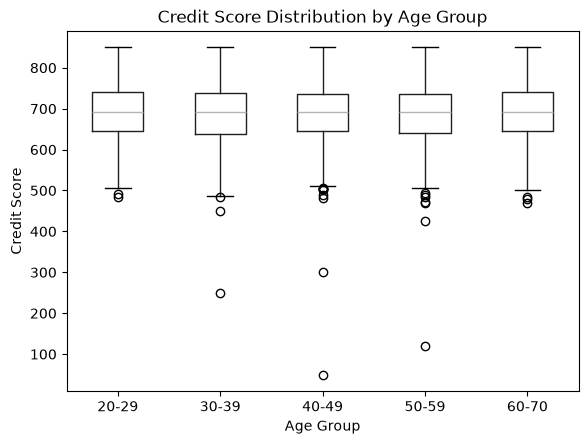

In [310]:
plt.figure(figsize=(12, 6))

df_clean.boxplot(
    column="credit_score",
    by="age_group",
    grid=False
)

plt.xlabel("Age Group")
plt.ylabel("Credit Score")
plt.title("Credit Score Distribution by Age Group")
plt.suptitle("")

plt.show()

### 149.21 Numeric Feature Correlation Heatmap

Visualize correlations among the main numeric features to identify potentially useful relationships for the credit-risk model.

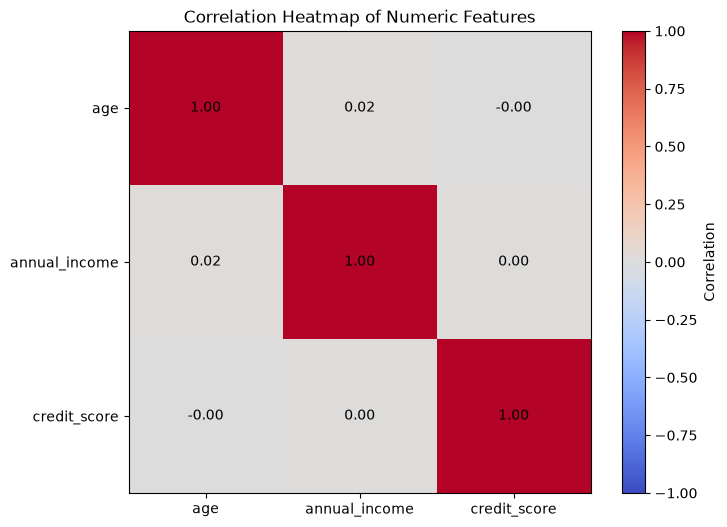

In [311]:
numeric_cols = [
    "age",
    "annual_income",
    "credit_score"
]

corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(8, 6))

plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title("Correlation Heatmap of Numeric Features")

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.show()

## 150. EDA Findings and Business Insights

The exploratory data analysis identified several important patterns in the BankSense-AI customer dataset.

- The dataset contains 5,000 unique customers across 15 countries and 5 regions.
- Good credit is the largest credit-score category, with 1,894 customers (37.9%), followed by Fair with 1,524 customers (30.5%).
- There are 346 customers (6.9%) in the Poor credit-score band.
- Annual income is strongly right-skewed, with a mean of 70,541 compared with a median of 57,456.
- Annual income and credit score have almost no linear correlation (0.0033).
- Age and credit score also have almost no linear correlation (-0.0017).
- Students have the highest Poor-credit rate among employment groups at 9.39%.
- The 150K+ income group has the highest Poor-credit rate among income groups at 8.33%.
- The 50–59 age group has the highest Poor-credit rate among age groups at 8.18%.
- North America has the highest Poor-credit rate among regions at 8.72%.
- Canada has the highest Poor-credit rate among countries at 10.13%.
- Students have the highest Poor-credit rate among occupations at 10.13%.
- 23 customers have credit scores below 500 and should be flagged for further investigation.
- 75 customers have annual income of at least 100,000 while still being classified as Poor credit.
- The analysis shows that income alone is not a reliable indicator of creditworthiness.

These findings provide the foundation for feature engineering and machine-learning model development in the next stage.

## 151. Define the Target Variable

Create a binary target variable that identifies customers in the Poor credit-score band as higher-risk customers and all other customers as non-high-risk customers.


In [312]:
df_clean["high_risk"] = (
    df_clean["credit_score_band"] == "Poor"
).astype(int)

In [313]:
df_clean["high_risk"].value_counts()

high_risk
0    4654
1     346
Name: count, dtype: int64

In [314]:
df_clean["high_risk"].mean() * 100

np.float64(6.92)

## 152. Create Model Features

In [315]:
df_clean.columns.tolist()

['customer_id',
 'first_name',
 'last_name',
 'date_of_birth',
 'gender',
 'country',
 'region',
 'city',
 'currency',
 'occupation',
 'employment_status',
 'annual_income',
 'credit_score',
 'customer_since',
 'email',
 'phone',
 'age',
 'age_group',
 'credit_score_band',
 'income_group',
 'high_risk']

### 152.1 Customer Tenure

In [316]:
df_clean["customer_tenure_years"] = (
    pd.Timestamp("2025-12-31") - df_clean["customer_since"]
).dt.days / 365.25

In [317]:
df_clean["customer_tenure_years"] = (
    df_clean["customer_tenure_years"].round(1)
)

In [318]:
df_clean["customer_tenure_years"].describe()

count    5000.000000
mean        5.436000
std         3.180418
min         0.000000
25%         2.600000
50%         5.400000
75%         8.200000
max        11.000000
Name: customer_tenure_years, dtype: float64

## 152.2 Final Feature Selection

In [319]:
model_features = [
    "age",
    "annual_income",
    "customer_tenure_years",
    "gender",
    "country",
    "occupation",
    "employment_status"
]


In [320]:
X = df_clean[model_features].copy()
y = df_clean["high_risk"].copy()


In [321]:
X.shape, y.shape

((5000, 7), (5000,))

### 152.3 Encode Categorical Features

Convert categorical variables into numerical features using one-hot encoding so that they can be used by machine-learning algorithms.

In [322]:
categorical_features = [
    "gender",
    "country",
    "occupation",
    "employment_status"
]

X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True
)

In [323]:
X_encoded.shape

(5000, 39)

## 152.4 Check Encoded Feature Types

In [324]:
X_encoded.dtypes.value_counts()

bool       36
float64     2
int64       1
Name: count, dtype: int64

### 152.5 Convert Boolean Features to Numeric

Convert one-hot encoded boolean features into integer values so that all model features use numeric representations.

In [325]:
X_encoded = X_encoded.astype(int)

In [326]:
X_encoded.dtypes.value_counts()

int64    39
Name: count, dtype: int64

## 152.6 Check Feature Matrix

In [327]:
X_encoded.shape, y.shape, X_encoded.isna().sum().sum(), y.isna().sum()

((5000, 39), (5000,), np.int64(0), np.int64(0))

### 152.7 Train-Test Split

Split the feature matrix into training and testing datasets while preserving the proportion of high-risk and non-high-risk customers using stratified sampling.

In [328]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [329]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4000, 39), (1000, 39), (4000,), (1000,))

## 152.8 Verify Target Balance After Split

In [330]:
y_train.value_counts(normalize=True).mul(100).round(2)

high_risk
0    93.08
1     6.93
Name: proportion, dtype: float64

In [331]:
y_test.value_counts(normalize=True).mul(100).round(2)


high_risk
0    93.1
1     6.9
Name: proportion, dtype: float64

## 153. Train Baseline Logistic Regression

Train a baseline logistic regression model to predict whether a customer is classified as high risk.

In [332]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [333]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [334]:
y_pred[:10], y_prob[:10]

(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 array([0.09236491, 0.05711498, 0.07762814, 0.06932495, 0.03253936,
        0.08243714, 0.05967157, 0.06839058, 0.0507245 , 0.09425959]))

## 154. Evaluate Baseline Model

Evaluate the baseline logistic regression model using accuracy, precision, recall, F1-score, and ROC-AUC.

In [335]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Accuracy : 0.931
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC-AUC  : 0.5712


## 155. Handle Class Imbalance

Train a second logistic regression model using balanced class weights so that the minority high-risk class receives greater importance during training.

Train a second logistic regression model using balanced class weights so that the minority high-risk class receives greater importance during training.

In [336]:
from sklearn.linear_model import LogisticRegression

balanced_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

balanced_model.fit(X_train, y_train)

y_pred_balanced = balanced_model.predict(X_test)
y_prob_balanced = balanced_model.predict_proba(X_test)[:, 1]

In [337]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", round(accuracy_score(y_test, y_pred_balanced), 4))
print("Precision:", round(precision_score(y_test, y_pred_balanced, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, y_pred_balanced, zero_division=0), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_balanced, zero_division=0), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_balanced), 4))

Accuracy : 0.564
Precision: 0.0839
Recall   : 0.5362
F1 Score : 0.1451
ROC-AUC  : 0.5707


## 156. Logistic Regression Feature Importance

Examine the model coefficients to identify which engineered features contribute most strongly to the high-risk prediction.

In [338]:
feature_importance = pd.Series(
    balanced_model.coef_[0],
    index=X_train.columns
).sort_values()

feature_importance.head(10), feature_importance.tail(10)

(employment_status_Unemployed      -0.889681
 occupation_Doctor                 -0.567875
 country_Singapore                 -0.392958
 occupation_Data Analyst           -0.346955
 occupation_Researcher             -0.298369
 country_Norway                    -0.283817
 employment_status_Self-employed   -0.226890
 occupation_Business Owner         -0.225666
 country_United Arab Emirates      -0.223822
 occupation_Consultant             -0.215226
 dtype: float64,
 occupation_Manager              0.205022
 occupation_Teacher              0.219365
 occupation_Lawyer               0.235660
 country_South Korea             0.240203
 country_United States           0.246740
 country_Canada                  0.252867
 employment_status_Student       0.262893
 occupation_Software Engineer    0.287362
 occupation_Student              0.372000
 country_Sweden                  0.385456
 dtype: float64)

# Important caution

### Don't interpret these as causal conclusions.

For example, the coefficient for occupation_Student does not mean being a student causes high credit risk. It only means that, within this particular logistic model and feature set, that category has a positive coefficient.

Also, because our ROC-AUC is only 0.5707, these coefficients should be treated as model-based signals, not strong predictive evidence.

## 157. Additional Risk Features

Create additional business-relevant features that may help the model identify high-risk customers beyond the original demographic and financial variables.

### 157.1 Customer Tenure Group

Group customers by the length of their relationship with the bank to create a categorical feature that can be used for risk analysis and modeling.

In [339]:
tenure_bins = [-1, 2, 5, 8, 11]
tenure_labels = ["0-2 Years", "3-5 Years", "6-8 Years", "9-11 Years"]

df_clean["tenure_group"] = pd.cut(
    df_clean["customer_tenure_years"],
    bins=tenure_bins,
    labels=tenure_labels
)

In [340]:
df_clean["tenure_group"].value_counts().sort_index()

tenure_group
0-2 Years      977
3-5 Years     1374
6-8 Years     1332
9-11 Years    1317
Name: count, dtype: int64

### 157.2 Add Tenure Group to Model Features

Add the customer tenure group to the model feature set so that the model can learn whether relationship length is associated with high-risk customers.

In [341]:
model_features = [
    "age",
    "annual_income",
    "customer_tenure_years",
    "gender",
    "country",
    "occupation",
    "employment_status",
    "tenure_group"
]

X = df_clean[model_features].copy()

categorical_features = [
    "gender",
    "country",
    "occupation",
    "employment_status",
    "tenure_group"
]

X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True
)

bool_cols = X_encoded.select_dtypes(include="bool").columns

X_encoded[bool_cols] = X_encoded[bool_cols].astype(int)

In [342]:
X_encoded.shape

(5000, 42)

### 157.3 Recreate Train-Test Split

Split the updated feature matrix into training and testing sets while preserving the high-risk class proportion.

In [343]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [344]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4000, 42), (1000, 42), (4000,), (1000,))

## 157.4 Verify Target Balance

In [345]:
y_train.value_counts(normalize=True).mul(100).round(2)

high_risk
0    93.08
1     6.93
Name: proportion, dtype: float64

In [346]:
y_test.value_counts(normalize=True).mul(100).round(2)

high_risk
0    93.1
1     6.9
Name: proportion, dtype: float64

### 157.5 Final Feature Matrix Check

Verify that the final engineered feature matrix contains the expected number of rows and features and has no missing values before model training.

In [347]:
X_encoded.shape, y.shape, X_encoded.isna().sum().sum(), y.isna().sum()

((5000, 42), (5000,), np.int64(0), np.int64(0))

## 158. Baseline Logistic Regression with Engineered Features

Train a balanced logistic regression model using the final engineered feature set to establish a baseline for model comparison.

In [348]:
from sklearn.linear_model import LogisticRegression

balanced_model_v2 = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

balanced_model_v2.fit(X_train, y_train)

d:\DataScience\BankSense-AI\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

### 158.1 Generate Predictions for the Engineered Baseline

In [349]:
# The scaled logistic-regression model is defined in Section 159 below.

In [350]:
y_pred_v2 = balanced_model_v2.predict(X_test)
y_prob_v2 = balanced_model_v2.predict_proba(X_test)[:, 1]

In [351]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", round(accuracy_score(y_test, y_pred_v2), 4))
print("Precision:", round(precision_score(y_test, y_pred_v2, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, y_pred_v2, zero_division=0), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_v2, zero_division=0), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_v2), 4))


Accuracy : 0.559
Precision: 0.0792
Recall   : 0.5072
F1 Score : 0.137
ROC-AUC  : 0.5601


## 159. Improved Logistic Regression with Feature Scaling

The previous logistic regression model did not fully converge because numerical features were on different scales. This version uses standardization for numerical variables before training the model.

In [352]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logreg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

logreg_pipeline.fit(X_train, y_train)

y_pred_lr = logreg_pipeline.predict(X_test)
y_prob_lr = logreg_pipeline.predict_proba(X_test)[:, 1]

In [353]:
print("Accuracy :", round(accuracy_score(y_test, y_pred_lr), 4))
print("Precision:", round(precision_score(y_test, y_pred_lr, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, y_pred_lr, zero_division=0), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_lr, zero_division=0), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_lr), 4))

Accuracy : 0.556
Precision: 0.0787
Recall   : 0.5072
F1 Score : 0.1362
ROC-AUC  : 0.56


In [354]:
# Random Forest probability diagnostics are run in Section 160, after rf_model is trained.

In [355]:
# Random Forest probability diagnostics are run in Section 160, after rf_model is trained.

In [356]:
# Logistic Regression threshold analysis is intentionally not repeated here.

In [357]:
df_clean["customer_tenure_years"].head(10)

0     0.1
1    10.4
2     9.2
3     7.8
4     1.7
5     9.4
6     5.8
7     5.1
8     9.6
9    10.5
Name: customer_tenure_years, dtype: float64

In [358]:
X_encoded["customer_tenure_years"].head(10)

0     0.1
1    10.4
2     9.2
3     7.8
4     1.7
5     9.4
6     5.8
7     5.1
8     9.6
9    10.5
Name: customer_tenure_years, dtype: float64

In [359]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [360]:
X_train.shape, X_test.shape

((4000, 42), (1000, 42))

## 160. Random Forest Classifier

Train and evaluate a balanced Random Forest baseline using the final engineered feature matrix.

In [361]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [362]:
print("Accuracy :", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, y_pred_rf, zero_division=0), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_rf, zero_division=0), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_rf), 4))

Accuracy : 0.926
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC-AUC  : 0.5423


In [363]:
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]

for threshold in thresholds:
    y_pred_threshold = (y_prob_rf >= threshold).astype(int)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Predicted High Risk: {y_pred_threshold.sum()} | "
        f"Precision: {precision_score(y_test, y_pred_threshold, zero_division=0):.3f} | "
        f"Recall: {recall_score(y_test, y_pred_threshold, zero_division=0):.3f} | "
        f"F1: {f1_score(y_test, y_pred_threshold, zero_division=0):.3f}"
    )

Threshold: 0.10 | Predicted High Risk: 709 | Precision: 0.071 | Recall: 0.725 | F1: 0.129
Threshold: 0.15 | Predicted High Risk: 472 | Precision: 0.078 | Recall: 0.536 | F1: 0.137
Threshold: 0.20 | Predicted High Risk: 269 | Precision: 0.086 | Recall: 0.333 | F1: 0.136
Threshold: 0.25 | Predicted High Risk: 132 | Precision: 0.098 | Recall: 0.188 | F1: 0.129
Threshold: 0.30 | Predicted High Risk: 73 | Precision: 0.096 | Recall: 0.101 | F1: 0.099
Threshold: 0.35 | Predicted High Risk: 39 | Precision: 0.077 | Recall: 0.043 | F1: 0.056
Threshold: 0.40 | Predicted High Risk: 17 | Precision: 0.059 | Recall: 0.014 | F1: 0.023
Threshold: 0.50 | Predicted High Risk: 5 | Precision: 0.000 | Recall: 0.000 | F1: 0.000


### 160.1 Baseline Random Forest Diagnostics

In [364]:
y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(high_risk
 0    0.93075
 1    0.06925
 Name: proportion, dtype: float64,
 high_risk
 0    0.931
 1    0.069
 Name: proportion, dtype: float64)

In [365]:
pd.Series(y_prob_rf).describe()

count    1000.000000
mean        0.156383
std         0.089278
min         0.013333
25%         0.090000
50%         0.140000
75%         0.203333
max         0.586667
dtype: float64

In [366]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_encoded.columns
).sort_values(ascending=False)

feature_importance.head(15)

annual_income                      0.179904
customer_tenure_years              0.155264
age                                0.151317
gender_Male                        0.032127
employment_status_Self-employed    0.019362
tenure_group_3-5 Years             0.017857
employment_status_Retired          0.017627
tenure_group_6-8 Years             0.016985
occupation_Lawyer                  0.014518
tenure_group_9-11 Years            0.013651
country_Switzerland                0.013597
occupation_Sales Professional      0.013499
country_United Arab Emirates       0.013333
country_United States              0.013183
occupation_Architect               0.013151
dtype: float64

In [367]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_rf)


array([[926,   5],
       [ 69,   0]])

### 160.2 Baseline Random Forest Parameters

The baseline Random Forest showed high accuracy but failed to identify high-risk customers at the default classification threshold. Because the target is highly imbalanced, the model is tuned with additional constraints to improve detection of the minority high-risk class.


In [368]:
rf_model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': 'balanced',
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 300,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

## 161. Tuned Random Forest Classifier

The baseline Random Forest achieved high accuracy but failed to identify high-risk customers at the default classification threshold. A tuned Random Forest is evaluated with constraints on tree complexity to improve generalization and minority-class detection.

In [369]:
from sklearn.ensemble import RandomForestClassifier

rf_tuned = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)

y_pred_rf_tuned = rf_tuned.predict(X_test)
y_prob_rf_tuned = rf_tuned.predict_proba(X_test)[:, 1]

In [370]:
rf_tuned.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_feat

In [371]:
print("Accuracy :", round(accuracy_score(y_test, y_pred_rf_tuned), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf_tuned, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, y_pred_rf_tuned, zero_division=0), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_rf_tuned, zero_division=0), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_rf_tuned), 4))

Accuracy : 0.729
Precision: 0.1055
Recall   : 0.3913
F1 Score : 0.1662
ROC-AUC  : 0.571


In [372]:
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]

for threshold in thresholds:
    y_pred_threshold = (y_prob_rf_tuned >= threshold).astype(int)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Predicted High Risk: {y_pred_threshold.sum()} | "
        f"Precision: {precision_score(y_test, y_pred_threshold, zero_division=0):.3f} | "
        f"Recall: {recall_score(y_test, y_pred_threshold, zero_division=0):.3f} | "
        f"F1: {f1_score(y_test, y_pred_threshold, zero_division=0):.3f}"
    )

Threshold: 0.10 | Predicted High Risk: 1000 | Precision: 0.069 | Recall: 1.000 | F1: 0.129
Threshold: 0.15 | Predicted High Risk: 1000 | Precision: 0.069 | Recall: 1.000 | F1: 0.129
Threshold: 0.20 | Predicted High Risk: 999 | Precision: 0.069 | Recall: 1.000 | F1: 0.129
Threshold: 0.25 | Predicted High Risk: 997 | Precision: 0.069 | Recall: 1.000 | F1: 0.129
Threshold: 0.30 | Predicted High Risk: 969 | Precision: 0.071 | Recall: 1.000 | F1: 0.133
Threshold: 0.35 | Predicted High Risk: 932 | Precision: 0.074 | Recall: 1.000 | F1: 0.138
Threshold: 0.40 | Predicted High Risk: 837 | Precision: 0.072 | Recall: 0.870 | F1: 0.132
Threshold: 0.50 | Predicted High Risk: 256 | Precision: 0.105 | Recall: 0.391 | F1: 0.166


### Tuned Random Forest Findings

The baseline Random Forest achieved high accuracy but failed to detect high-risk customers. After constraining tree complexity, the tuned Random Forest improved minority-class detection, increasing recall from 0.000 to 0.391 and F1 score from 0.000 to 0.166. However, precision (0.106) and ROC-AUC (0.571) remained modest, indicating that the model has limited predictive power.

## 162. Model Comparison

The models are compared using accuracy, precision, recall, F1 score, and ROC-AUC. Because the target variable is highly imbalanced, particular attention is given to recall, F1 score, and ROC-AUC rather than accuracy alone.

In [373]:
model_comparison = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression with Engineered Features",
        "Improved Logistic Regression",
        "Baseline Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_v2),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_rf_tuned)
    ],
    "Precision": [
        precision_score(y_test, y_pred_v2, zero_division=0),
        precision_score(y_test, y_pred_lr, zero_division=0),
        precision_score(y_test, y_pred_rf, zero_division=0),
        precision_score(y_test, y_pred_rf_tuned, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred_v2, zero_division=0),
        recall_score(y_test, y_pred_lr, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0),
        recall_score(y_test, y_pred_rf_tuned, zero_division=0)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_v2, zero_division=0),
        f1_score(y_test, y_pred_lr, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0),
        f1_score(y_test, y_pred_rf_tuned, zero_division=0)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_v2),
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_rf_tuned)
    ]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline Logistic Regression with Engineered F...,0.559,0.0792,0.5072,0.1370,0.5601
1,Improved Logistic Regression,0.556,0.0787,0.5072,0.1362,0.5600
2,Baseline Random Forest,0.926,0.0000,0.0000,0.0000,0.5423
3,Tuned Random Forest,0.729,0.1055,0.3913,0.1662,0.5710


### Model Comparison Findings

The tuned Random Forest achieved the highest F1 score (0.1662) and ROC-AUC (0.5710) among the evaluated models. It also improved high-risk customer detection compared with the baseline Random Forest, which achieved zero recall and zero F1 score.

The baseline Logistic Regression with Engineered Features performed competitively, with an F1 score of 0.137 and ROC-AUC of 0.5601. Although the tuned Random Forest was selected as the strongest candidate based on F1 score, the relatively low precision and ROC-AUC indicate that the overall predictive performance remains limited.

Because the target variable is highly imbalanced, accuracy was not used as the primary criterion for model selection.

## 163. Final Model Selection

The Tuned Random Forest was selected as the strongest candidate among the evaluated models because it achieved the highest F1 score (0.1662) and ROC-AUC (0.5710). However, its relatively low precision and ROC-AUC indicate that the model has limited predictive power and should not be considered production-ready without further improvement and validation.

## 164. Post-Selection Checks and Dataset Export

The checks in this section confirm that the final feature matrix, target labels, split integrity, and model objects are all consistent after model selection.

In [374]:
cleaned_path = r"D:\DataScience\BankSense-AI\data\banksense_customers_cleaned.csv"

df_clean.to_csv(cleaned_path, index=False)

print(f"Saved cleaned dataset to: {cleaned_path}")

Saved cleaned dataset to: D:\DataScience\BankSense-AI\data\banksense_customers_cleaned.csv


### 164.1 Review Final Feature Matrix

Check the final encoded feature names and make sure there are no credit-score or risk-target columns in the predictors.

In [375]:
X_encoded.columns.tolist()

['age',
 'annual_income',
 'customer_tenure_years',
 'gender_Male',
 'gender_Non-binary',
 'country_Canada',
 'country_France',
 'country_Germany',
 'country_Japan',
 'country_Netherlands',
 'country_New Zealand',
 'country_Norway',
 'country_Singapore',
 'country_South Korea',
 'country_Sweden',
 'country_Switzerland',
 'country_United Arab Emirates',
 'country_United Kingdom',
 'country_United States',
 'occupation_Architect',
 'occupation_Business Owner',
 'occupation_Consultant',
 'occupation_Data Analyst',
 'occupation_Doctor',
 'occupation_Engineer',
 'occupation_Financial Analyst',
 'occupation_Lawyer',
 'occupation_Manager',
 'occupation_Nurse',
 'occupation_Researcher',
 'occupation_Sales Professional',
 'occupation_Software Engineer',
 'occupation_Student',
 'occupation_Teacher',
 'occupation_Unknown',
 'employment_status_Retired',
 'employment_status_Self-employed',
 'employment_status_Student',
 'employment_status_Unemployed',
 'tenure_group_3-5 Years',
 'tenure_group_6-8 Y

In [376]:
[c for c in X_encoded.columns if "credit" in c.lower() or "risk" in c.lower()]

[]

In [377]:
X_encoded.shape

(5000, 42)

In [378]:
X_encoded.isna().sum().sum()

np.int64(0)

### 164.2 Review Target Distribution

Confirm that the target labels and class balance match the earlier imbalance checks.

In [379]:
y.value_counts()

high_risk
0    4654
1     346
Name: count, dtype: int64

In [380]:
y.value_counts(normalize=True)

high_risk
0    0.9308
1    0.0692
Name: proportion, dtype: float64

### 164.3 Validate Credit-Scores-to-Target Mapping

Verify that the high-risk label still lines up with the Poor credit-score band.

In [381]:
df_clean[["credit_score", "credit_score_band", "high_risk"]].head(10)

,credit_score,credit_score_band,high_risk
0,662.0,Fair,0
1,609.0,Fair,0
2,589.0,Fair,0
3,634.0,Fair,0
4,596.0,Fair,0
5,810.0,Excellent,0
6,577.0,Poor,1
7,701.0,Good,0
8,723.0,Good,0
9,717.0,Good,0


In [382]:
pd.crosstab(
    df_clean["credit_score_band"],
    df_clean["high_risk"]
)

high_risk,0,1
credit_score_band,,
Poor,0,346
Fair,1524,0
Good,1894,0
Very Good,885,0
Excellent,351,0


In [383]:
X.columns.tolist()

['age',
 'annual_income',
 'customer_tenure_years',
 'gender',
 'country',
 'occupation',
 'employment_status',
 'tenure_group']

In [384]:
X_encoded.head()

,age,annual_income,customer_tenure_years,gender_Male,gender_Non-binary,country_Canada,country_France,country_Germany,country_Japan,country_Netherlands,...,occupation_Student,occupation_Teacher,occupation_Unknown,employment_status_Retired,employment_status_Self-employed,employment_status_Student,employment_status_Unemployed,tenure_group_3-5 Years,tenure_group_6-8 Years,tenure_group_9-11 Years
0,61,47008.0,0.1,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,38,93730.0,10.4,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
2,44,89438.0,9.2,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
3,42,49393.0,7.8,1,0,0,0,0,0,0,...,1,0,0,0,0,0,1,0,1,0
4,20,40479.0,1.7,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,0,0,0


In [385]:
X_encoded.dtypes.value_counts()

int64      40
float64     2
Name: count, dtype: int64

### 164.4 Review Feature and Split Integrity

Check the feature matrix shape, missing values, and train/test split consistency.

In [386]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4000, 42), (1000, 42), (4000,), (1000,))

In [387]:
y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(high_risk
 0    0.93075
 1    0.06925
 Name: proportion, dtype: float64,
 high_risk
 0    0.931
 1    0.069
 Name: proportion, dtype: float64)

In [388]:
X_train.columns.equals(X_test.columns)

True

In [389]:
X_train.index.intersection(X_test.index).size

0

In [390]:
type(X_encoded)

pandas.DataFrame

In [391]:
X_encoded.index.equals(df_clean.index)

True

### 164.5 Inspect Model Objects

Review the trained logistic-regression pipeline and confirm the fitted model structure.

In [392]:
X_encoded.index.equals(y.index)

True

### 164.6 Inspect Logistic Regression Pipeline

Review the fitted logistic-regression pipeline and its trained steps.

In [393]:
logreg_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](42,)","['age','annual_income','customer_tenure_years',..., 'tenure_group_3-5 Years','tenure_group_6-8 Years', 'tenure_group_9-11 Years']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,42
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [394]:
logreg_pipeline.named_steps

{'scaler': StandardScaler(),
 'model': LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)}

### 164.7 Audit Random Forest Variables

Inspect the remaining Random Forest-related variables to make sure the final notebook state is clear.

In [395]:
[y for y in globals() if "rf" in y.lower()]

['rf_model',
 'y_pred_rf',
 'y_prob_rf',
 'rf_tuned',
 'y_pred_rf_tuned',
 'y_prob_rf_tuned']

### 164.8 Audit Prediction Variable Names

Check the available prediction and probability variables so the comparison and reporting cells use the correct outputs.

In [396]:
[y for y in globals() if y.startswith("y_pred") or y.startswith("y_prob")]

['y_pred',
 'y_prob',
 'y_pred_balanced',
 'y_prob_balanced',
 'y_pred_v2',
 'y_prob_v2',
 'y_pred_lr',
 'y_prob_lr',
 'y_pred_rf',
 'y_prob_rf',
 'y_pred_threshold',
 'y_pred_rf_tuned',
 'y_prob_rf_tuned']

### 164.9 Inspect Random Forest Model Object

Review the trained Random Forest model object at the end of the notebook for completeness.

In [397]:
rf_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [398]:
from pathlib import Path
import joblib

# Create model directory
model_dir = Path("../models")
model_dir.mkdir(exist_ok=True)

# Save the trained model and exact feature structure
model_artifact = {
    "model": rf_tuned,
    "feature_columns": X_encoded.columns.tolist(),
}

model_path = model_dir / "banksense_rf_tuned.joblib"

joblib.dump(model_artifact, model_path)

print(f"Model saved to: {model_path}")
print(f"Number of features: {len(X_encoded.columns)}")

Model saved to: ..\models\banksense_rf_tuned.joblib
Number of features: 42
